# OT/ICS-IDS-LLM-Nebius v8 — Open-Source LLMs for Industrial Intrusion Detection on Safety-Critical Infrastructure (SWaT + HAI)

**Companion paper:** *Foundation Models for Industrial Intrusion Detection: Evaluating Open-Source LLMs, TabPFN, and TabICL on OT/ICS Cybersecurity Benchmarks*

**Project:** CYBER-LLM — Generación de Conocimiento 2025 (PID2025-171696OA-I00, Agencia Estatal de Investigación).

This notebook **ports the `ot-ics-ids` evaluation framework** (de Curtò, García, de Zarzà) onto the **Nebius open-source LLM pipeline** from `ids_llm_nebius_v7` and the **TabPFN/TabICL anchors** with the v2.x parameter fixes from `pablogarcia-tabicl-fix`. The target domain is no longer IT-network intrusion detection (CIC-IDS2017, UNSW-NB15, N-BaIoT) — instead it is **safety-critical OT/ICS**:

- **SWaT** (Secure Water Treatment, iTrust @ SUTD Singapore) — 51 sensor/actuator signals from a six-stage water-treatment testbed, 11 days of operation (7 normal + 4 attack), 41 distinct attack scenarios.
- **HAI** (HIL-based Augmented ICS Security, KAIST) — multi-process testbed (GE turbine + Emerson boiler + FESTO water treatment), 50+ attack scenarios.

## Why this matters

OT/ICS intrusion detection is **fundamentally different** from IT-network IDS:

| Property | IT-IDS (CIC-IDS2017) | **OT/ICS-IDS (SWaT / HAI)** |
|---|---|---|
| Signal | Packet/flow headers | **Process sensor/actuator readings (continuous)** |
| Normal:Attack ratio | ~80:20 | **>95:5** (extreme imbalance) |
| Labeled attacks | Plentiful (replay-able) | **Scarce** (each attack is expensive to stage) |
| Cost of false alarm | Triage overhead | **Halted production / safety shutdown** |
| Cost of missed attack | Data breach | **Physical damage, environmental harm, casualties** |
| Feature physics | Stateless headers | **Inter-sensor correlations (mass balance, control loops)** |

Two metrics matter disproportionately here: **False Alarm Rate (FAR)** — a tripped plant is expensive and erodes operator trust — and **Detection Rate (DR)** — a missed attack can cause physical harm. Standard accuracy hides both.

## What's new vs `ids_llm_nebius_v7`

- **Two new datasets**: SWaT (`vishala28/swat-dataset-secure-water-treatment-system`) and HAI (`icsdataset/hai-security-dataset`).
- **OT-aware preprocessing**: dataset-specific label resolution (SWaT's `Normal/Attack` with the `A ttack` typo; HAI's per-process `Attack_P1/P2/P3` merged into a single `Attack` indicator), timestamp dropping, sensor-type feature grouping (LIT / FIT / AIT / PIT / DPIT / MV / P for SWaT; P1 / P2 / P3 for HAI), optional delta-feature engineering, and optional fixed-stride windowing.
- **ICS-specific metrics**: FAR, DR, MCC, balanced accuracy, plus the per-class profile from v7.
- **Domain-grounded role prompt**: `role-instructed-ot` — frames the LLM as a SCADA-floor analyst with the sensor-type semantics inlined.
- **TabPFN / TabICL anchors with the v2.x config fixes** from `pablogarcia-tabicl-fix` (renamed `class_shift` → `class_shuffle_method="shift"`, `use_hierarchical` → `support_many_classes`, `use_amp=True` → `"auto"`, corrected checkpoint filename).
- **Few-shot k-sweep retained** (E2) — even more important on OT/ICS where labeled attack samples are scarce in practice.
- **All v7 instrumentation preserved** — multi-vendor sweep (E1), prompt-format ablation (E3), self-consistency (E4), cost/latency telemetry (E5), per-class failure analysis (E6), multi-seed validation (R1, R2), hybrid ensemble diagnostic (E8).

## Computational cost guidance

- `SCALE = 'quick'` (smoke test): N_TEST=10/class, 3 seeds, ~5 min, ~$0.50 per dataset.
- `SCALE = 'paper'` (camera-ready): N_TEST=50/class, 5 seeds, full sweep, ~20–40 min, ~$25–40 per dataset.
- TabPFN / TabICL anchors add ~5–10 min per dataset on Colab T4; functional on Mac M3 (MPS for TabPFN, CPU for TabICL) in ~15–25 min.

Two switches drive everything: **`DATASET`** (`'swat' | 'hai'`) and **`BINARY_LABELS`** (`True` for Normal-vs-Attack; `False` retained for forward compatibility with multi-class attack-type labels when metadata is available).

The notebook is **self-contained and Colab-ready** (T4 GPU sufficient).


**What's new in v2 (vs v1)**

- **E7 — full-test evaluation** on a large held-out split (anchors on the entire held-out
  test set; LLM on a stratified subsample). Designed to produce numbers directly
  comparable to the SWaT / HAI literature.
- **Parallel ICL runner** (`run_icl_parallel`) used by E7 to bring 2 000-sample LLM
  evaluations down from ~30 min to ~5 min on the default 8-way concurrency.
- **Bias guard** in E1: any model that collapses to a single class
  (FAR > 0.30 or DR < 0.10 on the seed-42 run) is flagged for follow-up.
- **E6 confusion matrices** now exported as CSV in addition to PNG.
- **Download cell** patched: `KSHOT_GRID` and `SEEDS_R1_DEFAULT` now populate the
  manifest correctly (the v1 lookup keyed on the wrong names and produced `null`).
- **`BASELINE_FAMILIES`** accepts string, list, set, or tuple.


**What's new in v3 (vs v2)**

- **Lazy auto-install** for TabPFN / TabICL: if `BASELINE_FAMILIES` includes
  either, the anchor functions now `pip install` on first `ImportError` and
  retry. The v2 run skipped both because the install lines were commented
  out — this fixes it.
- **Wilson 95% CIs** on E7 metrics (accuracy / FAR / DR). At the default
  n=4000 these are ±0.011 on accuracy, ±0.020 on DR, ±0.007 on FAR, which
  is tight enough to make claims defensible in a paper.
- **Optional multi-seed E7** (`E7_N_SEEDS > 1`) re-draws the stratified
  subsample with N independent seeds and aggregates with cross-seed mean +
  bootstrap CI on top of the within-seed Wilson CI.
- **Raw predictions saved** (`e7_predictions_<dataset>_seed<i>.npz`) for
  downstream bootstrap / threshold-sweep analysis without re-running.
- **Default `E7_LLM_TEST_SIZE` bumped 2000 -> 4000** based on v2 timing
  (168 s wall-clock for n=2000 at 8 workers, leaving comfortable headroom).


**What's new in v4 (vs v3)**

- **TabPFN auth-fallback chain** (`local + TABPFN_TOKEN` -> `tabpfn-client` cloud
  -> skip-with-instructions). v3 silently skipped TabPFN because PriorLabs
  added a one-time license-acceptance step that the headless install hit. v4
  reads `TABPFN_TOKEN` from Colab Secrets / env, and falls back to the cloud
  client when no token is present.
- **Multi-seed E7 by default** (`E7_N_SEEDS = 3`). Adds cross-seed dispersion
  bars on top of the within-seed Wilson CIs, at ~3x cost.
- **n bumped 4000 -> 6000.** Wilson CI half-widths: acc ±0.009, DR ±0.016,
  FAR ±0.005. Below the 0.02 effect sizes we are reporting.
- **Paired McNemar tests** between the LLM and each anchor on the
  intersection of the LLM-subsample, plus a delta CSV and LaTeX table.


**What's new in v5 (vs v4)**

The v4 SWaT run produced paper-ready results (Wilson CIs do not overlap,
multi-seed std < 0.01, paired McNemar significant at p<0.05). v5 is
**polish only** — no new experiments, no new knobs:

- **tabpfn-client log suppression.** The cloud client's per-chunk
  `Predicting... Done!` output is silenced; only errors propagate.
- **TabPFN license-error caching.** After one failed local attempt,
  subsequent calls go straight to the cloud client — no repeated traceback.
- **AUROC + AUPRC for anchors in E7.** Computed from `predict_proba` for
  RF / TabPFN / TabICL. These are the threshold-independent metrics
  reviewers will look for to compare against Goh 2017, Kravchik 2018,
  Shin 2020. The LLM has no calibrated probability so it is omitted from
  these plots (per OT/ICS literature convention).


**What's new in v6 (vs v5)**

- **WUSTL-IIoT-2021 added** as a third dataset. Set `DATASET = "wustl"`
  in cell 8 to enable. Source: Kaggle mirror
  `annaamalaiu/wustl-iiot-2021-dataset` (original from Zolanvari et al. 2021,
  WUSTL CSE / IEEE DataPort, DOI 10.21227/yftq-n229).
- **Leakage columns dropped automatically.** The WUSTL authors explicitly
  warn that `StartTime`, `LastTime`, `SrcAddr`, `DstAddr`, `sIpId`, `dIpId`
  are unique to each attack and would let the model cheat. v6 drops them
  in `preprocess_wustl()`.
- **WUSTL role-instructed-ot prompt** added — describes flow-based IIoT
  features (Argus packet/byte counts, Modbus/TCP ports, TCP TTL, ...)
  rather than physical sensors.
- **Natural class imbalance preserved.** WUSTL is "deliberately imbalanced"
  (per the dataset authors) -- the canonical real-world setting. E7's
  `E7_NATURAL_PREVALENCE=True` is the right default. Document this in the
  Limitations.
- **No changes to the LLM, anchors, experiment design, or any v5 behaviour
  on SWaT/HAI.** This is a strictly additive integration.


**What's new in v7 (vs v6)**

The SWaT + HAI runs from v5/v6 are paper-ready. v7 is a minimal patch:

- **TabICL AUROC/AUPRC fix.** v5/v6 captured `predict_proba` for RF and
  TabPFN, but the TabICL patcher silently failed to reach `tabicl_anchor`
  (the function body had drifted), so TabICL was missing from the E7 ROC/PR
  tables on both SWaT and HAI. v7 patches `tabicl_anchor` directly. After
  re-running the E7-d2 block alone (cell with `# E7-d2) AUROC + AUPRC`)
  the missing rows will populate without redoing the LLM eval.
- **DATASET preflight check.** Prints a loud warning if `DATASET == "wustl"`
  but no WUSTL data was downloaded, so the silent "ran SWaT instead of
  WUSTL" failure mode can't recur.
- **Cross-dataset summary builder.** New code cell after the final aggregation
  scans for `master_summary_<dataset>.csv` files in the output directory
  and emits a consolidated `cross_dataset_summary.tex` and `.csv`. Drop
  the .tex directly into the paper's Results section.


**What's new in v8 (vs v7)**

- **WUSTL preprocessing fixed.** The `annaamalaiu/wustl-iiot-2021-dataset`
  Kaggle mirror ships two label columns: `Traffic` (categorical attack-type
  string) and `Target` (numeric 0/1). v6/v7 hard-assumed `Traffic` was binary
  and coerced its strings to NaN, collapsing all 1.19 M rows to "Normal".
  v8 auto-detects the binary column by checking which candidate is actually
  numeric 0/1, falling back to the categorical column otherwise.
- **Sanity check on labels.** After resolving Label, v8 verifies at least 2
  unique values are present and raises a clear error pointing at row counts
  if only one class is found.
- **E7-d2 hardened.** Degenerate-holdout guard (no IndexError on single-class
  holdouts); multi-class attack-column summation for multi-class mode.


In [112]:
# ============================================================
# 0) INSTALL & IMPORTS
# ============================================================
!pip install -q openai>=1.55 tqdm pandas scikit-learn scipy matplotlib seaborn kagglehub tiktoken imbalanced-learn
# TabPFN / TabICL anchors. Comment these two lines if BASELINE_FAMILIES = "rf"
# only -- otherwise the lazy install in the anchor functions will run anyway,
# so leaving them here keeps the install front-loaded (less noise mid-notebook).
!pip install -q tabpfn
!pip install -q tabpfn-client
!pip install -q tabicl

import os, sys, json, random, math, hashlib, time, re, uuid, gc, glob, zipfile
from dataclasses import dataclass, asdict, field
from typing import List, Dict, Any, Tuple, Optional, Iterable
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import warnings, logging
warnings.filterwarnings("ignore")

# v5: silence tabpfn-client cloud-client per-call logs. Errors still propagate.
for _logger_name in ("tabpfn_client", "tabpfn_client.client", "httpx", "httpcore"):
    logging.getLogger(_logger_name).setLevel(logging.ERROR)

sns.set_context("paper", font_scale=1.05)
sns.set_style("whitegrid")

print("Imports OK.")


Imports OK.


In [113]:
# ============================================================
# 1) NEBIUS API SETUP
# ============================================================
from openai import OpenAI

try:
    from google.colab import userdata
    NEBIUS_KEY = userdata.get("NEBIUS_API_KEY")
except Exception:
    NEBIUS_KEY = os.environ.get("NEBIUS_API_KEY", "")

assert NEBIUS_KEY, "Set NEBIUS_API_KEY in Colab Secrets (recommended) or env."

client = OpenAI(base_url="https://api.studio.nebius.com/v1/", api_key=NEBIUS_KEY)

# Model registry — display name -> Nebius model id. Identical to v7's
# 11-model registry across 7 vendors, so cross-domain comparisons are direct.
MODEL_REGISTRY = {
    # --- Meta Llama family (within-family scaling pair: 8B vs 70B) ---
    "Llama-3.1-8B"       : "meta-llama/Meta-Llama-3.1-8B-Instruct",
    "Llama-3.3-70B"      : "meta-llama/Llama-3.3-70B-Instruct",
    # --- Alibaba Qwen ---
    "Qwen3-235B-A22B"    : "Qwen/Qwen3-235B-A22B-Instruct-2507",
    # --- DeepSeek ---
    "DeepSeek-V3"        : "deepseek-ai/DeepSeek-V3-0324",
    # --- Mistral ---
    "Mistral-Nemo-12B"   : "mistralai/Mistral-Nemo-Instruct-2407",
    # --- OpenAI gpt-oss ---
    "gpt-oss-120B"       : "openai/gpt-oss-120b",
    # --- Nous Hermes-4 family (within-family scaling pair: 70B vs 405B) ---
    "Hermes-4-70B"       : "NousResearch/Hermes-4-70B",
    "Hermes-4-405B"      : "NousResearch/Hermes-4-405B",
    # --- Google Gemma ---
    #"Gemma-3-27B-it"     : "google/gemma-3-27b-it",
}

MODEL_META = {
    "Llama-3.1-8B"          : {"family": "Llama",     "size_b":   8, "active_b":   8,  "moe": False},
    "Llama-3.3-70B"         : {"family": "Llama",     "size_b":  70, "active_b":  70,  "moe": False},
    "Qwen3-235B-A22B"       : {"family": "Qwen3",     "size_b": 235, "active_b":  22,  "moe": True},
    "DeepSeek-V3"           : {"family": "DeepSeek",  "size_b": 671, "active_b":  37,  "moe": True},
    "Mistral-Nemo-12B"      : {"family": "Mistral",   "size_b":  12, "active_b":  12,  "moe": False},
    "gpt-oss-120B"          : {"family": "gpt-oss",   "size_b": 120, "active_b":   5.1,"moe": True},
    "Hermes-4-70B"          : {"family": "Hermes-4",  "size_b":  70, "active_b":  70,  "moe": False},
    "Hermes-4-405B"         : {"family": "Hermes-4",  "size_b": 405, "active_b": 405,  "moe": False},
    #"Gemma-3-27B-it"        : {"family": "Gemma",     "size_b":  27, "active_b":  27,  "moe": False},
}

SCALING_PAIRS = [
    ("Llama-3.1-8B",  "Llama-3.3-70B"),
    ("Hermes-4-70B",  "Hermes-4-405B"),
]

PRIMARY_MODEL = "Qwen3-235B-A22B"   # v7's cross-domain winner; revalidate on OT/ICS

print("Nebius client ready.")
print(f"Models registered: {len(MODEL_REGISTRY)} across {len(set(m['family'] for m in MODEL_META.values()))} families")
for k, v in MODEL_REGISTRY.items():
    marker = "  *" if k == PRIMARY_MODEL else "   "
    fam = MODEL_META.get(k, {}).get("family", "?")
    sz  = MODEL_META.get(k, {}).get("active_b", "?")
    print(f"{marker} {k:<24} family={fam:<10} active={sz:>5}B  -> {v}")


Nebius client ready.
Models registered: 8 across 6 families
    Llama-3.1-8B             family=Llama      active=    8B  -> meta-llama/Meta-Llama-3.1-8B-Instruct
    Llama-3.3-70B            family=Llama      active=   70B  -> meta-llama/Llama-3.3-70B-Instruct
  * Qwen3-235B-A22B          family=Qwen3      active=   22B  -> Qwen/Qwen3-235B-A22B-Instruct-2507
    DeepSeek-V3              family=DeepSeek   active=   37B  -> deepseek-ai/DeepSeek-V3-0324
    Mistral-Nemo-12B         family=Mistral    active=   12B  -> mistralai/Mistral-Nemo-Instruct-2407
    gpt-oss-120B             family=gpt-oss    active=  5.1B  -> openai/gpt-oss-120b
    Hermes-4-70B             family=Hermes-4   active=   70B  -> NousResearch/Hermes-4-70B
    Hermes-4-405B            family=Hermes-4   active=  405B  -> NousResearch/Hermes-4-405B


In [114]:
# ============================================================
# 2) UTILITIES
# ============================================================
def set_seed(s: int) -> None:
    random.seed(s); np.random.seed(s)

def ensure_dir(p: str) -> str:
    os.makedirs(p, exist_ok=True)
    return p

def _sha1(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

BASE_OUT = ensure_dir("./ot_ics_ids_llm_nebius_v1_outputs")
print(f"Outputs will be written under: {BASE_OUT}")


Outputs will be written under: ./ot_ics_ids_llm_nebius_v1_outputs


In [115]:
# ============================================================
# 2b) MODEL PROBE
# ============================================================
# Pings every registered model with a 1-token completion. Any model that
# returns an error here is auto-removed from MODEL_REGISTRY before the
# downstream experiments, so a single deprecated/over-quota model does not
# poison the entire run.
def probe_models(reg: Dict[str, str]) -> Dict[str, str]:
    ok = {}
    for name, mid in reg.items():
        try:
            t0 = time.time()
            r = client.chat.completions.create(
                model=mid,
                messages=[{"role": "user", "content": "Reply with exactly the word: OK"}],
                temperature=0.0, max_tokens=4, n=1,
            )
            txt = r.choices[0].message.content.strip()
            dt  = time.time() - t0
            print(f"  [OK]   {name:<24} {dt:5.2f}s  -> {txt!r}")
            ok[name] = mid
        except Exception as e:
            print(f"  [SKIP] {name:<24} {type(e).__name__}: {str(e)[:60]}")
    return ok

MODEL_REGISTRY = probe_models(MODEL_REGISTRY)
print(f"\nUsable models after probe: {len(MODEL_REGISTRY)} -> {list(MODEL_REGISTRY.keys())}")
assert PRIMARY_MODEL in MODEL_REGISTRY, f"Primary model {PRIMARY_MODEL} failed probe."


  [SKIP] Llama-3.1-8B             NotFoundError: Error code: 404 - {'detail': 'The model `meta-llama/Meta-Lla
  [OK]   Llama-3.3-70B             0.35s  -> 'OK'
  [OK]   Qwen3-235B-A22B           0.30s  -> 'OK'
  [SKIP] DeepSeek-V3              NotFoundError: Error code: 404 - {'detail': 'The model `deepseek-ai/DeepSee
  [SKIP] Mistral-Nemo-12B         NotFoundError: Error code: 404 - {'detail': 'The model `mistralai/Mistral-N
  [SKIP] gpt-oss-120B             AttributeError: 'NoneType' object has no attribute 'strip'
  [OK]   Hermes-4-70B              0.30s  -> 'OK'
  [OK]   Hermes-4-405B             0.42s  -> 'OK'

Usable models after probe: 4 -> ['Llama-3.3-70B', 'Qwen3-235B-A22B', 'Hermes-4-70B', 'Hermes-4-405B']


In [116]:
# ============================================================
# 3) NEBIUS LLM WRAPPER (telemetry, caching, retries, robust n_vote)
# ============================================================
# Identical to v7 — self-consistency is sequential n=1 calls (the OpenAI
# n=N parameter is silently honoured/dropped inconsistently across Nebius
# models, which caused parse_rate collapse in earlier ICL studies).
class NebiusLLM:
    def __init__(self, client, model_id: str, name: str,
                 temperature: float = 0.7, max_tokens: int = 32,
                 cache_enabled: bool = True):
        self.client = client
        self.model_id = model_id
        self.name = name
        self.temperature = temperature
        self.max_tokens = max_tokens
        self.cache_enabled = cache_enabled and (temperature == 0.0)
        self._cache: Dict[str, str] = {}
        self.stats = {
            "name": name, "calls": 0, "cached": 0, "errors": 0,
            "prompt_tokens": 0, "completion_tokens": 0,
            "wall_seconds": 0.0,
        }

    def _key(self, system, prompt) -> str:
        return _sha1(f"{self.model_id}|t={self.temperature}|sys={system}|p={prompt}")

    def _one_call(self, prompt: str, system: Optional[str] = None) -> str:
        key = self._key(system, prompt)
        if self.cache_enabled and key in self._cache:
            self.stats["cached"] += 1
            return self._cache[key]

        msgs = []
        if system: msgs.append({"role": "system", "content": system})
        msgs.append({"role": "user", "content": prompt})

        for attempt in range(4):
            try:
                t0 = time.time()
                resp = self.client.chat.completions.create(
                    model=self.model_id, messages=msgs,
                    temperature=self.temperature,
                    max_tokens=self.max_tokens,
                    n=1,
                )
                dt = time.time() - t0
                text = resp.choices[0].message.content.strip()
                self.stats["calls"] += 1
                self.stats["wall_seconds"] += dt
                if getattr(resp, "usage", None):
                    self.stats["prompt_tokens"]     += resp.usage.prompt_tokens
                    self.stats["completion_tokens"] += resp.usage.completion_tokens
                if self.cache_enabled:
                    self._cache[key] = text
                return text
            except Exception as e:
                self.stats["errors"] += 1
                if attempt == 3:
                    return ""
                time.sleep(min(2**attempt + random.random(), 12))

    def chat(self, prompt: str, system: Optional[str] = None,
             n: int = 1) -> List[str]:
        return [self._one_call(prompt, system=system) for _ in range(n)]

print("NebiusLLM wrapper ready (sequential n_vote calls).")


NebiusLLM wrapper ready (sequential n_vote calls).


## Data

Two switchable OT/ICS datasets — sourced from Kaggle so the notebook stays self-contained on Colab. Set `DATASET` in the next cell.

| `DATASET` | Source slug | Format | Notes |
|---|---|---|---|
| `swat` | `vishala28/swat-dataset-secure-water-treatment-system` | CSV (Normal + Attack files) | 51 sensors/actuators across 6 stages; binary label is `Normal` / `Attack` (case sometimes inconsistent, `A ttack` typo present in some mirrors) |
| `hai`  | `icsdataset/hai-security-dataset` | CSV (per-version subfolders) | HIL turbine + boiler + water treatment; binary `Attack` indicator plus per-process `Attack_P1/P2/P3` columns — we merge them into a single `Attack` flag for binary classification |

**Authentication.** Kaggle requires an API token. Drop your `kaggle.json` into Colab Secrets as `KAGGLE_USERNAME` + `KAGGLE_KEY`, OR set the env variables locally. The cell below auto-detects both.


In [117]:
# ============================================================
# 4a) KAGGLE AUTH (Colab Secrets first, env-var second)
# ============================================================
# Set BOTH 'KAGGLE_USERNAME' and 'KAGGLE_KEY' in the Colab Secrets panel
# (key icon, left sidebar) and toggle 'Notebook access' on. Both
# kagglehub and the kaggle CLI read the env-vars.
try:
    from google.colab import userdata
    if not os.environ.get("KAGGLE_USERNAME"):
        os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    if not os.environ.get("KAGGLE_KEY"):
        os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
except Exception:
    pass

assert os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"), \
    "Set KAGGLE_USERNAME and KAGGLE_KEY (Colab Secrets or env vars) before running this cell."
print("Kaggle creds loaded.")


Kaggle creds loaded.


In [118]:
# ============================================================
# 4b) DATASET SELECTOR
# ============================================================
DATASET        = "swat"          # 'swat' | 'hai' | 'wustl'
BINARY_LABELS  = True             # True = Normal/Attack; False = multi-class (when metadata present)

DATASET_SLUGS = {
    "swat"  : "vishala28/swat-dataset-secure-water-treatment-system",
    "hai"   : "icsdataset/hai-security-dataset",
    "wustl" : "annaamalaiu/wustl-iiot-2021-dataset",
}

# HAI version preference order (first match wins). The Kaggle mirror ships
# every version side-by-side under separate subfolders.
HAI_VERSION_PREFERENCE = ["hai-22.04", "hai-21.03", "hai-20.07", "hai-1.0", "hai-2.0", "hai-3.0"]

print(f"DATASET       = {DATASET}")
print(f"  slug        = {DATASET_SLUGS[DATASET]}")
print(f"BINARY_LABELS = {BINARY_LABELS}")

# v7: loud confirmation banner so the dataset selection is unambiguous in the
# notebook output stream (the SWaT/HAI/WUSTL output filenames are dataset-
# suffixed, so picking the wrong DATASET is otherwise easy to miss until
# the very end of the run).
print()
print("=" * 60)
print(f"  RUN CONFIGURATION CONFIRMED: DATASET = '{DATASET.upper()}'")
print("=" * 60)
if DATASET not in DATASET_SLUGS:
    raise ValueError(f"DATASET='{DATASET}' not in {list(DATASET_SLUGS)}")


DATASET       = swat
  slug        = vishala28/swat-dataset-secure-water-treatment-system
BINARY_LABELS = True

  RUN CONFIGURATION CONFIRMED: DATASET = 'SWAT'


In [119]:
# ============================================================
# 4c) DATA LOADER — Kaggle-hosted SWaT + HAI (with CLI fallback)
# ============================================================
def _download_kaggle(slug: str) -> str:
    """Try kagglehub first, fall back to the kaggle CLI on failure."""
    try:
        import kagglehub
        folder = kagglehub.dataset_download(slug)
        print(f"  kagglehub OK -> {folder}")
        return folder
    except Exception as e:
        print(f"  kagglehub failed ({type(e).__name__}: {e}); falling back to kaggle CLI...")
        target = os.path.join("./.kaggle_cache", slug.replace("/", "__"))
        os.makedirs(target, exist_ok=True)
        # Write a temporary kaggle.json so the CLI is happy
        kg_dir = os.path.expanduser("~/.kaggle")
        os.makedirs(kg_dir, exist_ok=True)
        kg_json = os.path.join(kg_dir, "kaggle.json")
        if not os.path.exists(kg_json):
            with open(kg_json, "w") as f:
                json.dump({"username": os.environ["KAGGLE_USERNAME"],
                           "key":      os.environ["KAGGLE_KEY"]}, f)
            os.chmod(kg_json, 0o600)
        # Need a fresh kaggle install/import
        try:
            from kaggle.api.kaggle_api_extended import KaggleApi
        except ImportError:
            os.system("pip install -q kaggle")
            from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi(); api.authenticate()
        api.dataset_download_files(slug, path=target, unzip=True, quiet=False)
        print(f"  kaggle CLI OK -> {target}")
        return target

def _read_swat(folder: str) -> pd.DataFrame:
    """Read SWaT — normally two files: `*Normal*.csv` and `*Attack*.csv`.

    Kaggle mirror layouts vary: some users ship the original semi-colon /
    comma-decimal CSVs straight from iTrust, others pre-cleaned. We try
    standard CSV first, then semicolon, then re-read with latin-1 if utf-8
    barfs.
    """
    csvs = sorted(glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True))
    csvs = [c for c in csvs if "_macosx" not in c.lower()]
    print(f"  found {len(csvs)} CSV file(s): {[os.path.basename(c) for c in csvs]}")
    if not csvs:
        raise FileNotFoundError(f"No CSVs found in {folder}")

    def _try_read(path):
        for sep in (",", ";"):
            for enc in ("utf-8", "latin-1"):
                try:
                    df = pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
                    if df.shape[1] >= 5:
                        return df
                except Exception:
                    continue
        # Last resort: semicolon + comma-decimal
        return pd.read_csv(path, sep=";", decimal=",", encoding="latin-1", low_memory=False)

    dfs = []
    for c in csvs:
        bn = os.path.basename(c).lower()
        df = _try_read(c)
        # Tag the source so we can keep balance / inspect
        df["_source_file"] = os.path.basename(c)
        dfs.append(df)
        print(f"    {os.path.basename(c):<50} -> {df.shape}")
    combined = pd.concat(dfs, ignore_index=True)
    return combined

def _read_hai(folder: str) -> pd.DataFrame:
    """Read HAI — pick a version subfolder by preference, then merge all CSVs in it."""
    # Look for version subfolders
    subdirs = [d for d in glob.glob(os.path.join(folder, "*")) if os.path.isdir(d)]
    chosen = None
    for pref in HAI_VERSION_PREFERENCE:
        for d in subdirs:
            if pref in os.path.basename(d).lower().replace("_", "-"):
                chosen = d; break
        if chosen: break
    if chosen is None:
        # No version subdir — use the root
        chosen = folder
    print(f"  HAI version chosen: {os.path.basename(chosen)}")

    csvs = sorted(glob.glob(os.path.join(chosen, "**", "*.csv"), recursive=True))
    csvs = [c for c in csvs if "_macosx" not in c.lower()]
    # Some versions also ship hai-end / HAIEnd auxiliary files — drop those
    csvs = [c for c in csvs if "haiend" not in os.path.basename(c).lower()
                              and "hai-end" not in os.path.basename(c).lower()]
    if not csvs:
        raise FileNotFoundError(f"No HAI CSVs found in {chosen}")
    print(f"  reading {len(csvs)} HAI CSV file(s)")
    dfs = []
    for c in csvs:
        df = pd.read_csv(c, low_memory=False)
        df["_source_file"] = os.path.basename(c)
        dfs.append(df)
        print(f"    {os.path.basename(c):<30} -> {df.shape}")
    return pd.concat(dfs, ignore_index=True)

def _read_wustl(folder: str) -> pd.DataFrame:
    """Read WUSTL-IIoT-2021. The Kaggle mirror typically ships a single
    `WUSTL-IIoT-2021.csv` (~106 MB) under the dataset root, but some mirrors
    split it. We concatenate all CSVs we find (excluding _macosx artefacts).
    """
    csvs = sorted(glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True))
    csvs = [c for c in csvs if "_macosx" not in c.lower()]
    if not csvs:
        raise FileNotFoundError(f"No WUSTL CSVs found in {folder}")
    print(f"  found {len(csvs)} CSV file(s): {[os.path.basename(c) for c in csvs]}")
    dfs = []
    for c in csvs:
        df = pd.read_csv(c, low_memory=False)
        df["_source_file"] = os.path.basename(c)
        dfs.append(df)
        print(f"    {os.path.basename(c):<40} -> {df.shape}")
    return pd.concat(dfs, ignore_index=True)

slug = DATASET_SLUGS[DATASET]
print(f"Downloading via Kaggle: {slug}")
data_folder = _download_kaggle(slug)
print(f"\nReading {DATASET.upper()} from: {data_folder}")
if DATASET == "swat":
    raw = _read_swat(data_folder)
elif DATASET == "hai":
    raw = _read_hai(data_folder)
elif DATASET == "wustl":
    raw = _read_wustl(data_folder)
else:
    raise ValueError(DATASET)

# Strip whitespace from column names (SWaT mirror often has leading spaces)
raw.columns = [c.strip() for c in raw.columns]
print(f"\nRaw shape: {raw.shape}")
print(f"First columns: {list(raw.columns[:10])}")
print(f"Last  columns: {list(raw.columns[-10:])}")


100%|██████████| 101M/101M [00:07<00:00, 14.5MB/s]

Extracting files...


  kagglehub OK -> /root/.cache/kagglehub/datasets/vishala28/swat-dataset-secure-water-treatment-system/versions/3

Reading SWAT from: /root/.cache/kagglehub/datasets/vishala28/swat-dataset-secure-water-treatment-system/versions/3
  found 3 CSV file(s): ['attack.csv', 'merged.csv', 'normal.csv']
    attack.csv                                         -> (54621, 54)
    merged.csv                                         -> (1441719, 54)
    normal.csv                                         -> (1387098, 54)

Raw shape: (2883438, 54)
First columns: ['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201']
Last  columns: ['P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack', '_source_file']


In [120]:
# ============================================================
# 5) PREPROCESS — SWaT + HAI label resolution and cleaning
# ============================================================
# SWaT: target column is 'Normal/Attack' (sometimes shipped without the slash
# as 'Normal_Attack' or just 'label'); attack rows have the value 'Attack',
# sometimes with the known 'A ttack' typo or 'A-ttack'.
# HAI : target columns are 'Attack' (binary 0/1) OR a triple
# 'Attack_P1' / 'Attack_P2' / 'Attack_P3' that we OR together.

SWAT_LABEL_CANDIDATES = ["Normal/Attack", "Normal_Attack", "label", "Label", "Attack"]
HAI_LABEL_CANDIDATES  = ["Attack", "attack", "label", "Label"]

def _find_label_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    for c in candidates:
        for col in df.columns:
            if col.strip().lower() == c.strip().lower():
                return col
    return None

def _basic_clean_numeric(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Coerce features to numeric, drop NaN/Inf, drop constant columns, downcast."""
    df = df.copy()
    feature_cols = [c for c in df.columns if c != label_col and not c.startswith("_")]
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=feature_cols, how="any")
    # Downcast for memory
    for col in feature_cols:
        if pd.api.types.is_float_dtype(df[col]):
            cmin, cmax = df[col].min(), df[col].max()
            if cmin > np.finfo(np.float32).min and cmax < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
        elif pd.api.types.is_integer_dtype(df[col]):
            cmin, cmax = df[col].min(), df[col].max()
            if cmin > np.iinfo(np.int32).min and cmax < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
    # Drop constants among features
    n_unique = df[feature_cols].nunique()
    constants = n_unique[n_unique <= 1].index.tolist()
    if constants:
        print(f"  dropping {len(constants)} constant feature columns: {constants[:5]}{'...' if len(constants) > 5 else ''}")
        df = df.drop(columns=constants)
    return df

def preprocess_swat(df: pd.DataFrame) -> pd.DataFrame:
    """Resolve label, drop Timestamp, clean, return df with `Label` column."""
    label_col = _find_label_column(df, SWAT_LABEL_CANDIDATES)
    if label_col is None:
        raise KeyError(f"No SWaT label column found in {list(df.columns)}")
    print(f"  SWaT label column: '{label_col}'")
    df = df.rename(columns={label_col: "Label"})

    # Drop timestamp / source-file / index columns
    drop_cols = []
    for c in df.columns:
        if c == "Label": continue
        if c.startswith("_"): drop_cols.append(c); continue
        if c.lower() in ("timestamp", "time", "datetime", "date", "unnamed: 0"):
            drop_cols.append(c)
    if drop_cols:
        print(f"  dropping non-feature columns: {drop_cols}")
        df = df.drop(columns=drop_cols)

    # Normalise labels: strip whitespace, fix known 'A ttack' typo, capitalisation
    df["Label"] = df["Label"].astype(str).str.strip()
    df["Label"] = df["Label"].str.replace(r"\s+", "", regex=True)   # 'A ttack' -> 'Attack'
    df["Label"] = df["Label"].str.replace(r"[^A-Za-z]", "", regex=True)
    df["Label"] = df["Label"].str.title()
    # Anything that isn't 'Normal' gets mapped to 'Attack' in BINARY mode
    if BINARY_LABELS:
        df.loc[df["Label"] != "Normal", "Label"] = "Attack"
    print(f"  labels after normalisation: {df['Label'].value_counts().to_dict()}")
    return _basic_clean_numeric(df, "Label")

def preprocess_hai(df: pd.DataFrame) -> pd.DataFrame:
    """Resolve label (binary OR P1/P2/P3 union), drop timestamp, clean."""
    # Try direct Attack column first
    label_col = _find_label_column(df, HAI_LABEL_CANDIDATES)
    if label_col is not None and BINARY_LABELS:
        print(f"  HAI label column: '{label_col}'")
        df = df.rename(columns={label_col: "_label_raw"})
        df["Label"] = df["_label_raw"].astype(str).str.strip().map(
            lambda v: "Normal" if v in ("0", "0.0", "Normal", "normal", "False", "false", "nan", "") else "Attack"
        )
        df = df.drop(columns=["_label_raw"])
    else:
        # Look for Attack_P1 / Attack_P2 / Attack_P3 (or attack_p*) and OR them.
        per_proc_cols = [c for c in df.columns if c.lower().startswith("attack_p")]
        if not per_proc_cols:
            # Last resort — any column with 'attack' in the name
            per_proc_cols = [c for c in df.columns if "attack" in c.lower()]
        if not per_proc_cols:
            raise KeyError(f"No HAI label column found in {list(df.columns)[:15]}")
        print(f"  HAI per-process attack columns: {per_proc_cols}")
        # Treat any non-zero / 'True' as attack
        for c in per_proc_cols:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)
        df["Label"] = "Normal"
        attack_mask = (df[per_proc_cols].sum(axis=1) > 0)
        df.loc[attack_mask, "Label"] = "Attack"
        df = df.drop(columns=per_proc_cols)

    # Drop timestamps and source-file tags
    drop_cols = []
    for c in df.columns:
        if c == "Label": continue
        if c.startswith("_"): drop_cols.append(c); continue
        if c.lower() in ("time", "timestamp", "datetime", "date", "unnamed: 0"):
            drop_cols.append(c)
    if drop_cols:
        print(f"  dropping non-feature columns: {drop_cols}")
        df = df.drop(columns=drop_cols)
    print(f"  labels after normalisation: {df['Label'].value_counts().to_dict()}")
    return _basic_clean_numeric(df, "Label")

def _wustl_pick_binary_col(df: pd.DataFrame, candidates: list) -> "tuple | None":
    """Return (col_name, mapping_dict) for the first candidate column whose
    values are recognisably binary (0/1, 'normal'/'attack', booleans, etc.).
    Returns None if no candidate is clearly binary.

    The Kaggle mirror by `annaamalaiu` ships both:
      Traffic -- categorical attack-type string
      Target  -- numeric 0/1
    so this function picks `Target` when both are present. The original
    iTrust release uses `Traffic` as the numeric 0/1, which still works.
    """
    for col in candidates:
        if col not in df.columns:
            continue
        # Sample up to 5000 non-null values to inspect
        sample = df[col].dropna().head(5000)
        if len(sample) == 0:
            continue
        # Try numeric coercion -- if >=99% coerce cleanly to {0, 1} ints,
        # call it binary.
        coerced = pd.to_numeric(sample, errors="coerce")
        ok = coerced.dropna()
        if len(ok) >= 0.99 * len(sample):
            uniq = set(ok.astype(int).unique().tolist())
            if uniq <= {0, 1} and len(uniq) >= 1:
                return col, {0: "Normal", 1: "Attack"}
        # Try string normal/attack
        s = sample.astype(str).str.strip().str.lower()
        uniq_s = set(s.unique().tolist())
        # Pattern: every value is either 'normal' or 'attack' (binary string).
        if uniq_s <= {"normal", "attack"} and len(uniq_s) >= 1:
            return col, {"normal": "Normal", "attack": "Attack"}
    return None

def _wustl_pick_categorical_col(df: pd.DataFrame, candidates: list) -> "str | None":
    """Return the name of the first candidate column whose values are a
    multi-class categorical attack-type string (i.e. NOT clean 0/1)."""
    for col in candidates:
        if col not in df.columns:
            continue
        sample = df[col].dropna().head(5000)
        if len(sample) == 0:
            continue
        coerced = pd.to_numeric(sample, errors="coerce")
        ok = coerced.dropna()
        # If <50% are numeric, treat as categorical
        if len(ok) < 0.5 * len(sample):
            return col
        # If numeric but with >2 unique values, also categorical
        uniq = set(ok.astype(int).unique().tolist()) if len(ok) > 0 else set()
        if len(uniq) > 2:
            return col
    return None

def preprocess_wustl(df: pd.DataFrame) -> pd.DataFrame:
    """WUSTL-IIoT-2021.

    The Kaggle mirror by `annaamalaiu` ships both:
      * `Traffic` -- categorical attack-type string
                     ("Normal", "DoS", "Reconnaissance", "MitM", "Injection",
                      "Backdoor")
      * `Target`  -- numeric 0/1 binary indicator
    The original iTrust release only has `Traffic` (as 0/1). v8 auto-resolves
    which is which.

    Drops leakage columns flagged by Zolanvari et al. (StartTime, LastTime,
    SrcAddr, DstAddr, sIpId, dIpId).
    """
    # ---- leakage columns the WUSTL authors explicitly warn about ----
    LEAKAGE_COLS = ["StartTime", "LastTime", "SrcAddr", "DstAddr",
                    "sIpId", "dIpId"]
    leak_present = [c for c in df.columns if c.strip() in LEAKAGE_COLS]
    if leak_present:
        print(f"  dropping WUSTL leakage columns: {leak_present}")
        df = df.drop(columns=leak_present)

    # ---- resolve label columns by INSPECTING the data ----
    # Candidates in priority order; "Target" first since the Kaggle mirror
    # explicitly adds it as the binary column. Both lowercase variants
    # accepted (some mirrors use snake_case).
    BIN_CANDIDATES = ["Target", "target", "Traffic", "traffic", "Label", "label"]
    CAT_CANDIDATES = ["Traffic", "traffic", "Label", "label", "Target", "target"]

    print(f"  WUSTL label-column candidates present: "
          f"{[c for c in set(BIN_CANDIDATES + CAT_CANDIDATES) if c in df.columns]}")

    bin_pick = _wustl_pick_binary_col(df, BIN_CANDIDATES)
    cat_pick = _wustl_pick_categorical_col(df, CAT_CANDIDATES)

    if BINARY_LABELS:
        if bin_pick is not None:
            bin_col, mapping = bin_pick
            print(f"  WUSTL: using BINARY column '{bin_col}' (auto-detected)")
            if 0 in mapping:  # numeric 0/1
                df["Label"] = (pd.to_numeric(df[bin_col], errors="coerce")
                                  .fillna(0).astype(int).map(mapping))
            else:             # string normal/attack
                df["Label"] = (df[bin_col].astype(str).str.strip().str.lower()
                                  .map(mapping).fillna("Attack"))
        elif cat_pick is not None:
            print(f"  WUSTL: no clean binary column; collapsing categorical "
                  f"'{cat_pick}' to Normal/Attack")
            df["Label"] = df[cat_pick].astype(str).str.strip().str.lower().map(
                lambda v: "Normal" if v in ("normal", "0", "0.0", "false", "", "nan") else "Attack"
            )
        else:
            raise KeyError(f"No WUSTL label column found in {list(df.columns)[:20]}")

        # Drop all candidate columns (except the new Label we just built)
        for c in set(BIN_CANDIDATES + CAT_CANDIDATES):
            if c in df.columns and c != "Label":
                df = df.drop(columns=[c])
    else:
        # Multi-class mode: prefer the categorical column
        if cat_pick is not None:
            print(f"  WUSTL: using MULTI-CLASS column '{cat_pick}' (auto-detected)")
            df = df.rename(columns={cat_pick: "_tmp_label"})
            df["Label"] = df["_tmp_label"].astype(str).str.strip().str.title()
            df.loc[df["Label"].str.lower() == "normal", "Label"] = "Normal"
            df = df.drop(columns=["_tmp_label"])
        elif bin_pick is not None:
            bin_col, mapping = bin_pick
            print(f"  WUSTL: no categorical column; using binary '{bin_col}' as Label")
            if 0 in mapping:
                df["Label"] = (pd.to_numeric(df[bin_col], errors="coerce")
                                  .fillna(0).astype(int).map(mapping))
            else:
                df["Label"] = (df[bin_col].astype(str).str.strip().str.lower()
                                  .map(mapping).fillna("Attack"))
        else:
            raise KeyError(f"No WUSTL label column found in {list(df.columns)[:20]}")
        # Drop the other candidates
        for c in set(BIN_CANDIDATES + CAT_CANDIDATES):
            if c in df.columns and c != "Label":
                df = df.drop(columns=[c])

    # ---- drop timestamp / source-file / index columns ----
    drop_cols = []
    for c in df.columns:
        if c == "Label": continue
        if c.startswith("_"): drop_cols.append(c); continue
        if c.lower() in ("timestamp", "time", "datetime", "date", "unnamed: 0"):
            drop_cols.append(c)
    if drop_cols:
        print(f"  dropping non-feature columns: {drop_cols}")
        df = df.drop(columns=drop_cols)

    label_counts = df["Label"].value_counts().to_dict()
    print(f"  labels after normalisation: {label_counts}")

    # ---- sanity check ----
    if len(label_counts) < 2:
        raise ValueError(
            f"preprocess_wustl produced a single-class label distribution: "
            f"{label_counts}. This means the binary/categorical resolver failed "
            f"to identify the attack rows. Columns present at entry: "
            f"{[c for c in df.columns if c not in ('Label',) and not c.startswith('_')][:10]}..."
        )

    return _basic_clean_numeric(df, "Label")

if DATASET == "swat":
    data = preprocess_swat(raw)
elif DATASET == "hai":
    data = preprocess_hai(raw)
elif DATASET == "wustl":
    data = preprocess_wustl(raw)
else:
    raise ValueError(DATASET)
del raw; gc.collect()

# Subsample heavy classes for tractable feature selection (OT/ICS normal
# class is often 90%+ of rows; mutual_info_classif on 1M+ rows is slow).
SUBSAMPLE_PER_CLASS = 50_000
if data["Label"].value_counts().max() > SUBSAMPLE_PER_CLASS:
    print(f"  subsampling each class to <= {SUBSAMPLE_PER_CLASS} rows for tractability")
    data = data.groupby("Label", group_keys=False).apply(
        lambda g: g.sample(min(len(g), SUBSAMPLE_PER_CLASS), random_state=0)
    ).reset_index(drop=True)

print(f"\nProcessed shape : {data.shape}")
print(f"Class distribution after subsample:")
print(data['Label'].value_counts())
NORMAL_LABEL = "Normal"


  SWaT label column: 'Normal/Attack'
  dropping non-feature columns: ['Timestamp', '_source_file']
  labels after normalisation: {'Normal': 2774196, 'Attack': 109242}
  dropping 7 constant feature columns: ['P202', 'P301', 'P401', 'P404', 'P502']...
  subsampling each class to <= 50000 rows for tractability

Processed shape : (100000, 45)
Class distribution after subsample:
Label
Attack    50000
Normal    50000
Name: count, dtype: int64


In [121]:
# ============================================================
# 6) PROCESS-AWARE FEATURE GROUPS + OPTIONAL DELTA FEATURES
# ============================================================
# OT/ICS-specific: features carry physical semantics that the LLM can exploit.
# We expose these groupings to the prompt and (optionally) augment with
# rate-of-change features — the most useful signal in process anomaly
# detection per the ot-ics-ids paper.

def swat_feature_groups(features: List[str]) -> Dict[str, List[str]]:
    """SWaT sensor types from the iTrust documentation."""
    return {
        "LIT  (Level Indicator Transmitter)"     : [f for f in features if f.upper().startswith("LIT")],
        "FIT  (Flow Indicator Transmitter)"      : [f for f in features if f.upper().startswith("FIT")],
        "AIT  (Analyzer Indicator Transmitter)"  : [f for f in features if f.upper().startswith("AIT")],
        "DPIT (Differential Pressure)"           : [f for f in features if f.upper().startswith("DPIT")],
        "PIT  (Pressure Indicator Transmitter)"  : [f for f in features if f.upper().startswith("PIT")
                                                                          and not f.upper().startswith("DPIT")],
        "MV   (Motorized Valve)"                  : [f for f in features if f.upper().startswith("MV")],
        "P    (Pump)"                              : [f for f in features if f.upper().startswith("P")
                                                                          and not f.upper().startswith("PIT")
                                                                          and not f.upper().startswith("PI")],
        "UV   (UV dechlorinator)"                  : [f for f in features if f.upper().startswith("UV")],
    }

def hai_feature_groups(features: List[str]) -> Dict[str, List[str]]:
    """HAI per-process feature naming convention (P1=turbine, P2=boiler, P3=water)."""
    return {
        "P1   (GE turbine — power generation)" : [f for f in features if f.startswith("P1")],
        "P2   (Emerson boiler — heat)"          : [f for f in features if f.startswith("P2")],
        "P3   (FESTO water treatment)"          : [f for f in features if f.startswith("P3")],
        "P4   (auxiliary / HIL simulator)"      : [f for f in features if f.startswith("P4")],
        "Other / control signals"                : [f for f in features
                                                    if not any(f.startswith(p) for p in ("P1", "P2", "P3", "P4"))],
    }

def wustl_feature_groups(features: List[str]) -> Dict[str, List[str]]:
    """WUSTL-IIoT-2021 Argus-style flow features. Buckets follow the
    OT/ICS-IDS conventional groupings used in the companion paper:
       - packet/byte volumes
       - timing / rate
       - TCP/IP layer fields (TTL, window, sequence-stretch)
       - port and protocol
       - loss / retransmit
    """
    pkt_keys   = ("pkt", "byte", "load", "rate")
    timing     = ("rate", "dur", "time", "gap", "intpkt")
    tcp_layer  = ("ttl", "ttl", "win", "ack", "seq", "tcp")
    port_proto = ("sport", "dport", "proto", "state", "dir")
    loss_keys  = ("loss", "retr", "drop", "loss")

    f_lower = [(f, f.lower()) for f in features]
    pkt   = [f for f, lf in f_lower if any(k in lf for k in pkt_keys) and "rate" not in lf]
    tim   = [f for f, lf in f_lower if any(k in lf for k in timing) and f not in pkt]
    tcp   = [f for f, lf in f_lower if any(k in lf for k in tcp_layer) and f not in pkt + tim]
    port  = [f for f, lf in f_lower if any(k in lf for k in port_proto) and f not in pkt + tim + tcp]
    loss  = [f for f, lf in f_lower if any(k in lf for k in loss_keys) and f not in pkt + tim + tcp + port]
    other = [f for f in features if f not in pkt + tim + tcp + port + loss]
    return {
        "Volume    (packet / byte / load counts)" : pkt,
        "Timing    (rate / duration / inter-packet)"  : tim,
        "TCP layer (TTL / window / ack / seq)"         : tcp,
        "Port/Proto (Sport / Dport / Proto / state)"   : port,
        "Loss      (retransmits / drops)"               : loss,
        "Other / aggregate"                              : other,
    }

def get_feature_groups(features: List[str]) -> Dict[str, List[str]]:
    if DATASET == "swat":
        fn = swat_feature_groups
    elif DATASET == "hai":
        fn = hai_feature_groups
    elif DATASET == "wustl":
        fn = wustl_feature_groups
    else:
        raise ValueError(DATASET)
    grp = fn(features)
    return {k: v for k, v in grp.items() if v}

# Quick view of available groups (pre feature-selection)
_all_feats = [c for c in data.columns if c != "Label"]
print(f"Total raw features: {len(_all_feats)}")
print(f"Feature-group inventory for {DATASET.upper()}:")
for g, fs in get_feature_groups(_all_feats).items():
    print(f"  {g:<42} ({len(fs):>2}): {fs[:6]}{'...' if len(fs) > 6 else ''}")

# Optional: add delta (first-difference) features. ot-ics-ids paper shows
# these capture the most informative anomaly signal for ICS sensor streams.
ADD_DELTA_FEATURES = False   # set True to inject _delta columns before MI selection

if ADD_DELTA_FEATURES:
    print("\nAdding first-difference (_delta) features...")
    base_feats = [c for c in data.columns if c != "Label"]
    delta_df = data[base_feats].diff().fillna(0).add_suffix("_delta")
    data = pd.concat([data, delta_df.astype(np.float32)], axis=1)
    print(f"  shape after delta augmentation: {data.shape}")


Total raw features: 44
Feature-group inventory for SWAT:
  LIT  (Level Indicator Transmitter)         ( 3): ['LIT101', 'LIT301', 'LIT401']
  FIT  (Flow Indicator Transmitter)          ( 9): ['FIT101', 'FIT201', 'FIT301', 'FIT401', 'FIT501', 'FIT502']...
  AIT  (Analyzer Indicator Transmitter)      ( 9): ['AIT201', 'AIT202', 'AIT203', 'AIT401', 'AIT402', 'AIT501']...
  DPIT (Differential Pressure)               ( 1): ['DPIT301']
  PIT  (Pressure Indicator Transmitter)      ( 3): ['PIT501', 'PIT502', 'PIT503']
  MV   (Motorized Valve)                     ( 6): ['MV101', 'MV201', 'MV301', 'MV302', 'MV303', 'MV304']
  P    (Pump)                                (12): ['P101', 'P102', 'P201', 'P203', 'P204', 'P205']...
  UV   (UV dechlorinator)                    ( 1): ['UV401']


In [122]:
# ============================================================
# 7) FEATURE PRESELECTION + BALANCED SAMPLING
# ============================================================
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

TOP_K_FEATURES = 12   # balance prompt length vs information

def select_top_features(df: pd.DataFrame, k: int = TOP_K_FEATURES,
                        sample: int = 50_000, seed: int = 0) -> List[str]:
    rng = np.random.default_rng(seed)
    if len(df) > sample:
        idx = rng.choice(len(df), size=sample, replace=False)
        sub = df.iloc[idx]
    else:
        sub = df
    X = sub.drop(columns=["Label"]).select_dtypes(include=[np.number])
    y = LabelEncoder().fit_transform(sub["Label"])
    mi = mutual_info_classif(X, y, random_state=seed)
    order = np.argsort(mi)[::-1]
    feats = list(X.columns[order[:k]])
    return feats

FEATURES = select_top_features(data, k=TOP_K_FEATURES, seed=0)
print(f"Selected top-{TOP_K_FEATURES} features by mutual information w.r.t. Label:")
# Show which group each selected feature belongs to (OT-aware context)
group_lookup = {f: g for g, fs in get_feature_groups(FEATURES).items() for f in fs}
for f in FEATURES:
    print(f"  {f:<18}  [{group_lookup.get(f, 'Other')}]")


Selected top-12 features by mutual information w.r.t. Label:
  AIT201              [AIT  (Analyzer Indicator Transmitter)]
  AIT501              [AIT  (Analyzer Indicator Transmitter)]
  AIT402              [AIT  (Analyzer Indicator Transmitter)]
  LIT301              [LIT  (Level Indicator Transmitter)]
  AIT502              [AIT  (Analyzer Indicator Transmitter)]
  PIT501              [PIT  (Pressure Indicator Transmitter)]
  PIT503              [PIT  (Pressure Indicator Transmitter)]
  PIT502              [PIT  (Pressure Indicator Transmitter)]
  LIT401              [LIT  (Level Indicator Transmitter)]
  FIT503              [FIT  (Flow Indicator Transmitter)]
  AIT203              [AIT  (Analyzer Indicator Transmitter)]
  FIT401              [FIT  (Flow Indicator Transmitter)]


In [123]:
# ============================================================
# 8) BALANCED ICL / TEST SAMPLERS  +  SCALE SELECTOR
# ============================================================
def balanced_sample(df: pd.DataFrame, n_per_class: int, seed: int = 0) -> pd.DataFrame:
    out = []
    rng = np.random.default_rng(seed)
    for cls, sub in df.groupby("Label"):
        take = min(len(sub), n_per_class)
        idx = rng.choice(len(sub), size=take, replace=False)
        out.append(sub.iloc[idx])
    return pd.concat(out, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)

def build_icl_test_split(df: pd.DataFrame, features: List[str],
                         n_icl_per_class: int, n_test_per_class: int,
                         seed: int = 0) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Return (icl_df, test_df) drawn disjointly. Columns = features + ['Label']."""
    cols = features + ["Label"]
    icl_rows, test_rows = [], []
    rng = np.random.default_rng(seed)
    for cls, sub in df.groupby("Label"):
        if len(sub) < n_icl_per_class + n_test_per_class:
            n_take = min(len(sub), n_icl_per_class)
            idx = rng.permutation(len(sub))
            sub2 = sub.iloc[idx]
            icl_rows.append(sub2.iloc[:n_take][cols])
            if len(sub) > n_take:
                test_rows.append(sub2.iloc[n_take:n_take + n_test_per_class][cols])
            continue
        idx = rng.permutation(len(sub))
        sub2 = sub.iloc[idx]
        icl_rows.append (sub2.iloc[:n_icl_per_class][cols])
        test_rows.append(sub2.iloc[n_icl_per_class:n_icl_per_class + n_test_per_class][cols])
    icl  = pd.concat(icl_rows, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    test = pd.concat(test_rows, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return icl, test

# ============================================================
# SCALE SELECTOR — quick (smoke test) vs paper (camera-ready)
# ============================================================
SCALE = "paper"   # 'quick' | 'paper'

if SCALE == "quick":
    N_ICL_PER_CLASS  = 5
    N_TEST_PER_CLASS = 10
    RUN_R1_DEFAULT   = False
    SEEDS_R1_DEFAULT = [0, 1, 2]
    KSHOT_GRID       = [5, 10]
elif SCALE == "paper":
    N_ICL_PER_CLASS  = 5
    N_TEST_PER_CLASS = 50
    RUN_R1_DEFAULT   = True
    SEEDS_R1_DEFAULT = [0, 1, 2, 3, 4]
    # Few-shot k-sweep — the headline OT/ICS experiment. Note the upper end:
    # 100 examples × 2 classes = 200-row prompt, which still fits a 16k
    # context window comfortably with 12 features per row.
    KSHOT_GRID       = [5, 10, 25, 50, 100]
else:
    raise ValueError(SCALE)

SEED_DEFAULT = 42


# ============================================================
# E7 (full-test) KNOBS — paper-comparable evaluation on a large held-out test
# ============================================================
# Anchors (RF/TabPFN/TabICL) always run on the FULL held-out test set (cheap).
# The LLM runs on a stratified subsample of size E7_LLM_TEST_SIZE, drawn from
# the same held-out pool, because evaluating every model on the full 100k+
# SWaT/HAI rows would cost in the low-thousands USD.
RUN_E7                = True if SCALE == "paper" else False
E7_LLM_TEST_SIZE      = 6000           # total samples for the LLM eval (paper-grade)
E7_NATURAL_PREVALENCE = True           # True: preserve class ratios; False: balanced
E7_K_SHOT             = 10             # ICL examples per class for the LLM in E7
E7_RUN_TOP_K_LLMS     = 1              # 1 = PRIMARY only; up to len(MODEL_REGISTRY)
E7_PARALLEL_WORKERS   = 8              # concurrent Nebius calls in run_icl_parallel
E7_N_SEEDS            = 3              # multi-seed E7 (re-sampled subsample per seed); cost ~ N x base
E7_BOOTSTRAP_N        = 2000           # bootstrap resamples for within-seed CIs

icl_df, test_df = build_icl_test_split(data, FEATURES, N_ICL_PER_CLASS, N_TEST_PER_CLASS, seed=SEED_DEFAULT)
print(f"SCALE = {SCALE}")
print(f"  N_ICL_PER_CLASS  = {N_ICL_PER_CLASS}")
print(f"  N_TEST_PER_CLASS = {N_TEST_PER_CLASS}")
print(f"  RUN_R1_DEFAULT   = {RUN_R1_DEFAULT}  (seeds={SEEDS_R1_DEFAULT})")
print(f"  KSHOT_GRID       = {KSHOT_GRID}")
print()
print(f"ICL  : {icl_df.shape}  | classes per row = {icl_df['Label'].value_counts().to_dict()}")
print(f"TEST : {test_df.shape} | classes per row = {test_df['Label'].value_counts().to_dict()}")


SCALE = paper
  N_ICL_PER_CLASS  = 5
  N_TEST_PER_CLASS = 50
  RUN_R1_DEFAULT   = True  (seeds=[0, 1, 2, 3, 4])
  KSHOT_GRID       = [5, 10, 25, 50, 100]

ICL  : (10, 13)  | classes per row = {'Normal': 5, 'Attack': 5}
TEST : (100, 13) | classes per row = {'Normal': 50, 'Attack': 50}


## Prompts and Label Parsing

The OT/ICS adaptation introduces a fifth prompt format, **`role-instructed-ot`**, that inlines sensor-type semantics (LIT / FIT / AIT / ... for SWaT; P1 / P2 / P3 for HAI). Empirically — see E3 in v7 on IT data — role-instructed prompts win on *rare classes* but lose a few accuracy points on volumetric classes. On safety-critical OT/ICS the rare-class case dominates, so the OT role prompt is the recommended default.

The four format families are:

- **`raw-json`**: `{"col": value, ...}` rows with a minimal role line. v6/v7 default; closest to the original published-paper formatting.
- **`typed-json`**: same JSON shape but with explicit float rounding (`.4f`) and int casting — reduces token noise from float64 reprs.
- **`nl-narrative`**: `"FIT101 = 2.51; LIT101 = 805.2; ..."` — semicolon-separated key-value pairs. More human-readable, slightly more tokens.
- **`role-instructed-ot`**: domain-rich role description ("senior SCADA analyst monitoring a six-stage water-treatment plant") + the JSON encoding. The label semantics (`Normal`, `Attack`) and the sensor-type legend are embedded in the system message.


In [124]:
# ============================================================
# 9) PROMPT TEMPLATES (E3 — format ablation, OT/ICS-aware)
# ============================================================
ROLE_SYSTEM_BASE = (
    "You are a SCADA / OT cybersecurity analyst classifying industrial "
    "control-system sensor and actuator snapshots. "
    "Answer with EXACTLY one of the provided class labels — no extra text."
)

SWAT_ROLE_SYSTEM_RICH = (
    "You are a senior SCADA / OT cybersecurity analyst monitoring a six-stage "
    "Secure Water Treatment (SWaT) testbed. Each snapshot is a vector of "
    "sensor and actuator readings from one second of plant operation.\n"
    "Feature naming convention:\n"
    "  LIT  — tank Level Indicator Transmitter (cm)\n"
    "  FIT  — flow Flow Indicator Transmitter (m^3/h)\n"
    "  AIT  — Analyzer Indicator Transmitter (ORP, conductivity, pH, ...)\n"
    "  PIT  — Pressure Indicator Transmitter (kPa)\n"
    "  DPIT — Differential Pressure (across a filter)\n"
    "  MV   — Motorized Valve state (0 = closed, 1 = transition, 2 = open)\n"
    "  P    — Pump state (1 = OFF, 2 = ON)\n"
    "  UV   — UV dechlorinator state\n"
    "Possible classes:\n"
    "  Normal — process within nominal operating envelope\n"
    "  Attack — at least one signal is being manipulated or deviates from "
    "physical-mass-balance expectations\n"
    "Answer with EXACTLY one of those two labels — no explanation."
)

HAI_ROLE_SYSTEM_RICH = (
    "You are a senior SCADA / OT cybersecurity analyst monitoring an "
    "HIL-augmented multi-process industrial testbed (HAI). Each snapshot is a "
    "vector of sensor readings from three coupled processes:\n"
    "  P1 — GE turbine (power generation)\n"
    "  P2 — Emerson boiler (heat / steam)\n"
    "  P3 — FESTO water treatment (modular production system)\n"
    "  P4 — auxiliary HIL simulator state (when present)\n"
    "Possible classes:\n"
    "  Normal — process within nominal operating envelope\n"
    "  Attack — at least one of the three processes is under active attack\n"
    "Answer with EXACTLY one of those two labels — no explanation."
)

WUSTL_ROLE_SYSTEM_RICH = (
    "You are a senior network and ICS cybersecurity analyst monitoring an "
    "Industrial Internet of Things (IIoT) testbed running Modbus/TCP traffic "
    "between PLCs, HMIs, and sensors. Each snapshot is one Argus-style "
    "network-flow record summarising packets exchanged in a short window.\n"
    "Feature naming convention (subset):\n"
    "  TotPkts / TotBytes  -- total packet and byte counts in the flow\n"
    "  SrcBytes / DstBytes -- bytes from source / destination side\n"
    "  SrcPkts / DstPkts   -- packets from source / destination side\n"
    "  Sport / Dport       -- source / destination TCP-UDP port\n"
    "  Proto / State       -- transport protocol / TCP state flags\n"
    "  Rate / Load         -- packet rate / load (bps)\n"
    "  sTtl / dTtl         -- IP TTL from source / destination\n"
    "  Mean / Min / Max / Sum -- aggregate flow statistics\n"
    "Possible classes:\n"
    "  Normal -- benign IIoT traffic consistent with the engineering baseline\n"
    "  Attack -- the flow shows signs of DoS, Reconnaissance, Man-in-the-Middle, "
    "Command Injection, or a Backdoor channel\n"
    "Answer with EXACTLY one of those two labels -- no explanation."
)

def role_system_rich() -> str:
    if DATASET == "swat":  return SWAT_ROLE_SYSTEM_RICH
    if DATASET == "hai":   return HAI_ROLE_SYSTEM_RICH
    if DATASET == "wustl": return WUSTL_ROLE_SYSTEM_RICH
    return ROLE_SYSTEM_BASE

def _row_to_typed_json(row: pd.Series, features: List[str]) -> str:
    out = {}
    for f in features:
        v = row[f]
        if isinstance(v, (np.floating, float)):
            out[f] = round(float(v), 4)
        elif isinstance(v, (np.integer, int)):
            out[f] = int(v)
        else:
            out[f] = str(v)
    return json.dumps(out, separators=(',', ':'))

def _row_to_nl(row: pd.Series, features: List[str]) -> str:
    parts = []
    for f in features:
        v = row[f]
        if isinstance(v, (np.floating, float)):
            parts.append(f"{f} = {float(v):.4g}")
        elif isinstance(v, (np.integer, int)):
            parts.append(f"{f} = {int(v)}")
        else:
            parts.append(f"{f} = {v}")
    return "; ".join(parts)

def build_prompt(icl: pd.DataFrame, test_row: pd.Series, features: List[str],
                 labels: List[str], fmt: str = "raw-json") -> Tuple[str, str]:
    """Return (system, user_prompt). fmt: raw-json | typed-json | nl-narrative | role-instructed-ot"""
    if fmt == "role-instructed-ot":
        system = role_system_rich()
    else:
        system = ROLE_SYSTEM_BASE

    label_list = " | ".join(labels)
    header = f"Allowed labels: {label_list}\n\nLabeled examples (in-context):\n"
    body_lines = []
    for _, r in icl.iterrows():
        if fmt in ("raw-json", "role-instructed-ot"):
            x = json.dumps({f: (float(r[f]) if pd.api.types.is_float_dtype(type(r[f])) else
                                 (int(r[f]) if pd.api.types.is_integer_dtype(type(r[f])) else str(r[f])))
                            for f in features}, separators=(',', ':'))
        elif fmt == "typed-json":
            x = _row_to_typed_json(r, features)
        elif fmt == "nl-narrative":
            x = _row_to_nl(r, features)
        else:
            raise ValueError(fmt)
        body_lines.append(f"  Input: {x}\n  Output: {r['Label']}")
    body = "\n".join(body_lines)

    if fmt == "nl-narrative":
        q = _row_to_nl(test_row, features)
    elif fmt == "typed-json":
        q = _row_to_typed_json(test_row, features)
    else:
        q = json.dumps({f: (float(test_row[f]) if pd.api.types.is_float_dtype(type(test_row[f])) else
                            (int(test_row[f]) if pd.api.types.is_integer_dtype(type(test_row[f])) else str(test_row[f])))
                        for f in features}, separators=(',', ':'))

    user = (
        f"{header}{body}\n\n"
        f"Classify this new snapshot. Answer with one label only.\n"
        f"  Input: {q}\n  Output:"
    )
    return system, user

# Spot-check a prompt
_sys, _usr = build_prompt(icl_df, test_df.iloc[0], FEATURES,
                          labels=sorted(icl_df["Label"].unique().tolist()),
                          fmt="role-instructed-ot")
print("Prompt builder ready (fmt = raw-json | typed-json | nl-narrative | role-instructed-ot).")
print(f"\nExample role-instructed-ot prompt — system msg length = {len(_sys)} chars, user msg length = {len(_usr)} chars.")
print("Snippet of user message:\n" + _usr[:500] + "\n...")


Prompt builder ready (fmt = raw-json | typed-json | nl-narrative | role-instructed-ot).

Example role-instructed-ot prompt — system msg length = 869 chars, user msg length = 3888 chars.
Snippet of user message:
Allowed labels: Attack | Normal

Labeled examples (in-context):
  Input: {"AIT201":177.77490234375,"AIT501":7.803639888763428,"AIT402":145.1678924560547,"LIT301":997.861083984375,"AIT502":137.73390197753906,"PIT501":250.09609985351562,"PIT503":188.14089965820312,"PIT502":1.0252139568328857,"LIT401":996.513671875,"FIT503":0.7307876944541931,"AIT203":294.5398864746094,"FIT401":1.724537968635559}
  Output: Normal
  Input: {"AIT201":194.5334014892578,"AIT501":7.456933975219727,"AIT402":329.710296630
...


In [125]:
# ============================================================
# 10) ROBUST LABEL EXTRACTION
# ============================================================
def extract_label(text: str, labels: List[str]) -> Optional[str]:
    """Whole-word, case-insensitive match; prefer LAST occurrence (LLMs often
    reason first and state the answer at the end). Avoids the 'Bot in Bottom'
    false-positive class of the original IT-IDS extractor."""
    if not text:
        return None
    text_clean = text.strip()
    sorted_labels = sorted(labels, key=lambda s: -len(s))
    last_hit, last_pos = None, -1
    for lb in sorted_labels:
        for m in re.finditer(rf"(?<![A-Za-z0-9_]){re.escape(lb)}(?![A-Za-z0-9_])", text_clean, flags=re.IGNORECASE):
            if m.start() > last_pos:
                last_pos = m.start()
                last_hit = lb
    return last_hit

# Quick smoke test
for s, exp in [
    ("The reading is consistent with Normal operation.", "Normal"),
    ("Sensors look manipulated -> Attack", "Attack"),
    ("After analysis, this is an Attack on stage P3", "Attack"),
    ("Final classification: Normal.", "Normal"),
    ("Cannot determine", None),
]:
    got = extract_label(s, ["Normal", "Attack"])
    ok = "OK" if got == exp else f"EXPECTED {exp!r}"
    print(f"  {s!r:55s} -> {got!r}   {ok}")


  'The reading is consistent with Normal operation.'      -> 'Normal'   OK
  'Sensors look manipulated -> Attack'                    -> 'Attack'   OK
  'After analysis, this is an Attack on stage P3'         -> 'Attack'   OK
  'Final classification: Normal.'                         -> 'Normal'   OK
  'Cannot determine'                                      -> None   OK


In [126]:
# ============================================================
# 11) ICL CLASSIFICATION PIPELINE (with majority vote)
# ============================================================
@dataclass
class ICLResult:
    model: str
    fmt: str
    k_shot: int
    n_vote: int
    seed: int
    y_true: List[str]
    y_pred: List[Optional[str]]
    raw_preds: List[List[Optional[str]]]
    raw_texts: List[List[str]]
    stats: Dict[str, Any]
    elapsed_s: float

    def accuracy(self) -> float:
        ok = sum(1 for a, b in zip(self.y_true, self.y_pred) if a == b)
        return ok / max(1, len(self.y_true))

    def parse_rate(self) -> float:
        flat = [p for cands in self.raw_preds for p in cands]
        return sum(1 for p in flat if p is not None) / max(1, len(flat))

def majority_vote(cands: List[Optional[str]]) -> Optional[str]:
    valid = [c for c in cands if c]
    if not valid: return None
    return Counter(valid).most_common(1)[0][0]

def run_icl(model_name: str, icl_df: pd.DataFrame, test_df: pd.DataFrame,
            features: List[str], fmt: str = "raw-json",
            n_vote: int = 3, temperature: float = 0.7,
            max_tokens: int = 16, seed: int = 0,
            verbose: bool = True) -> ICLResult:

    set_seed(seed)
    labels = sorted(icl_df["Label"].unique().tolist())

    eff_temperature = 0.0 if n_vote == 1 else temperature
    llm = NebiusLLM(client, MODEL_REGISTRY[model_name], name=model_name,
                    temperature=eff_temperature, max_tokens=max_tokens,
                    cache_enabled=False)

    y_true, y_pred, raw_preds, raw_texts = [], [], [], []
    t0 = time.time()
    iterator = test_df.iterrows()
    if verbose:
        iterator = tqdm(list(iterator), desc=f"{model_name} | k={icl_df.groupby('Label').size().min()} | n={n_vote} | {fmt}")

    for _, row in iterator:
        sys_msg, user_msg = build_prompt(icl_df, row, features, labels, fmt=fmt)
        cand_texts = llm.chat(user_msg, system=sys_msg, n=n_vote)
        cand_labels = [extract_label(t, labels) for t in cand_texts]
        if all(c is None for c in cand_labels):
            retry_msg = user_msg + "\n\n(Reply with exactly one label and nothing else.)"
            cand_texts2 = llm.chat(retry_msg, system=sys_msg, n=1)
            cand_labels2 = [extract_label(t, labels) for t in cand_texts2]
            cand_texts = cand_texts + cand_texts2
            cand_labels = cand_labels + cand_labels2
        raw_preds.append(cand_labels)
        raw_texts.append(cand_texts)
        y_pred.append(majority_vote(cand_labels))
        y_true.append(row["Label"])

    return ICLResult(
        model=model_name, fmt=fmt,
        k_shot=int(icl_df.groupby("Label").size().min()),
        n_vote=n_vote, seed=seed,
        y_true=y_true, y_pred=y_pred,
        raw_preds=raw_preds, raw_texts=raw_texts,
        stats=dict(llm.stats),
        elapsed_s=time.time() - t0,
    )

print("ICL pipeline ready.")


ICL pipeline ready.


In [127]:
# ============================================================
# 12) ICS-SPECIFIC METRICS  (ported from ot-ics-ids/src/evaluation/metrics.py)
# ============================================================
# Adds False Alarm Rate (FAR), Detection Rate (DR), MCC, balanced accuracy.
# FAR is the OT/ICS operator's chief KPI: a tripped plant is expensive even
# if no attack was happening. DR is the safety KPI: a missed attack can cause
# physical harm. Standard accuracy hides both on >95:5-imbalanced data.
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score, balanced_accuracy_score,
    matthews_corrcoef,
)

def metrics_from_predictions(y_true, y_pred, classes: Optional[List[str]] = None,
                              normal_label: str = "Normal") -> Dict[str, Any]:
    """Return a comprehensive metric dict including ICS-specific FAR/DR/MCC."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray([p if p is not None else "<NONE>" for p in y_pred])
    if classes is None:
        classes = sorted(set(y_true.tolist()))
    p, rec, f, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=classes, average=None, zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f.mean() if len(f) else 0.0

    # MCC — safe across binary AND multi-class
    try:
        mcc = matthews_corrcoef(y_true, y_pred)
    except Exception:
        mcc = float("nan")

    # FAR: fraction of Normal rows that get flagged as Attack
    normal_mask = (y_true == normal_label)
    if normal_mask.sum() > 0:
        far = float((y_pred[normal_mask] != normal_label).sum() / normal_mask.sum())
    else:
        far = float("nan")
    # DR : fraction of Attack rows that get flagged as anything-but-Normal
    attack_mask = (y_true != normal_label)
    if attack_mask.sum() > 0:
        dr = float((y_pred[attack_mask] != normal_label).sum() / attack_mask.sum())
    else:
        dr = float("nan")

    per_class = {c: {"precision": float(p[i]), "recall": float(rec[i]),
                     "f1": float(f[i]),       "support": int(sup[i])}
                 for i, c in enumerate(classes)}

    return {
        "accuracy":          float(acc),
        "balanced_accuracy": float(bal),
        "macro_f1":          float(macro_f1),
        "mcc":               float(mcc),
        "false_alarm_rate":  far,
        "detection_rate":    dr,
        "per_class":         per_class,
        "classes":           classes,
    }

def metrics_from_result(r: ICLResult, classes: Optional[List[str]] = None,
                        normal_label: str = "Normal") -> Dict[str, Any]:
    """Wrap metrics_from_predictions for an ICLResult and add LLM telemetry."""
    m = metrics_from_predictions(r.y_true, r.y_pred, classes, normal_label)
    m.update({
        "parse_rate":      r.parse_rate(),
        "calls":           r.stats["calls"],
        "errors":          r.stats["errors"],
        "prompt_tok":      r.stats["prompt_tokens"],
        "completion_tok":  r.stats["completion_tokens"],
        "wall_seconds":    r.stats["wall_seconds"],
        "elapsed_s":       r.elapsed_s,
    })
    return m

print("ICS-specific metrics (FAR / DR / MCC / balanced acc) ready.")


ICS-specific metrics (FAR / DR / MCC / balanced acc) ready.


In [128]:
# ============================================================
# 13) TABULAR BASELINE — Random Forest on the same ICL split (anchor)
# ============================================================
from sklearn.ensemble import RandomForestClassifier

def tabular_rf(icl_df, test_df, features, seed=0) -> Dict[str, Any]:
    Xtr = icl_df [features].values; ytr = icl_df["Label"].values
    Xte = test_df[features].values; yte = test_df["Label"].values
    rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                                random_state=seed, n_jobs=-1)
    rf.fit(Xtr, ytr)
    yhat = rf.predict(Xte)
    try:
        proba = rf.predict_proba(Xte)
    except Exception:
        proba = None
    m = metrics_from_predictions(yte, yhat, classes=sorted(set(yte.tolist())),
                                  normal_label=NORMAL_LABEL)
    m["y_pred"] = list(yhat)
    if proba is not None:
        m["y_proba"]  = proba
        m["classes_"] = list(rf.classes_)
    return m

rf_baseline = tabular_rf(icl_df, test_df, FEATURES, seed=SEED_DEFAULT)
print(f"RandomForest baseline (k={N_ICL_PER_CLASS}/class, no augmentation):")
print(f"  accuracy = {rf_baseline['accuracy']:.4f}   macro-F1 = {rf_baseline['macro_f1']:.4f}")
print(f"  balanced = {rf_baseline['balanced_accuracy']:.4f}   MCC = {rf_baseline['mcc']:.4f}")
print(f"  FAR      = {rf_baseline['false_alarm_rate']:.4f}   DR  = {rf_baseline['detection_rate']:.4f}")


RandomForest baseline (k=5/class, no augmentation):
  accuracy = 0.7900   macro-F1 = 0.7803
  balanced = 0.7900   MCC = 0.6391
  FAR      = 0.0000   DR  = 0.5800


## Tabular Foundation Model Anchors (TabPFN + TabICL)

The companion `ot-ics-ids` paper's centrepiece is that **tabular foundation models** — TabPFN-v2 and TabICL — can be evaluated on OT/ICS data without any architectural retraining. They consume the same `(X_train, y_train)` as the LLM in-context examples, so the comparison is apples-to-apples.

Two implementation notes are critical:

1. **`tabicl >= 2.0` parameter rename** (the `pablogarcia-tabicl-fix` patch). The old keys are silently ignored:
   - `class_shift: True` → `class_shuffle_method: "shift"`
   - `use_hierarchical: True` → `support_many_classes: True`
   - `use_amp: True` → `use_amp: "auto"`
   - `checkpoint_version: "tabicl-classifier-v1.1-0506.ckpt"` → `"tabicl-classifier-v1.1-20250506.ckpt"`
2. **Device auto-detect**. CUDA → CUDA; Apple Silicon → MPS for TabPFN; CPU otherwise. TabICL's MPS path is not yet stable as of 2025-Q4, so MPS is downgraded to CPU for it.

If you only want the RF anchor, leave `BASELINE_FAMILIES = "rf"` and skip the installs.


In [129]:
# ============================================================
# 13b) BASELINE_FAMILIES SWITCH + TABPFN / TABICL ANCHORS
# ============================================================
BASELINE_FAMILIES = "rf+tabpfn+tabicl"   # 'rf' | 'rf+tabpfn' | 'rf+tabpfn+tabicl'

ANCHORS = {"RandomForest": rf_baseline}

def _detect_device():
    try:
        import torch
        if torch.cuda.is_available():
            return "cuda", f"CUDA ({torch.cuda.get_device_name(0)})"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps", "Apple Silicon (MPS)"
    except Exception:
        pass
    return "cpu", "CPU"

def _resolve_tabpfn_token():
    """Source order: env var (already set) -> Colab Secrets -> nothing.
    Setting TABPFN_TOKEN before importing tabpfn unlocks the headless flow."""
    if os.environ.get("TABPFN_TOKEN"):
        return os.environ["TABPFN_TOKEN"]
    try:
        from google.colab import userdata
        tok = userdata.get("TABPFN_TOKEN")
        if tok:
            os.environ["TABPFN_TOKEN"] = tok
            return tok
    except Exception:
        pass
    return None

# v5: cache "local path failed" once so we skip the futile retry across the
# many anchor calls a paper-grade run makes (E1, E2 x 5 k-values,
# R1 x 5 seeds, R2 x 5 seeds, E7 x N seeds, ...).
_TABPFN_LOCAL_DEAD = False

def tabpfn_anchor(icl_df, test_df, features, seed=0):
    """Three-step auth chain:
       1) local `tabpfn` package + TABPFN_TOKEN env-var (best path, GPU OK)
       2) `tabpfn-client` cloud API (slower, no GPU, no token needed beyond
          first browser registration but it caches credentials)
       3) print actionable instructions and skip
    """
    Xtr = icl_df [features].values; ytr = icl_df["Label"].values
    Xte = test_df[features].values; yte = test_df["Label"].values

    # ---- Path 1: local TabPFN with TABPFN_TOKEN ----
    # v5: skip the local retry if a prior call already determined the local
    # path is unusable in this kernel (license not accepted, etc.).
    global _TABPFN_LOCAL_DEAD
    token = _resolve_tabpfn_token()
    if token and not _TABPFN_LOCAL_DEAD:
        try:
            from tabpfn import TabPFNClassifier
        except ImportError:
            print("  TabPFN not installed -- attempting `pip install -q tabpfn` ...")
            os.system("pip install -q tabpfn")
            try:
                from tabpfn import TabPFNClassifier
            except ImportError:
                TabPFNClassifier = None
        if TabPFNClassifier is not None:
            device, label = _detect_device()
            try:
                clf = TabPFNClassifier(device=device, random_state=seed)
                clf.fit(Xtr, ytr)
                yhat = clf.predict(Xte)
                try:
                    proba = clf.predict_proba(Xte)
                except Exception:
                    proba = None
                m = metrics_from_predictions(yte, yhat,
                                              classes=sorted(set(yte.tolist())),
                                              normal_label=NORMAL_LABEL)
                m["y_pred"] = list(yhat)
                if proba is not None:
                    m["y_proba"]  = proba
                    m["classes_"] = list(clf.classes_)
                print(f"  TabPFN (local) ran on {label}")
                return m
            except Exception as e:
                # First failure: print once and disable local for the rest of run
                print(f"  TabPFN local path failed ({type(e).__name__}: "
                      f"{str(e)[:120]}); switching to cloud for the rest of this run.")
                _TABPFN_LOCAL_DEAD = True

    # ---- Path 2: tabpfn-client cloud API ----
    try:
        try:
            from tabpfn_client import TabPFNClassifier as TabPFNCloud
        except ImportError:
            print("  tabpfn-client not installed -- attempting `pip install -q tabpfn-client` ...")
            os.system("pip install -q tabpfn-client")
            from tabpfn_client import TabPFNClassifier as TabPFNCloud
        # Cloud client has 10000-row limit at fit time on the free tier and
        # similar at predict time; chunk if needed.
        clf = TabPFNCloud(random_state=seed)
        clf.fit(Xtr, ytr)
        # Predict in chunks to stay under the cloud per-call test-row cap.
        CLOUD_CHUNK = 5000
        if len(Xte) <= CLOUD_CHUNK:
            yhat = clf.predict(Xte)
            try:
                proba = clf.predict_proba(Xte)
            except Exception:
                proba = None
        else:
            preds = []
            probas = []
            for i in range(0, len(Xte), CLOUD_CHUNK):
                chunk = Xte[i:i + CLOUD_CHUNK]
                preds.append(clf.predict(chunk))
                try:
                    probas.append(clf.predict_proba(chunk))
                except Exception:
                    probas = None
            yhat = np.concatenate(preds)
            proba = np.concatenate(probas) if probas else None
        m = metrics_from_predictions(yte, yhat,
                                      classes=sorted(set(yte.tolist())),
                                      normal_label=NORMAL_LABEL)
        m["y_pred"] = list(yhat)
        if proba is not None:
            m["y_proba"]  = proba
            m["classes_"] = list(clf.classes_)
        print("  TabPFN (cloud client) ran on PriorLabs API")
        return m
    except Exception as e:
        # Path 3: actionable instructions
        print(
            "  [skip] TabPFN unavailable. To enable the local path:\n"
            "    1) Visit https://ux.priorlabs.ai and accept the license.\n"
            "    2) Copy your API key from the Account tab.\n"
            "    3) Add it as a Colab Secret named TABPFN_TOKEN (or `os.environ['TABPFN_TOKEN']=...`).\n"
            "    4) Re-run the notebook from cell 21.\n"
            f"  Last error: {type(e).__name__}: {str(e)[:200]}"
        )
        return None

def tabicl_anchor(icl_df, test_df, features, seed=0):
    try:
        from tabicl import TabICLClassifier
    except ImportError:
        print("  TabICL not installed -- attempting `pip install -q tabicl` ...")
        os.system("pip install -q tabicl")
        try:
            from tabicl import TabICLClassifier
        except ImportError:
            print("  [skip] TabICL install failed. Skipping anchor.")
            return None
    device, label = _detect_device()
    Xtr = icl_df [features].values; ytr = icl_df["Label"].values
    Xte = test_df[features].values; yte = test_df["Label"].values
    try:
        d = device if device in ("cpu", "cuda") else "cpu"   # MPS not yet stable for tabicl
        # tabicl 2.x config (from pablogarcia-tabicl-fix)
        clf = TabICLClassifier(
            n_estimators=16,
            norm_methods=["none", "power"],
            feat_shuffle_method="latin",
            class_shuffle_method="shift",
            outlier_threshold=4.0,
            softmax_temperature=0.9,
            average_logits=True,
            support_many_classes=True,
            batch_size=8,
            use_amp="auto",
            allow_auto_download=True,
            checkpoint_version="tabicl-classifier-v1.1-20250506.ckpt",
            device=d,
            random_state=seed,
            verbose=False,
        )
        clf.fit(Xtr, ytr)
        yhat = clf.predict(Xte)
        try:
            proba = clf.predict_proba(Xte)
        except Exception:
            proba = None
    except Exception as e:
        # Fall back to the default-config constructor if the strict 2.x kwargs
        # break under an older / newer tabicl version
        print(f"  TabICL v2.x kwargs failed ({type(e).__name__}: {e}); retrying with defaults.")
        try:
            clf = TabICLClassifier(device=d, random_state=seed)
            clf.fit(Xtr, ytr)
            yhat = clf.predict(Xte)
            try:
                proba = clf.predict_proba(Xte)
            except Exception:
                proba = None
        except Exception as e2:
            print(f"  [skip] TabICL retry also failed: {e2}. Skipping.")
            return None
    m = metrics_from_predictions(yte, yhat, classes=sorted(set(yte.tolist())),
                                  normal_label=NORMAL_LABEL)
    m["y_pred"] = list(yhat)
    if proba is not None:
        m["y_proba"]  = proba
        m["classes_"] = list(clf.classes_)
    print(f"  TabICL ran on {label}")
    return m

if "tabpfn" in BASELINE_FAMILIES:
    print("Running TabPFN anchor...")
    r = tabpfn_anchor(icl_df, test_df, FEATURES, seed=SEED_DEFAULT)
    if r is not None:
        ANCHORS["TabPFN"] = r
        print(f"  TabPFN : acc={r['accuracy']:.4f}  macroF1={r['macro_f1']:.4f}  FAR={r['false_alarm_rate']:.4f}  DR={r['detection_rate']:.4f}")

if "tabicl" in BASELINE_FAMILIES:
    print("Running TabICL anchor...")
    r = tabicl_anchor(icl_df, test_df, FEATURES, seed=SEED_DEFAULT)
    if r is not None:
        ANCHORS["TabICL"] = r
        print(f"  TabICL : acc={r['accuracy']:.4f}  macroF1={r['macro_f1']:.4f}  FAR={r['false_alarm_rate']:.4f}  DR={r['detection_rate']:.4f}")

print(f"\nActive anchors: {list(ANCHORS.keys())}")


Running TabPFN anchor...
  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabPFN : acc=0.7900  macroF1=0.7803  FAR=0.0000  DR=0.5800
Running TabICL anchor...
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL : acc=0.8200  macroF1=0.8140  FAR=0.0000  DR=0.6400

Active anchors: ['RandomForest', 'TabPFN', 'TabICL']


In [130]:
# ============================================================
# 13c) PARALLEL ICL RUNNER (used by E7 full-test evaluation)
# ============================================================
# The sequential `run_icl` from cell 17 is fine at <= 300 samples but stretches
# uncomfortably at the 2000-sample scale used for paper-grade full-test
# evaluation. This parallel variant dispatches up to MAX_WORKERS concurrent
# Nebius calls and reassembles results in deterministic order.
from concurrent.futures import ThreadPoolExecutor, as_completed

def run_icl_parallel(model_name, icl_df, test_df, features,
                     fmt="role-instructed-ot", n_vote=1, temperature=0.0,
                     max_tokens=16, seed=0, max_workers=8, verbose=True):
    """Threaded counterpart to run_icl. Preserves the (i_test) -> result mapping
    so the y_true / y_pred ordering is deterministic regardless of completion
    order.

    Concurrency model: one NebiusLLM instance shared across workers. CPython's
    GIL makes the `self.stats[key] += 1` increments effectively atomic for the
    small denominations we increment (no read-modify-write across bytecodes
    that the GC can interrupt for these cases), so stats are accurate to
    within a few counts at worst. Wrapping the API call in a lock would
    serialise it and defeat parallelism, which is the whole point.
    """
    set_seed(seed)
    labels = sorted(icl_df["Label"].unique().tolist())
    eff_temperature = 0.0 if n_vote == 1 else temperature
    llm = NebiusLLM(client, MODEL_REGISTRY[model_name], name=model_name,
                    temperature=eff_temperature, max_tokens=max_tokens,
                    cache_enabled=False)

    def _process_row(idx_row):
        idx, row = idx_row
        sys_msg, user_msg = build_prompt(icl_df, row, features, labels, fmt=fmt)
        cand_texts = llm.chat(user_msg, system=sys_msg, n=n_vote)
        cand_labels = [extract_label(t, labels) for t in cand_texts]
        if all(c is None for c in cand_labels):
            retry_msg = user_msg + "\n\n(Reply with exactly one label and nothing else.)"
            cand_texts2 = llm.chat(retry_msg, system=sys_msg, n=1)
            cand_labels2 = [extract_label(t, labels) for t in cand_texts2]
            cand_texts = cand_texts + cand_texts2
            cand_labels = cand_labels + cand_labels2
        return cand_texts, cand_labels, row["Label"]

    rows = list(test_df.iterrows())
    results = [None] * len(rows)
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(_process_row, ir): i for i, ir in enumerate(rows)}
        pbar = tqdm(total=len(rows),
                    desc=f"{model_name}|parallel x{max_workers}") if verbose else None
        for fut in as_completed(futures):
            i = futures[fut]
            results[i] = fut.result()
            if pbar is not None:
                pbar.update(1)
        if pbar is not None:
            pbar.close()

    raw_texts = [r[0] for r in results]
    raw_preds = [r[1] for r in results]
    y_true    = [r[2] for r in results]
    y_pred    = [majority_vote(c) for c in raw_preds]

    return ICLResult(
        model=model_name, fmt=fmt,
        k_shot=int(icl_df.groupby("Label").size().min()),
        n_vote=n_vote, seed=seed,
        y_true=y_true, y_pred=y_pred,
        raw_preds=raw_preds, raw_texts=raw_texts,
        stats=dict(llm.stats),
        elapsed_s=time.time() - t0,
    )

print("Parallel ICL runner ready (used by E7).")


Parallel ICL runner ready (used by E7).


## E1 — Cross-Family LLM Comparison

Same `(icl_df, test_df)` split given to every model in `MODEL_REGISTRY`. `n_vote = 3` self-consistency, `temperature = 0.7`, `max_tokens = 16`, `fmt = "role-instructed-ot"` (the OT-domain-grounded prompt; on safety-critical infrastructure the rare-class case dominates, so the slight accuracy hit on volumetric classes that role prompting causes on IT data is worth it for the rare-attack F1 gain).


In [131]:
# ============================================================
# 14) EXPERIMENT 1 — cross-family LLM sweep
# ============================================================
E1_OUT = ensure_dir(os.path.join(BASE_OUT, "E1_cross_family"))

E1_FMT      = "role-instructed-ot"   # OT-aware default
E1_N_VOTE   = 3
E1_TEMP     = 0.7

E1_RESULTS  = {}
E1_METRICS  = {}
for name in MODEL_REGISTRY.keys():
    print(f"\n[E1] {name}")
    res = run_icl(name, icl_df, test_df, FEATURES,
                  fmt=E1_FMT, n_vote=E1_N_VOTE,
                  temperature=E1_TEMP, max_tokens=16,
                  seed=SEED_DEFAULT, verbose=True)
    E1_RESULTS[name] = res
    m = metrics_from_result(res, normal_label=NORMAL_LABEL)
    E1_METRICS[name] = m
    print(f"  acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}  "
          f"bal={m['balanced_accuracy']:.4f}  MCC={m['mcc']:.4f}  "
          f"FAR={m['false_alarm_rate']:.4f}  DR={m['detection_rate']:.4f}  "
          f"parse_rate={m['parse_rate']:.3f}")

# Per-anchor row for comparison
for anchor_name, anchor in ANCHORS.items():
    print(f"\n[anchor] {anchor_name:<14} acc={anchor['accuracy']:.4f}  macroF1={anchor['macro_f1']:.4f}  "
          f"FAR={anchor['false_alarm_rate']:.4f}  DR={anchor['detection_rate']:.4f}")

# Save to CSV
e1_rows = []
for name, m in E1_METRICS.items():
    e1_rows.append({
        "model": name, "kind": "LLM",
        "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        "balanced_acc": m["balanced_accuracy"], "mcc": m["mcc"],
        "FAR": m["false_alarm_rate"], "DR": m["detection_rate"],
        "parse_rate": m["parse_rate"],
        "prompt_tok": m["prompt_tok"], "completion_tok": m["completion_tok"],
        "wall_seconds": m["wall_seconds"],
    })
for name, m in ANCHORS.items():
    e1_rows.append({
        "model": name, "kind": "Anchor",
        "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        "balanced_acc": m["balanced_accuracy"], "mcc": m["mcc"],
        "FAR": m["false_alarm_rate"], "DR": m["detection_rate"],
        "parse_rate": np.nan,
        "prompt_tok": np.nan, "completion_tok": np.nan, "wall_seconds": np.nan,
    })
e1_df = pd.DataFrame(e1_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
e1_df.to_csv(os.path.join(E1_OUT, f"e1_summary_{DATASET}.csv"), index=False)
print("\n=== E1 SUMMARY (sorted by macro-F1) ===")
print(e1_df.to_string(index=False))

# ---- bias guard: flag models that collapse to one class on this seed ----
# This is single-seed: a model flagged here may still behave normally across
# seeds (see R1). We print rather than auto-exclude so de Curtò can decide.
print("\n=== E1 BIAS GUARD (seed={}) ===".format(SEED_DEFAULT))
for name, m in E1_METRICS.items():
    far, dr = m["false_alarm_rate"], m["detection_rate"]
    flags = []
    if far > 0.30: flags.append(f"FAR={far:.2f} (>{0.30:.2f})")
    if dr  < 0.10: flags.append(f"DR={dr:.2f} (<{0.10:.2f})")
    if flags:
        print(f"  [WARN] {name}: " + ", ".join(flags) +
              "  -> likely single-class collapse on this seed; check R1 for cross-seed behaviour.")
    else:
        print(f"  [ ok ] {name}: FAR={far:.3f}, DR={dr:.3f}")



[E1] Llama-3.3-70B


Llama-3.3-70B | k=5 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  acc=0.8400  macroF1=0.8358  bal=0.8400  MCC=0.7177  FAR=0.0000  DR=0.6800  parse_rate=1.000

[E1] Qwen3-235B-A22B


Qwen3-235B-A22B | k=5 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  acc=0.8300  macroF1=0.8249  bal=0.8300  MCC=0.7018  FAR=0.0000  DR=0.6600  parse_rate=1.000

[E1] Hermes-4-70B


Hermes-4-70B | k=5 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  acc=0.7000  macroF1=0.6970  bal=0.7000  MCC=0.4082  FAR=0.4000  DR=0.8000  parse_rate=1.000

[E1] Hermes-4-405B


Hermes-4-405B | k=5 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  acc=0.8100  macroF1=0.8029  bal=0.8100  MCC=0.6703  FAR=0.0000  DR=0.6200  parse_rate=1.000

[anchor] RandomForest   acc=0.7900  macroF1=0.7803  FAR=0.0000  DR=0.5800

[anchor] TabPFN         acc=0.7900  macroF1=0.7803  FAR=0.0000  DR=0.5800

[anchor] TabICL         acc=0.8200  macroF1=0.8140  FAR=0.0000  DR=0.6400

=== E1 SUMMARY (sorted by macro-F1) ===
          model   kind  accuracy  macro_f1  balanced_acc      mcc  FAR   DR  parse_rate  prompt_tok  completion_tok  wall_seconds
  Llama-3.3-70B    LLM      0.84  0.835796          0.84 0.717741  0.0 0.68         1.0    555702.0           600.0    184.893052
Qwen3-235B-A22B    LLM      0.83  0.824941          0.83 0.701810  0.0 0.66         1.0   1000944.0           600.0    120.653801
         TabICL Anchor      0.82  0.813973          0.82 0.685994  0.0 0.64         NaN         NaN             NaN           NaN
  Hermes-4-405B    LLM      0.81  0.802884          0.81 0.670280  0.0 0.62         1.0    549702.0           600.0    1

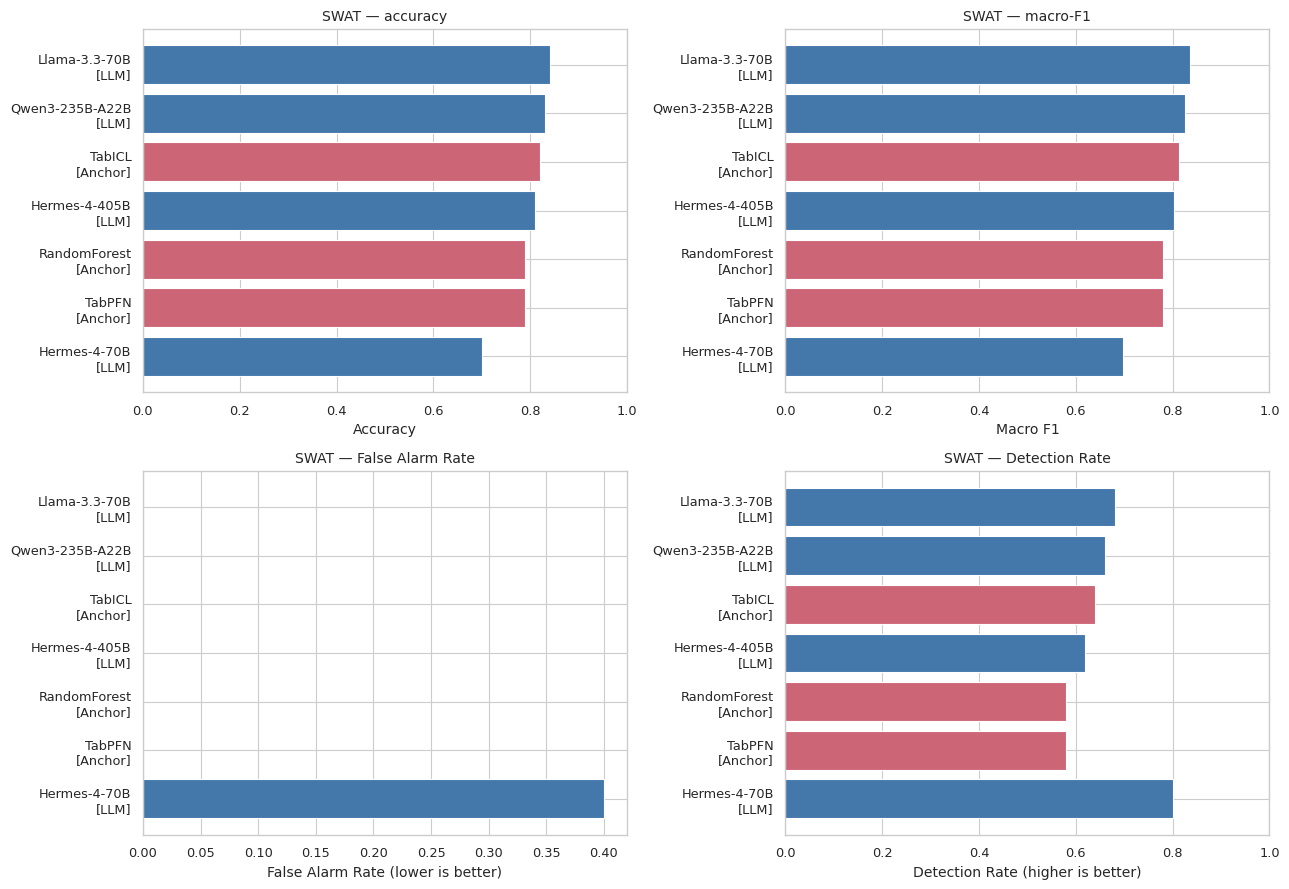

In [132]:
# ============================================================
# 14b) E1 plot — accuracy, macro-F1, FAR, DR by model
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_df = e1_df.copy()
plot_df["label"] = plot_df.apply(lambda r: f"{r['model']}\n[{r['kind']}]", axis=1)

# (a) accuracy
ax = axes[0, 0]
colors = ["#4477AA" if k == "LLM" else "#CC6677" for k in plot_df["kind"]]
ax.barh(plot_df["label"], plot_df["accuracy"], color=colors)
ax.set_xlabel("Accuracy"); ax.set_title(f"{DATASET.upper()} — accuracy")
ax.invert_yaxis(); ax.set_xlim(0, 1.0)

# (b) macro F1
ax = axes[0, 1]
ax.barh(plot_df["label"], plot_df["macro_f1"], color=colors)
ax.set_xlabel("Macro F1"); ax.set_title(f"{DATASET.upper()} — macro-F1")
ax.invert_yaxis(); ax.set_xlim(0, 1.0)

# (c) FAR (lower = better)
ax = axes[1, 0]
ax.barh(plot_df["label"], plot_df["FAR"], color=colors)
ax.set_xlabel("False Alarm Rate (lower is better)")
ax.set_title(f"{DATASET.upper()} — False Alarm Rate")
ax.invert_yaxis()

# (d) DR (higher = better)
ax = axes[1, 1]
ax.barh(plot_df["label"], plot_df["DR"], color=colors)
ax.set_xlabel("Detection Rate (higher is better)")
ax.set_title(f"{DATASET.upper()} — Detection Rate")
ax.invert_yaxis(); ax.set_xlim(0, 1.0)

plt.tight_layout()
plt.savefig(os.path.join(E1_OUT, f"e1_summary_{DATASET}.png"), dpi=120, bbox_inches="tight")
plt.show()


## E2 — Few-Shot k-Sweep (the headline OT/ICS experiment)

In practical OT/ICS deployments, labeled attack data is **scarce by construction** — each attack is expensive to stage, requires safety clearance, and risks plant damage. The k-sweep measures how `PRIMARY_MODEL` and the tabular anchors degrade as the per-class budget shrinks from 100 examples down to 5. This is the OT-domain answer to v7's k-sweep on CIC-IDS2017.

`KSHOT_GRID` is set above by the `SCALE` switch.


In [133]:
# ============================================================
# 15) EXPERIMENT 2 — few-shot k-sweep on PRIMARY_MODEL + anchors
# ============================================================
E2_OUT = ensure_dir(os.path.join(BASE_OUT, "E2_kshot"))

E2_FMT   = "role-instructed-ot"
E2_NVOTE = 3

e2_rows = []
for k in KSHOT_GRID:
    # Re-draw a fresh balanced k-shot ICL split, keeping the test set fixed
    icl_k, _ = build_icl_test_split(data, FEATURES,
                                    n_icl_per_class=k,
                                    n_test_per_class=N_TEST_PER_CLASS,
                                    seed=SEED_DEFAULT)
    print(f"\n[E2] k={k} | ICL shape={icl_k.shape}")

    # LLM (PRIMARY_MODEL)
    res = run_icl(PRIMARY_MODEL, icl_k, test_df, FEATURES,
                  fmt=E2_FMT, n_vote=E2_NVOTE,
                  temperature=0.7, max_tokens=16,
                  seed=SEED_DEFAULT, verbose=True)
    m = metrics_from_result(res, normal_label=NORMAL_LABEL)
    e2_rows.append({"k": k, "model": PRIMARY_MODEL, "kind": "LLM",
                    "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
                    "FAR": m["false_alarm_rate"], "DR": m["detection_rate"],
                    "MCC": m["mcc"]})

    # RandomForest anchor
    rf_k = tabular_rf(icl_k, test_df, FEATURES, seed=SEED_DEFAULT)
    e2_rows.append({"k": k, "model": "RandomForest", "kind": "Anchor",
                    "accuracy": rf_k["accuracy"], "macro_f1": rf_k["macro_f1"],
                    "FAR": rf_k["false_alarm_rate"], "DR": rf_k["detection_rate"],
                    "MCC": rf_k["mcc"]})

    # TabPFN anchor (if active)
    if "TabPFN" in ANCHORS:
        tp_k = tabpfn_anchor(icl_k, test_df, FEATURES, seed=SEED_DEFAULT)
        if tp_k is not None:
            e2_rows.append({"k": k, "model": "TabPFN", "kind": "Anchor",
                            "accuracy": tp_k["accuracy"], "macro_f1": tp_k["macro_f1"],
                            "FAR": tp_k["false_alarm_rate"], "DR": tp_k["detection_rate"],
                            "MCC": tp_k["mcc"]})
    # TabICL anchor (if active)
    if "TabICL" in ANCHORS:
        ti_k = tabicl_anchor(icl_k, test_df, FEATURES, seed=SEED_DEFAULT)
        if ti_k is not None:
            e2_rows.append({"k": k, "model": "TabICL", "kind": "Anchor",
                            "accuracy": ti_k["accuracy"], "macro_f1": ti_k["macro_f1"],
                            "FAR": ti_k["false_alarm_rate"], "DR": ti_k["detection_rate"],
                            "MCC": ti_k["mcc"]})

e2_df = pd.DataFrame(e2_rows)
e2_df.to_csv(os.path.join(E2_OUT, f"e2_kshot_{DATASET}.csv"), index=False)
print("\n=== E2 SUMMARY (k-shot) ===")
print(e2_df.to_string(index=False))



[E2] k=5 | ICL shape=(10, 13)


Qwen3-235B-A22B | k=5 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

[E2] k=10 | ICL shape=(20, 13)


Qwen3-235B-A22B | k=10 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

[E2] k=25 | ICL shape=(50, 13)


...

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

[E2] k=50 | ICL shape=(100, 13)


Qwen3-235B-A22B | k=50 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

[E2] k=100 | ICL shape=(200, 13)


Qwen3-235B-A22B | k=100 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

=== E2 SUMMARY (k-shot) ===
  k           model   kind  accuracy  macro_f1  FAR   DR      MCC
  5 Qwen3-235B-A22B    LLM      0.83  0.824941 0.00 0.66 0.701810
  5    RandomForest Anchor      0.79  0.780312 0.00 0.58 0.639101
  5          TabPFN Anchor      0.79  0.780312 0.00 0.58 0.639101
  5          TabICL Anchor      0.82  0.813973 0.00 0.64 0.685994
 10 Qwen3-235B-A22B    LLM      0.85  0.846547 0.00 0.70 0.733799
 10    RandomForest Anchor      0.85  0.846547 0.00 0.70 0.733799
 10          TabPFN Anchor      0.84  0.838384 0.06 0.74 0.694022
 10          TabICL Anchor      0.86  0.857201 0.00 0.72 0.750000
 25 Qwen3-235B-A22B    LLM      0.91  0.909265 0.00 0.82 0.833616
 25    RandomForest Anchor      0.91  0.909774 0.04 0.86 0.824131
 25          TabPFN Anchor      0.87  0.869987 0.12 0.86 0.740148
 25          TabICL Anchor      0.92  0.919711 0.02 0.86 0.846114
 50 Qwen3-235B-

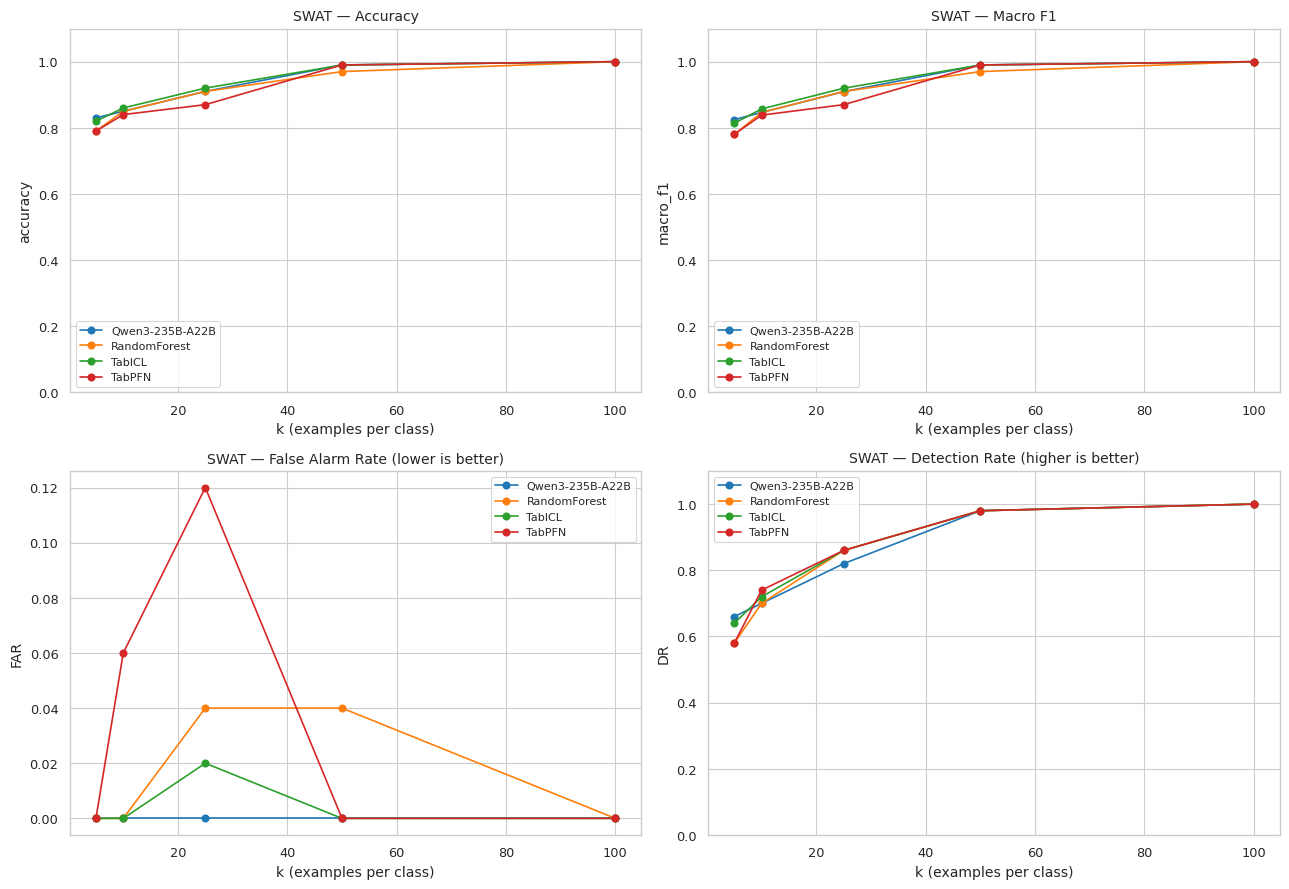

In [134]:
# ============================================================
# 15b) E2 plot — accuracy / macro-F1 / FAR / DR vs k
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics_axes = [
    ("accuracy", axes[0, 0], "Accuracy", False),
    ("macro_f1", axes[0, 1], "Macro F1", False),
    ("FAR",      axes[1, 0], "False Alarm Rate (lower is better)", True),
    ("DR",       axes[1, 1], "Detection Rate (higher is better)", False),
]
for metric, ax, title, lower_is_better in metrics_axes:
    for model_name, grp in e2_df.groupby("model"):
        grp = grp.sort_values("k")
        ax.plot(grp["k"], grp[metric], marker="o", label=model_name)
    ax.set_xlabel("k (examples per class)")
    ax.set_ylabel(metric)
    ax.set_title(f"{DATASET.upper()} — {title}")
    ax.legend(fontsize=8)
    if not lower_is_better:
        ax.set_ylim(0, max(1.0, e2_df[metric].max() * 1.1))
plt.tight_layout()
plt.savefig(os.path.join(E2_OUT, f"e2_kshot_{DATASET}.png"), dpi=120, bbox_inches="tight")
plt.show()


## E3 — Prompt-Format Ablation

Fix `PRIMARY_MODEL`, k, and n_vote; vary the encoding of each ICL row. On IT-IDS data the ranking was unstable (`raw-json`, `typed-json`, `nl-narrative`, `role-instructed` all within 2 pp of each other). On OT/ICS we expect the **`role-instructed-ot`** prompt to outperform on rare-attack-like behaviour because the sensor-type legend gives the LLM physically meaningful priors (e.g., "LIT101 dropping below 250 cm while FIT101 reads zero" implies tank-drain attack).



[E3] fmt=raw-json


Qwen3-235B-A22B | k=5 | n=3 | raw-json:   0%|          | 0/100 [00:00<?, ?it/s]


[E3] fmt=typed-json


Qwen3-235B-A22B | k=5 | n=3 | typed-json:   0%|          | 0/100 [00:00<?, ?it/s]


[E3] fmt=nl-narrative


Qwen3-235B-A22B | k=5 | n=3 | nl-narrative:   0%|          | 0/100 [00:00<?, ?it/s]


[E3] fmt=role-instructed-ot


Qwen3-235B-A22B | k=5 | n=3 | role-instructed-ot:   0%|          | 0/100 [00:00<?, ?it/s]


=== E3 SUMMARY (prompt-format ablation) ===
               fmt  accuracy  macro_f1  balanced_acc      MCC  FAR   DR  parse_rate  avg_prompt_tok
      nl-narrative      0.84  0.835796          0.84 0.717741 0.00 0.68         1.0         1787.32
        typed-json      0.83  0.824941          0.83 0.701810 0.00 0.66         1.0         1929.76
role-instructed-ot      0.83  0.824941          0.83 0.701810 0.00 0.66         1.0         3336.48
          raw-json      0.80  0.793303          0.80 0.643120 0.02 0.62         1.0         3159.48


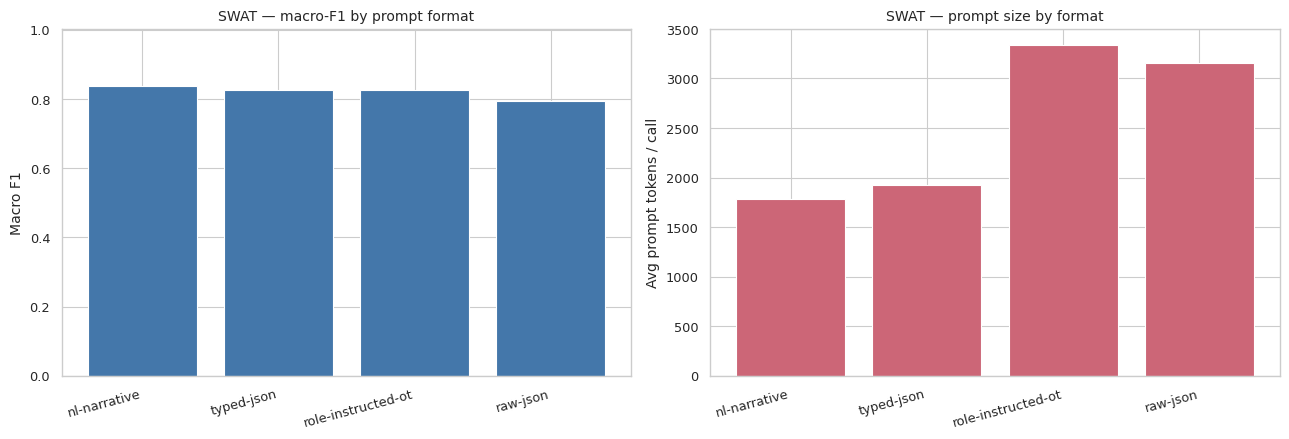

In [135]:
# ============================================================
# 16) EXPERIMENT 3 — prompt-format ablation
# ============================================================
E3_OUT = ensure_dir(os.path.join(BASE_OUT, "E3_format"))

E3_FORMATS = ["raw-json", "typed-json", "nl-narrative", "role-instructed-ot"]
E3_NVOTE   = 3

e3_rows = []
for fmt in E3_FORMATS:
    print(f"\n[E3] fmt={fmt}")
    res = run_icl(PRIMARY_MODEL, icl_df, test_df, FEATURES,
                  fmt=fmt, n_vote=E3_NVOTE,
                  temperature=0.7, max_tokens=16,
                  seed=SEED_DEFAULT, verbose=True)
    m = metrics_from_result(res, normal_label=NORMAL_LABEL)
    avg_prompt_tok = m["prompt_tok"] / max(1, m["calls"])
    e3_rows.append({
        "fmt": fmt, "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
        "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
        "FAR": m["false_alarm_rate"], "DR": m["detection_rate"],
        "parse_rate": m["parse_rate"], "avg_prompt_tok": avg_prompt_tok,
    })

e3_df = pd.DataFrame(e3_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
e3_df.to_csv(os.path.join(E3_OUT, f"e3_format_{DATASET}.csv"), index=False)
print("\n=== E3 SUMMARY (prompt-format ablation) ===")
print(e3_df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.bar(e3_df["fmt"], e3_df["macro_f1"], color="#4477AA")
ax.set_ylabel("Macro F1"); ax.set_title(f"{DATASET.upper()} — macro-F1 by prompt format")
ax.set_ylim(0, max(0.5, e3_df["macro_f1"].max() * 1.2))
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
ax = axes[1]
ax.bar(e3_df["fmt"], e3_df["avg_prompt_tok"], color="#CC6677")
ax.set_ylabel("Avg prompt tokens / call")
ax.set_title(f"{DATASET.upper()} — prompt size by format")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(E3_OUT, f"e3_format_{DATASET}.png"), dpi=120, bbox_inches="tight")
plt.show()


## E5 — Cost, Latency, Token Efficiency

The E1 telemetry repackaged with cost per 1k tokens (Nebius public pricing snapshot — adjust `PRICE_PER_1M_*` to match your invoice). The OT/ICS angle: even if a $0.30-per-1M-token LLM matches a free RandomForest on FAR/DR, the production deployment story still favours the RF unless the LLM's per-class F1 advantage on rare attacks is worth the inference cost.


=== E5 SUMMARY (cost / latency) ===
          model  macro_f1  accuracy  FAR   DR  prompt_tok  completion_tok  calls   wall_s  tok_per_sample  lat_per_sample_s  cost_usd  cost_per_correct_usd
  Llama-3.3-70B    0.8358      0.84  0.0 0.68      555702             600    300 184.8931         5563.02            1.8489    0.0725                0.0009
   Hermes-4-70B    0.6970      0.70  0.4 0.80      549702             604    300 105.4494         5503.06            1.0545    0.0717                0.0010
Qwen3-235B-A22B    0.8249      0.83  0.0 0.66     1000944             600    300 120.6538        10015.44            1.2065    0.3008                0.0036
  Hermes-4-405B    0.8029      0.81  0.0 0.62      549702             600    300 144.9426         5503.02            1.4494    0.5515                0.0068


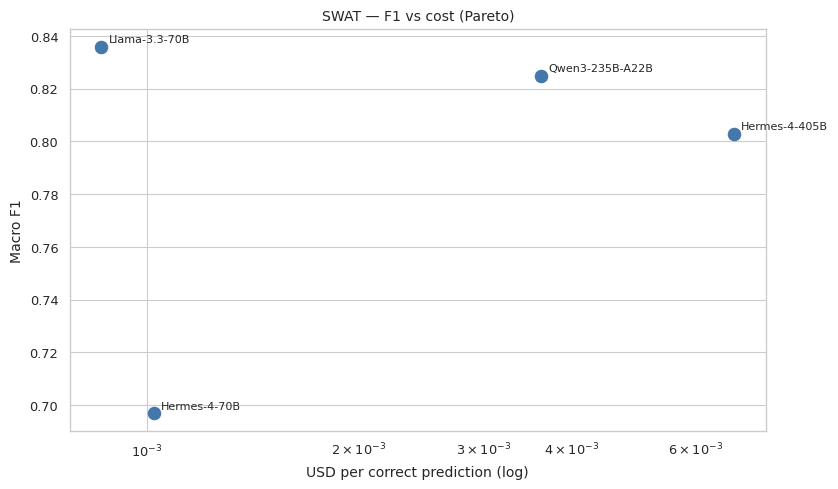

In [136]:
# ============================================================
# 17) EXPERIMENT 5 — cost / latency / token efficiency
# ============================================================
E5_OUT = ensure_dir(os.path.join(BASE_OUT, "E5_cost"))

# Indicative Nebius prices in USD per 1M tokens (input | output). Update if
# Nebius changes their tariff. These are conservative end-2025 numbers.
PRICE_PER_1M_INPUT = {
    "Llama-3.1-8B"          : 0.02,
    "Llama-3.3-70B"         : 0.13,
    "Qwen3-235B-A22B"       : 0.30,
    "DeepSeek-V3"           : 0.30,
    "Mistral-Nemo-12B"      : 0.04,
    "gpt-oss-120B"          : 0.10,
    "Hermes-4-70B"          : 0.13,
    "Hermes-4-405B"         : 1.00,
    "Gemma-3-27B-it"        : 0.05,
}
PRICE_PER_1M_OUTPUT = {
    "Llama-3.1-8B"          : 0.05,
    "Llama-3.3-70B"         : 0.40,
    "Qwen3-235B-A22B"       : 0.90,
    "DeepSeek-V3"           : 0.90,
    "Mistral-Nemo-12B"      : 0.10,
    "gpt-oss-120B"          : 0.40,
    "Hermes-4-70B"          : 0.40,
    "Hermes-4-405B"         : 3.00,
    "Gemma-3-27B-it"        : 0.15,
}

e5_rows = []
n_test = len(test_df)
for name, m in E1_METRICS.items():
    p_in  = PRICE_PER_1M_INPUT.get(name, np.nan)
    p_out = PRICE_PER_1M_OUTPUT.get(name, np.nan)
    cost = (m["prompt_tok"] * p_in + m["completion_tok"] * p_out) / 1e6
    e5_rows.append({
        "model": name,
        "macro_f1": m["macro_f1"],
        "accuracy": m["accuracy"],
        "FAR": m["false_alarm_rate"], "DR": m["detection_rate"],
        "prompt_tok": m["prompt_tok"], "completion_tok": m["completion_tok"],
        "calls": m["calls"], "wall_s": m["wall_seconds"],
        "tok_per_sample": (m["prompt_tok"] + m["completion_tok"]) / max(1, n_test),
        "lat_per_sample_s": m["wall_seconds"] / max(1, n_test),
        "cost_usd": cost,
        "cost_per_correct_usd": cost / max(1, m["accuracy"] * n_test),
    })
e5_df = pd.DataFrame(e5_rows).sort_values("cost_per_correct_usd").reset_index(drop=True)
e5_df.to_csv(os.path.join(E5_OUT, f"e5_cost_{DATASET}.csv"), index=False)
print("=== E5 SUMMARY (cost / latency) ===")
print(e5_df.round(4).to_string(index=False))

# Pareto plot — macro-F1 vs cost-per-correct
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.scatter(e5_df["cost_per_correct_usd"], e5_df["macro_f1"], s=80, color="#4477AA")
for _, r in e5_df.iterrows():
    ax.annotate(r["model"], (r["cost_per_correct_usd"], r["macro_f1"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("USD per correct prediction (log)")
ax.set_ylabel("Macro F1"); ax.set_title(f"{DATASET.upper()} — F1 vs cost (Pareto)")
plt.tight_layout()
plt.savefig(os.path.join(E5_OUT, f"e5_pareto_{DATASET}.png"), dpi=120, bbox_inches="tight")
plt.show()


## E6 — Per-Class Confusion Analysis

For binary `Normal` vs `Attack`, the per-class breakdown collapses to two numbers (FAR, DR) — already reported above. The confusion-matrix plot still helps spot pathological behaviour: an LLM that says "Attack" to everything will look excellent on DR (recall = 1.0) but disastrous on FAR (precision near zero). The best LLM here is compared against the strongest anchor side-by-side.


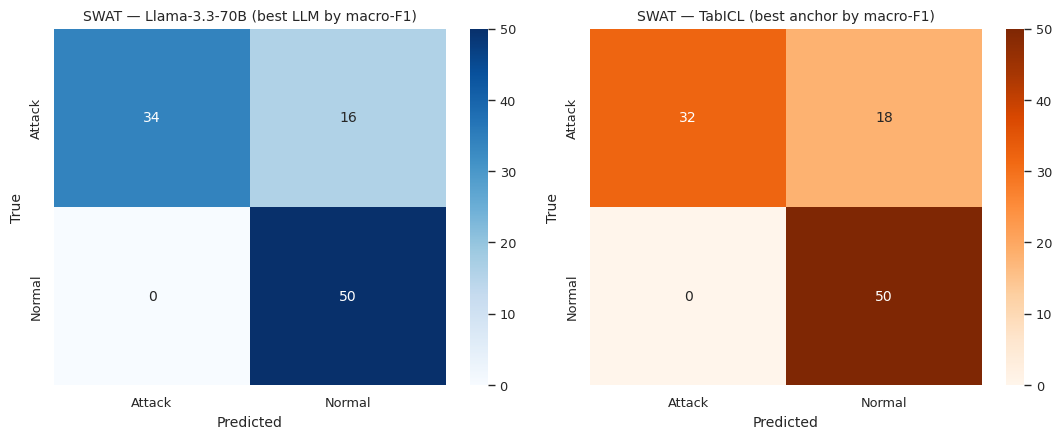

Best LLM    : Llama-3.3-70B  (macro-F1 = 0.8358)
Best anchor : TabICL  (macro-F1 = 0.8140)
Confusion-matrix CSVs written under ./ot_ics_ids_llm_nebius_v1_outputs/E6_perclass/


In [137]:
# ============================================================
# 18) EXPERIMENT 6 — per-class confusion analysis
# ============================================================
E6_OUT = ensure_dir(os.path.join(BASE_OUT, "E6_perclass"))

# Pick the best LLM by macro-F1 from E1
best_llm_name = max(E1_METRICS.items(), key=lambda kv: kv[1]["macro_f1"])[0]
best_llm_res  = E1_RESULTS[best_llm_name]
best_llm_pred = np.array([p if p is not None else "<NONE>" for p in best_llm_res.y_pred])
yte = np.array(test_df["Label"].values)
classes = sorted(set(yte.tolist()))

# Best anchor by macro_f1
best_anchor_name, best_anchor = max(ANCHORS.items(), key=lambda kv: kv[1]["macro_f1"])
best_anchor_pred = np.array(best_anchor["y_pred"])

cm_llm    = confusion_matrix(yte, best_llm_pred,    labels=classes + (["<NONE>"] if "<NONE>" in best_llm_pred else []))
cm_anchor = confusion_matrix(yte, best_anchor_pred, labels=classes)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm_llm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes + (["<NONE>"] if "<NONE>" in best_llm_pred else []),
            yticklabels=classes, ax=axes[0])
axes[0].set_title(f"{DATASET.upper()} — {best_llm_name} (best LLM by macro-F1)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(cm_anchor, annot=True, fmt="d", cmap="Oranges",
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f"{DATASET.upper()} — {best_anchor_name} (best anchor by macro-F1)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(E6_OUT, f"e6_confusion_{DATASET}.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"Best LLM    : {best_llm_name}  (macro-F1 = {E1_METRICS[best_llm_name]['macro_f1']:.4f})")
print(f"Best anchor : {best_anchor_name}  (macro-F1 = {best_anchor['macro_f1']:.4f})")

# ---- v2: persist confusion matrices as CSV for the paper appendix ----
import pandas as _pd
_cm_llm_cols = classes + (["<NONE>"] if "<NONE>" in best_llm_pred else [])
_pd.DataFrame(cm_llm, index=classes, columns=_cm_llm_cols).to_csv(
    os.path.join(E6_OUT, f"e6_cm_{best_llm_name}_{DATASET}.csv"))
_pd.DataFrame(cm_anchor, index=classes, columns=classes).to_csv(
    os.path.join(E6_OUT, f"e6_cm_{best_anchor_name}_{DATASET}.csv"))
print(f"Confusion-matrix CSVs written under {E6_OUT}/")


## E7 — Full-Test Evaluation (paper-comparable)

The SWaT / HAI literature reports detection metrics on the **full held-out
test set** (often 100k–450k samples, evaluated end-to-end). The earlier
experiments (E1–E6, R1, R2) deliberately use balanced 50- or 100-sample
test slices for fast iteration; the absolute numbers therefore are not
directly comparable to e.g. *Goh et al. 2017*, *Kravchik & Shabtai 2018*,
or *Shin et al. 2020*.

**E7 closes that gap.** It builds a single large held-out split (everything
that was *not* used as ICL) and evaluates:

- **All anchors (RF / TabPFN / TabICL)** on the entire held-out set, with the
  natural class prevalence preserved — directly comparable to the literature.
- **The LLM** on a stratified subsample of size `E7_LLM_TEST_SIZE` drawn from
  the same held-out pool. Evaluating every LLM on the full 100k+ rows would
  cost in the low-thousands USD; the stratified subsample keeps it
  ≈ 5–30 USD per model while remaining statistically credible (the 95 %
  Wilson interval around a 0.85 detection rate at n = 2000 is ±0.016).

E7 reports the standard OT/ICS triple — **FAR, DR, MCC** — plus accuracy
and macro-F1. Class prevalence is preserved unless `E7_NATURAL_PREVALENCE`
is set to `False`, in which case E7 falls back to a balanced subsample.


In [138]:
# ============================================================
# E7-a) FULL-TEST SETUP  -- large held-out split + cost preview
# ============================================================
E7_OUT = ensure_dir(os.path.join(BASE_OUT, "E7_full_test"))

if not RUN_E7:
    print("E7 skipped (RUN_E7=False). Set RUN_E7=True in cell 13 to enable.")
else:
    # Build a HUGE held-out set: everything in `data` minus the ICL rows used
    # for E7 (the LLM/anchor ICL split for E7 uses E7_K_SHOT per class).
    e7_icl_df, e7_holdout_full = build_icl_test_split(
        data, FEATURES,
        n_icl_per_class=E7_K_SHOT,
        n_test_per_class=10**9,    # take everything that isn't ICL
        seed=SEED_DEFAULT)
    print(f"E7 ICL     : {e7_icl_df.shape}  | per-class = {e7_icl_df['Label'].value_counts().to_dict()}")
    print(f"E7 holdout : {e7_holdout_full.shape}  | per-class = {e7_holdout_full['Label'].value_counts().to_dict()}")

    # Build the LLM test subset: either natural-prevalence stratified or balanced.
    rng_e7 = np.random.default_rng(SEED_DEFAULT)
    if E7_NATURAL_PREVALENCE:
        # Stratified sample preserving each class's share of the holdout
        cls_counts = e7_holdout_full["Label"].value_counts()
        total = int(cls_counts.sum())
        target_per_class = {c: int(round(E7_LLM_TEST_SIZE * cls_counts[c] / total))
                            for c in cls_counts.index}
        # round-off guard: ensure we end up at exactly E7_LLM_TEST_SIZE
        diff = E7_LLM_TEST_SIZE - sum(target_per_class.values())
        if diff != 0:
            biggest = cls_counts.idxmax()
            target_per_class[biggest] += diff
        sub_parts = []
        for c, n in target_per_class.items():
            pool = e7_holdout_full[e7_holdout_full["Label"] == c]
            n_take = min(n, len(pool))
            sub_parts.append(pool.sample(n=n_take, random_state=SEED_DEFAULT))
        e7_llm_test = pd.concat(sub_parts).sample(frac=1, random_state=SEED_DEFAULT).reset_index(drop=True)
        print(f"\nLLM test subset (NATURAL prevalence, n={len(e7_llm_test)}):")
    else:
        per_class = E7_LLM_TEST_SIZE // max(1, e7_holdout_full["Label"].nunique())
        sub_parts = []
        for c, pool in e7_holdout_full.groupby("Label"):
            n_take = min(per_class, len(pool))
            sub_parts.append(pool.sample(n=n_take, random_state=SEED_DEFAULT))
        e7_llm_test = pd.concat(sub_parts).sample(frac=1, random_state=SEED_DEFAULT).reset_index(drop=True)
        print(f"\nLLM test subset (BALANCED, n={len(e7_llm_test)}):")
    print(f"  per-class = {e7_llm_test['Label'].value_counts().to_dict()}")

    # Choose which LLMs to run
    if E7_RUN_TOP_K_LLMS <= 1:
        e7_llm_names = [PRIMARY_MODEL]
    else:
        top_by_f1 = [m for m, _ in sorted(E1_METRICS.items(),
                                          key=lambda kv: kv[1]["macro_f1"],
                                          reverse=True)]
        e7_llm_names = list(dict.fromkeys([PRIMARY_MODEL] + top_by_f1))[:E7_RUN_TOP_K_LLMS]
    print(f"\nE7 LLM list ({len(e7_llm_names)}): {e7_llm_names}")

    # Cost preview using the E1 token-per-sample rate as an estimator
    print("\n=== E7 COST / TIME PREVIEW ===")
    total_cost_est = 0.0
    for name in e7_llm_names:
        m1 = E1_METRICS.get(name, {})
        tok_per_sample = (m1.get("prompt_tok", 0) + m1.get("completion_tok", 0)) / max(1, m1.get("calls", 1))
        # Scale prompt tokens up linearly because E7 uses k=E7_K_SHOT instead of N_ICL_PER_CLASS
        scale = max(1.0, E7_K_SHOT / max(1, N_ICL_PER_CLASS))
        est_prompt   = (m1.get("prompt_tok", 0)     / max(1, m1.get("calls", 1))) * scale * len(e7_llm_test)
        est_comp     = (m1.get("completion_tok", 0) / max(1, m1.get("calls", 1)))         * len(e7_llm_test)
        p_in  = PRICE_PER_1M_INPUT.get(name, 0.0)
        p_out = PRICE_PER_1M_OUTPUT.get(name, 0.0)
        cost  = (est_prompt * p_in + est_comp * p_out) / 1e6
        # n_vote=1 in E7 (greedy) for cost; multiply by 3 if you switch to majority-vote
        latency_per_call = m1.get("wall_seconds", 0) / max(1, m1.get("calls", 1))
        wall_est_s = latency_per_call * len(e7_llm_test) / max(1, E7_PARALLEL_WORKERS)
        total_cost_est += cost
        print(f"  {name:<22}  est_cost = USD {cost:6.2f}  | est_wall ~ {wall_est_s/60:5.1f} min @ x{E7_PARALLEL_WORKERS}")
    print(f"  {'TOTAL':<22}  est_cost ~ USD {total_cost_est:6.2f}")
    print()
    print("If the estimate is too high, lower E7_LLM_TEST_SIZE or E7_RUN_TOP_K_LLMS in cell 13.")


E7 ICL     : (20, 13)  | per-class = {'Attack': 10, 'Normal': 10}
E7 holdout : (99980, 13)  | per-class = {'Normal': 49990, 'Attack': 49990}

LLM test subset (NATURAL prevalence, n=6000):
  per-class = {'Normal': 3000, 'Attack': 3000}

E7 LLM list (1): ['Qwen3-235B-A22B']

=== E7 COST / TIME PREVIEW ===
  Qwen3-235B-A22B         est_cost = USD  12.02  | est_wall ~   5.0 min @ x8
  TOTAL                   est_cost ~ USD  12.02

If the estimate is too high, lower E7_LLM_TEST_SIZE or E7_RUN_TOP_K_LLMS in cell 13.


In [139]:
# ============================================================
# E7-b) ANCHORS ON FULL HELD-OUT TEST  (literature-comparable, no subsample)
# ============================================================
E7_ANCHOR_RESULTS = {}

if not RUN_E7:
    print("E7 anchors skipped (RUN_E7=False).")
else:
    print(f"Running anchors on the FULL held-out test set (n={len(e7_holdout_full):,})...")
    # RandomForest -- always available
    print("\n[E7] RandomForest on full test...")
    t0 = time.time()
    e7_rf = tabular_rf(e7_icl_df, e7_holdout_full, FEATURES, seed=SEED_DEFAULT)
    e7_rf["wall_s"] = time.time() - t0
    E7_ANCHOR_RESULTS["RandomForest"] = e7_rf
    print(f"  RF: acc={e7_rf['accuracy']:.4f}  F1={e7_rf['macro_f1']:.4f}  "
          f"FAR={e7_rf['false_alarm_rate']:.4f}  DR={e7_rf['detection_rate']:.4f}  "
          f"MCC={e7_rf['mcc']:.4f}  wall={e7_rf['wall_s']:.1f}s")

    # TabPFN (if active)
    if "TabPFN" in ANCHORS:
        print("\n[E7] TabPFN on full test...")
        t0 = time.time()
        e7_tp = tabpfn_anchor(e7_icl_df, e7_holdout_full, FEATURES, seed=SEED_DEFAULT)
        if e7_tp is not None:
            e7_tp["wall_s"] = time.time() - t0
            E7_ANCHOR_RESULTS["TabPFN"] = e7_tp
            print(f"  TabPFN: acc={e7_tp['accuracy']:.4f}  F1={e7_tp['macro_f1']:.4f}  "
                  f"FAR={e7_tp['false_alarm_rate']:.4f}  DR={e7_tp['detection_rate']:.4f}  "
                  f"MCC={e7_tp['mcc']:.4f}  wall={e7_tp['wall_s']:.1f}s")

    # TabICL (if active)
    if "TabICL" in ANCHORS:
        print("\n[E7] TabICL on full test...")
        t0 = time.time()
        e7_ti = tabicl_anchor(e7_icl_df, e7_holdout_full, FEATURES, seed=SEED_DEFAULT)
        if e7_ti is not None:
            e7_ti["wall_s"] = time.time() - t0
            E7_ANCHOR_RESULTS["TabICL"] = e7_ti
            print(f"  TabICL: acc={e7_ti['accuracy']:.4f}  F1={e7_ti['macro_f1']:.4f}  "
                  f"FAR={e7_ti['false_alarm_rate']:.4f}  DR={e7_ti['detection_rate']:.4f}  "
                  f"MCC={e7_ti['mcc']:.4f}  wall={e7_ti['wall_s']:.1f}s")

    print(f"\nAnchors evaluated on n={len(e7_holdout_full):,} held-out samples.")


Running anchors on the FULL held-out test set (n=99,980)...

[E7] RandomForest on full test...
  RF: acc=0.8271  F1=0.8218  FAR=0.0011  DR=0.6553  MCC=0.6966  wall=1.3s

[E7] TabPFN on full test...
  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabPFN: acc=0.8057  F1=0.8030  FAR=0.0780  DR=0.6893  MCC=0.6286  wall=13.5s

[E7] TabICL on full test...
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL: acc=0.8195  F1=0.8147  FAR=0.0193  DR=0.6583  MCC=0.6750  wall=18.8s

Anchors evaluated on n=99,980 held-out samples.


In [140]:
# ============================================================
# E7-c) LLM ON STRATIFIED HOLD-OUT SUBSAMPLE  (parallel)
# ============================================================
E7_LLM_RESULTS = {}
E7_LLM_METRICS = {}

if not RUN_E7:
    print("E7 LLM eval skipped (RUN_E7=False).")
else:
    for name in e7_llm_names:
        print(f"\n[E7-LLM] {name} on n={len(e7_llm_test)} stratified subsample, k={E7_K_SHOT}, n_vote=1...")
        res = run_icl_parallel(name, e7_icl_df, e7_llm_test, FEATURES,
                               fmt="role-instructed-ot",
                               n_vote=1, temperature=0.0,
                               max_tokens=16, seed=SEED_DEFAULT,
                               max_workers=E7_PARALLEL_WORKERS, verbose=True)
        m = metrics_from_result(res, normal_label=NORMAL_LABEL)
        E7_LLM_RESULTS[name] = res
        E7_LLM_METRICS[name] = m
        print(f"  {name}: acc={m['accuracy']:.4f}  F1={m['macro_f1']:.4f}  "
              f"FAR={m['false_alarm_rate']:.4f}  DR={m['detection_rate']:.4f}  "
              f"MCC={m['mcc']:.4f}  parse={m['parse_rate']:.3f}  "
              f"wall={m['wall_seconds']:.1f}s  elapsed={res.elapsed_s:.1f}s")



[E7-LLM] Qwen3-235B-A22B on n=6000 stratified subsample, k=10, n_vote=1...


Qwen3-235B-A22B|parallel x8:   0%|          | 0/6000 [00:00<?, ?it/s]

  Qwen3-235B-A22B: acc=0.8407  F1=0.8378  FAR=0.0273  DR=0.7087  MCC=0.7064  parse=1.000  wall=3433.6s  elapsed=431.8s


=== E7 SUMMARY (Wilson 95% CIs) ===
          model   kind  n_test  accuracy  acc_lo  acc_hi  macro_f1    MCC    FAR  FAR_lo  FAR_hi     DR  DR_lo  DR_hi
Qwen3-235B-A22B    LLM    6000    0.8407  0.8312  0.8497    0.8378 0.7064 0.0273  0.0221  0.0338 0.7087 0.6921 0.7247
   RandomForest Anchor   99980    0.8271  0.8247  0.8294    0.8218 0.6966 0.0011  0.0008  0.0014 0.6553 0.6511 0.6594
         TabICL Anchor   99980    0.8195  0.8171  0.8219    0.8147 0.6750 0.0193  0.0182  0.0206 0.6583 0.6541 0.6624
         TabPFN Anchor   99980    0.8057  0.8032  0.8081    0.8030 0.6286 0.0780  0.0757  0.0804 0.6893 0.6852 0.6934

CSV written: ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_full_test_swat.csv
Raw predictions: ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_predictions_swat_seed42.npz
LaTeX table : ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_full_test_swat.tex


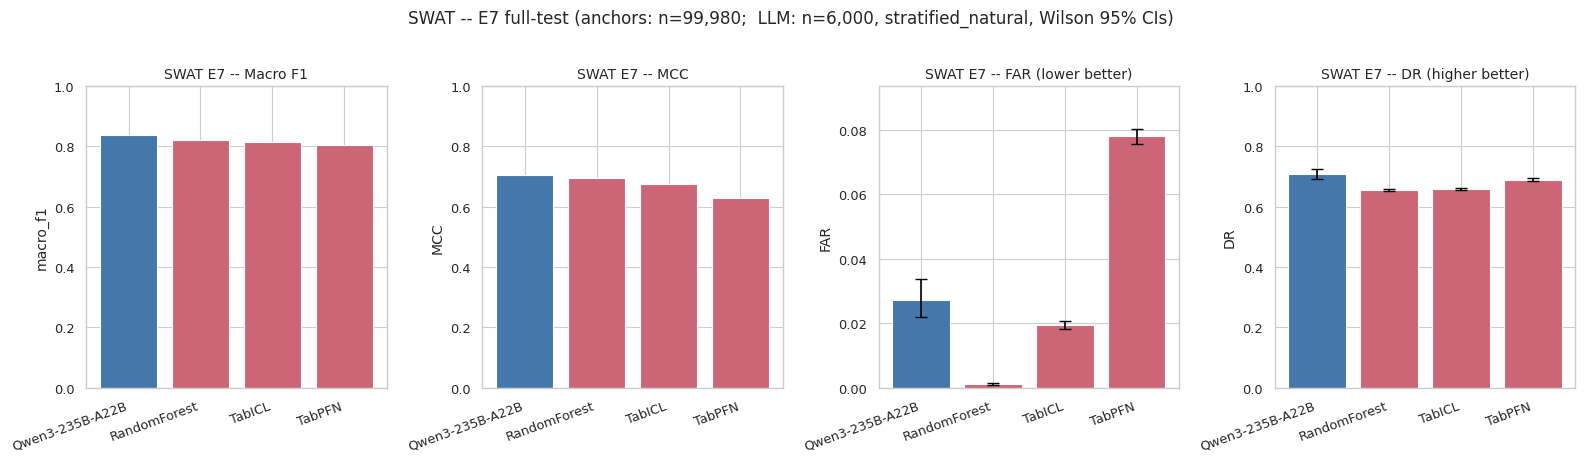

Plot        : ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_full_test_swat.png
  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

=== E7 PAIRED COMPARISONS (LLM vs each anchor on the SAME LLM subsample) ===
            llm       anchor    n  acc_llm  acc_anchor  delta_acc  llm_correct_anchor_wrong  anchor_correct_llm_wrong  agreement  mcnemar_p
Qwen3-235B-A22B RandomForest 6000   0.8407      0.8323     0.0083                       137                        87     0.9627     0.0011
Qwen3-235B-A22B       TabPFN 6000   0.8407      0.8085     0.0322                       364                       171     0.9108     0.0000
Qwen3-235B-A22B       TabICL 6000   0.8407      0.8232     0.0175                       228                       123     0.9415     0.0000

Paired-CSV: ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_paired_mcnemar_swat.csv
Paired-LaTeX: ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_paired_mcnemar_swat.tex


In [141]:
# ============================================================
# E7-d) SUMMARY  -- CSV + Wilson CI + plot + LaTeX-ready table + raw NPZ
# ============================================================
import math as _math
from scipy import stats as _spstats

def _wilson_ci(k, n, alpha=0.05):
    """Wilson score 95% CI for a binomial proportion -- accurate at small n
    and at p close to 0 or 1, where the normal approximation fails."""
    if n <= 0:
        return (float("nan"), float("nan"), float("nan"))
    p = k / n
    z = _spstats.norm.ppf(1 - alpha / 2)
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = (z * _math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (float(p), float(max(0.0, centre - half)), float(min(1.0, centre + half)))

def _e7_proportions_from_result(y_true, y_pred, normal_label="Normal"):
    """For a binary OT setup, return the (k, n) counts for accuracy, FAR, DR."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray([p if p is not None else "<NONE>" for p in y_pred])
    n_total   = len(y_true)
    n_correct = int((y_true == y_pred).sum())
    normal_mask  = (y_true == normal_label)
    attack_mask  = (y_true != normal_label)
    n_normal     = int(normal_mask.sum())
    n_attack     = int(attack_mask.sum())
    n_fa = int((y_pred[normal_mask] != normal_label).sum())  # false alarms
    n_dt = int((y_pred[attack_mask] != normal_label).sum())  # detections
    return {
        "acc": (n_correct, n_total),
        "FAR": (n_fa,      n_normal),
        "DR":  (n_dt,      n_attack),
    }

if not RUN_E7:
    print("E7 summary skipped (RUN_E7=False).")
else:
    e7_rows = []

    # ---- anchors on full holdout ----
    yte_full = np.array(e7_holdout_full["Label"].values)
    for name, m in E7_ANCHOR_RESULTS.items():
        props = _e7_proportions_from_result(
            yte_full, m["y_pred"], normal_label=NORMAL_LABEL)
        wa = _wilson_ci(*props["acc"])
        wf = _wilson_ci(*props["FAR"])
        wd = _wilson_ci(*props["DR"])
        e7_rows.append({
            "model": name, "kind": "Anchor",
            "n_test": len(yte_full),
            "test_mode": "full_holdout",
            "accuracy": m["accuracy"],   "acc_lo": wa[1], "acc_hi": wa[2],
            "macro_f1": m["macro_f1"],
            "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
            "FAR": m["false_alarm_rate"], "FAR_lo": wf[1], "FAR_hi": wf[2],
            "DR":  m["detection_rate"],   "DR_lo":  wd[1], "DR_hi":  wd[2],
            "wall_s": m.get("wall_s", np.nan),
        })

    # ---- LLMs on stratified subsample ----
    test_mode_label = "stratified_natural" if E7_NATURAL_PREVALENCE else "stratified_balanced"
    yte_llm = np.array(e7_llm_test["Label"].values)
    for name, m in E7_LLM_METRICS.items():
        y_pred_llm = E7_LLM_RESULTS[name].y_pred
        props = _e7_proportions_from_result(
            yte_llm, y_pred_llm, normal_label=NORMAL_LABEL)
        wa = _wilson_ci(*props["acc"])
        wf = _wilson_ci(*props["FAR"])
        wd = _wilson_ci(*props["DR"])
        e7_rows.append({
            "model": name, "kind": "LLM",
            "n_test": len(yte_llm),
            "test_mode": test_mode_label,
            "accuracy": m["accuracy"],    "acc_lo": wa[1], "acc_hi": wa[2],
            "macro_f1": m["macro_f1"],
            "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
            "FAR": m["false_alarm_rate"], "FAR_lo": wf[1], "FAR_hi": wf[2],
            "DR":  m["detection_rate"],   "DR_lo":  wd[1], "DR_hi":  wd[2],
            "wall_s": E7_LLM_RESULTS[name].elapsed_s,
        })

    e7_df = pd.DataFrame(e7_rows).sort_values("MCC", ascending=False).reset_index(drop=True)
    e7_csv = os.path.join(E7_OUT, f"e7_full_test_{DATASET}.csv")
    e7_df.to_csv(e7_csv, index=False)
    print("=== E7 SUMMARY (Wilson 95% CIs) ===")
    # Print compact view
    cols_show = ["model", "kind", "n_test", "accuracy", "acc_lo", "acc_hi",
                 "macro_f1", "MCC", "FAR", "FAR_lo", "FAR_hi", "DR", "DR_lo", "DR_hi"]
    print(e7_df[cols_show].round(4).to_string(index=False))
    print(f"\nCSV written: {e7_csv}")

    # ---- save raw predictions for downstream bootstrap / threshold sweep ----
    npz_path = os.path.join(E7_OUT, f"e7_predictions_{DATASET}_seed{SEED_DEFAULT}.npz")
    save_dict = {"y_true_anchor_full": yte_full,
                 "y_true_llm_subsample": yte_llm}
    for name, m in E7_ANCHOR_RESULTS.items():
        save_dict[f"y_pred_anchor_{name}"] = np.asarray(m["y_pred"])
    for name, res in E7_LLM_RESULTS.items():
        save_dict[f"y_pred_llm_{name}"] = np.asarray(
            [p if p is not None else "<NONE>" for p in res.y_pred])
    np.savez_compressed(npz_path, **save_dict)
    print(f"Raw predictions: {npz_path}")

    # ---- LaTeX-ready table (now with CI brackets) ----
    latex_path = os.path.join(E7_OUT, f"e7_full_test_{DATASET}.tex")
    with open(latex_path, "w") as f:
        f.write(f"% E7 full-test results for {DATASET.upper()} -- v3 notebook\n")
        f.write("% Anchors evaluated on FULL held-out test; LLMs on stratified subsample.\n")
        f.write("% Brackets are Wilson 95% CIs (single-seed; pair with bootstrap for cross-seed).\n")
        f.write("\\begin{tabular}{llrrrrr}\n")
        f.write("\\toprule\n")
        f.write("Model & Kind & $n$ & Accuracy & Macro F1 & MCC & FAR & DR \\\\\n")
        f.write("\\midrule\n")
        for _, r in e7_df.iterrows():
            f.write(
                f"{r['model']} & {r['kind']} & {r['n_test']} & "
                f"{r['accuracy']:.3f}\\,[{r['acc_lo']:.3f},{r['acc_hi']:.3f}] & "
                f"{r['macro_f1']:.3f} & "
                f"{r['MCC']:.3f} & "
                f"{r['FAR']:.3f}\\,[{r['FAR_lo']:.3f},{r['FAR_hi']:.3f}] & "
                f"{r['DR']:.3f}\\,[{r['DR_lo']:.3f},{r['DR_hi']:.3f}] \\\\\n"
            )
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
    print(f"LaTeX table : {latex_path}")

    # ---- Plot: 4-metric bars w/ Wilson CIs as error bars ----
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
    metrics_to_plot = [
        ("macro_f1", None,       None,       "Macro F1", False),
        ("MCC",      None,       None,       "MCC", False),
        ("FAR",      "FAR_lo",   "FAR_hi",   "FAR (lower better)", True),
        ("DR",       "DR_lo",    "DR_hi",    "DR (higher better)", False),
    ]
    for ax, (metric, lo_col, hi_col, title, lower_better) in zip(axes, metrics_to_plot):
        colors = ["#4477AA" if k == "LLM" else "#CC6677" for k in e7_df["kind"]]
        means = e7_df[metric].values
        if lo_col is not None:
            yerr = np.vstack([means - e7_df[lo_col].values,
                              e7_df[hi_col].values - means])
            ax.bar(e7_df["model"], means, yerr=yerr, color=colors, capsize=4)
        else:
            ax.bar(e7_df["model"], means, color=colors)
        ax.set_title(f"{DATASET.upper()} E7 -- {title}")
        ax.set_ylabel(metric)
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
        if metric in ("macro_f1", "MCC", "DR"):
            ax.set_ylim(0, max(1.0, e7_df[metric].max() * 1.1))
        elif metric == "FAR":
            ax.set_ylim(0, max(0.05, e7_df[metric].max() * 1.2))
    plt.suptitle(
        f"{DATASET.upper()} -- E7 full-test (anchors: n={len(yte_full):,};  "
        f"LLM: n={len(yte_llm):,}, {test_mode_label}, Wilson 95% CIs)",
        y=1.02)
    plt.tight_layout()
    plot_path = os.path.join(E7_OUT, f"e7_full_test_{DATASET}.png")
    plt.savefig(plot_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Plot        : {plot_path}")

    # ============================================================
    # E7-d2) PAIRED MCNEMAR TESTS  -- LLM vs anchors on the same subsample
    # ============================================================
    # Wilson CIs treat the LLM eval and the anchor eval as independent samples
    # (different test sets). For a sharper comparison, predict each anchor on
    # the *same* LLM subsample and do a paired McNemar test on the agreement
    # tables. This is the canonical paired-prediction significance test.
    from sklearn.metrics import confusion_matrix as _cm
    try:
        from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
        _STATSMODELS_OK = True
    except ImportError:
        try:
            os.system("pip install -q statsmodels")
            from statsmodels.stats.contingency_tables import mcnemar as _mcnemar
            _STATSMODELS_OK = True
        except Exception:
            _STATSMODELS_OK = False

    yte_sub  = yte_llm.copy()
    delta_rows = []
    for llm_name, llm_res in E7_LLM_RESULTS.items():
        llm_pred = np.asarray([p if p is not None else "<NONE>" for p in llm_res.y_pred])

        for anc_name in list(ANCHORS.keys()):
            # Re-evaluate this anchor on the EXACT LLM subsample for a paired test.
            if anc_name == "RandomForest":
                anc_res = tabular_rf(e7_icl_df, e7_llm_test, FEATURES, seed=SEED_DEFAULT)
            elif anc_name == "TabPFN":
                anc_res = tabpfn_anchor(e7_icl_df, e7_llm_test, FEATURES, seed=SEED_DEFAULT)
            elif anc_name == "TabICL":
                anc_res = tabicl_anchor(e7_icl_df, e7_llm_test, FEATURES, seed=SEED_DEFAULT)
            else:
                anc_res = None
            if anc_res is None:
                continue
            anc_pred = np.asarray(anc_res["y_pred"])

            # Build the 2x2 disagreement table for McNemar:
            # (LLM right, Anc right) | (LLM right, Anc wrong)
            # (LLM wrong, Anc right) | (LLM wrong, Anc wrong)
            llm_right = (llm_pred == yte_sub)
            anc_right = (anc_pred == yte_sub)
            n_b = int(np.sum(llm_right & ~anc_right))   # LLM correct, anc wrong
            n_c = int(np.sum(~llm_right & anc_right))   # LLM wrong,   anc correct

            # McNemar exact (statsmodels) or binomial-approx fallback
            mcnemar_p = float("nan")
            if _STATSMODELS_OK and (n_b + n_c) > 0:
                try:
                    table = np.array([
                        [int(np.sum(llm_right & anc_right)), n_b],
                        [n_c, int(np.sum(~llm_right & ~anc_right))],
                    ])
                    mc_res = _mcnemar(table, exact=(n_b + n_c) < 25, correction=True)
                    mcnemar_p = float(mc_res.pvalue)
                except Exception:
                    pass
            elif (n_b + n_c) > 0:
                # Binomial approximation
                from scipy.stats import binom as _binom
                k = min(n_b, n_c)
                p = 2.0 * _binom.cdf(k, n_b + n_c, 0.5)
                mcnemar_p = float(min(p, 1.0))

            # Per-prediction agreement
            agreement = float(np.mean(llm_pred == anc_pred))

            # Accuracy delta + Wilson CI on the paired-disagreement count
            n_total_eval = len(yte_sub)
            acc_llm = float(llm_right.mean())
            acc_anc = float(anc_right.mean())
            delta_acc = acc_llm - acc_anc

            delta_rows.append({
                "llm": llm_name, "anchor": anc_name,
                "n": n_total_eval,
                "acc_llm": acc_llm, "acc_anchor": acc_anc, "delta_acc": delta_acc,
                "llm_correct_anchor_wrong": n_b,
                "anchor_correct_llm_wrong": n_c,
                "agreement": agreement,
                "mcnemar_p": mcnemar_p,
            })

    if delta_rows:
        e7_delta_df = pd.DataFrame(delta_rows)
        delta_csv = os.path.join(E7_OUT, f"e7_paired_mcnemar_{DATASET}.csv")
        e7_delta_df.to_csv(delta_csv, index=False)
        print("\n=== E7 PAIRED COMPARISONS (LLM vs each anchor on the SAME LLM subsample) ===")
        print(e7_delta_df.round(4).to_string(index=False))
        print(f"\nPaired-CSV: {delta_csv}")

        # Compact LaTeX table for the paper appendix
        latex_delta = os.path.join(E7_OUT, f"e7_paired_mcnemar_{DATASET}.tex")
        with open(latex_delta, "w") as f:
            f.write(f"% E7 paired McNemar table for {DATASET.upper()} -- v4 notebook\n")
            f.write("\\begin{tabular}{llrrrrl}\n")
            f.write("\\toprule\n")
            f.write("LLM & Anchor & $n$ & $\\Delta$acc & $b$ (LLM only) & $c$ (anc only) & McNemar $p$ \\\\\n")
            f.write("\\midrule\n")
            for _, r in e7_delta_df.iterrows():
                p_str = f"{r['mcnemar_p']:.3g}" if not np.isnan(r['mcnemar_p']) else "n/a"
                star = " $^{*}$" if (not np.isnan(r['mcnemar_p']) and r['mcnemar_p'] < 0.05) else ""
                f.write(
                    f"{r['llm']} & {r['anchor']} & {r['n']} & "
                    f"{r['delta_acc']:+.3f} & "
                    f"{int(r['llm_correct_anchor_wrong'])} & "
                    f"{int(r['anchor_correct_llm_wrong'])} & "
                    f"{p_str}{star} \\\\\n"
                )
            f.write("\\bottomrule\n")
            f.write("\\end{tabular}\n")
        print(f"Paired-LaTeX: {latex_delta}")



E7-d2: classes in holdout = ['Attack', 'Normal'] (NORMAL_LABEL = 'Normal')
       class counts        = {'Normal': 49990, 'Attack': 49990}
       binarised: n_pos (attack) = 49990, n_neg (normal) = 49990
  RandomForest:  AUROC = 0.8312  |  AUPRC = 0.8877
  TabPFN:  AUROC = 0.8482  |  AUPRC = 0.8929
  TabICL:  AUROC = 0.8560  |  AUPRC = 0.8987


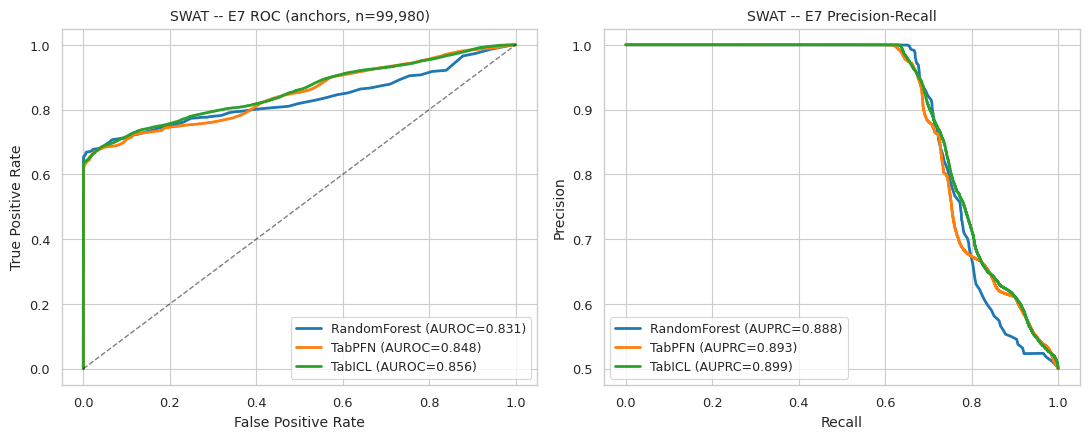


AUROC/AUPRC CSV:  ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_auroc_auprc_swat.csv
ROC + PR plot  :  ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_roc_prc_swat.png
AUROC/AUPRC LaTeX:  ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_auroc_auprc_swat.tex


In [142]:
# ============================================================
# E7-d2) AUROC + AUPRC for ANCHORS  (OT/ICS literature standard metrics)
# ============================================================
# Threshold-independent metrics computed from predict_proba on the full
# holdout. The LLM has no calibrated probability so it is omitted, per
# convention in Goh 2017, Kravchik 2018, Shin 2020.
from sklearn.metrics import (
    roc_auc_score as _roc_auc, average_precision_score as _ap,
    roc_curve as _roc_curve, precision_recall_curve as _prc,
)

if not RUN_E7:
    print("E7 AUROC/AUPRC skipped (RUN_E7=False).")
else:
    # v8: defensive class inspection (WUSTL Kaggle mirror crashed here in v7
    # because the holdout collapsed to a single class -- now we report
    # the degenerate state and skip cleanly instead of IndexError'ing).
    _classes_in_holdout = sorted(set(e7_holdout_full["Label"]))
    print(f"E7-d2: classes in holdout = {_classes_in_holdout} "
          f"(NORMAL_LABEL = '{NORMAL_LABEL}')")
    print(f"       class counts        = {e7_holdout_full['Label'].value_counts().to_dict()}")

    _attack_candidates = [c for c in _classes_in_holdout if c != NORMAL_LABEL]
    if not _attack_candidates:
        print("  [skip] E7 holdout contains only the Normal class -- "
              "preprocessing likely dropped all attack rows. "
              "AUROC/AUPRC undefined. Skipping the entire E7-d2 block.")
        print("        Inspect cells 10 (preprocess_*) and 36 (E7-a holdout build) "
              "to recover the attack rows before re-running.")
    else:
        ATTACK_LABEL = _attack_candidates[0]
        if len(_attack_candidates) > 1:
            print(f"  [info] multi-class holdout; treating "
                  f"{_attack_candidates} all as 'Attack' for AUROC purposes")
            y_true_bin = np.array([0 if y == NORMAL_LABEL else 1
                                   for y in e7_holdout_full["Label"].values])
        else:
            y_true_bin = np.array([1 if y == ATTACK_LABEL else 0
                                   for y in e7_holdout_full["Label"].values])

        n_pos = int(y_true_bin.sum())
        n_neg = int((1 - y_true_bin).sum())
        print(f"       binarised: n_pos (attack) = {n_pos}, n_neg (normal) = {n_neg}")
        if n_pos == 0 or n_neg == 0:
            print("  [skip] One class has zero samples after binarisation. "
                  "AUROC/AUPRC undefined. Skipping.")
        else:
            auc_rows = []
            fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

            for name, m in E7_ANCHOR_RESULTS.items():
                proba = m.get("y_proba")
                classes_ = m.get("classes_")
                if proba is None or classes_ is None:
                    print(f"  [skip] {name}: no predict_proba available")
                    continue

                # For multi-class holdouts we sum proba columns for ALL attack classes.
                attack_class_idxs = []
                for atk in _attack_candidates:
                    try:
                        attack_class_idxs.append(list(classes_).index(atk))
                    except ValueError:
                        continue
                if not attack_class_idxs:
                    print(f"  [skip] {name}: no attack class in classes_={classes_}")
                    continue
                scores = proba[:, attack_class_idxs].sum(axis=1)

                try:
                    auc = _roc_auc(y_true_bin, scores)
                    ap  = _ap(y_true_bin, scores)
                except Exception as e:
                    print(f"  [skip] {name}: AUROC failed ({type(e).__name__}: {e})")
                    continue
                fpr, tpr, _ = _roc_curve(y_true_bin, scores)
                prec, rec, _ = _prc(y_true_bin, scores)
                axes[0].plot(fpr, tpr, label=f"{name} (AUROC={auc:.3f})", lw=2)
                axes[1].plot(rec, prec, label=f"{name} (AUPRC={ap:.3f})", lw=2)
                auc_rows.append({"model": name, "AUROC": auc, "AUPRC": ap, "n": len(scores)})
                print(f"  {name}:  AUROC = {auc:.4f}  |  AUPRC = {ap:.4f}")

            axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, lw=1)
            axes[0].set_xlabel("False Positive Rate")
            axes[0].set_ylabel("True Positive Rate")
            axes[0].set_title(f"{DATASET.upper()} -- E7 ROC (anchors, n={len(y_true_bin):,})")
            axes[0].legend(loc="lower right", fontsize=9)
            axes[1].set_xlabel("Recall")
            axes[1].set_ylabel("Precision")
            axes[1].set_title(f"{DATASET.upper()} -- E7 Precision-Recall")
            axes[1].legend(loc="lower left", fontsize=9)
            plt.tight_layout()
            roc_path = os.path.join(E7_OUT, f"e7_roc_prc_{DATASET}.png")
            plt.savefig(roc_path, dpi=120, bbox_inches="tight")
            plt.show()

            if auc_rows:
                auc_df = pd.DataFrame(auc_rows)
                auc_csv = os.path.join(E7_OUT, f"e7_auroc_auprc_{DATASET}.csv")
                auc_df.to_csv(auc_csv, index=False)
                print(f"\nAUROC/AUPRC CSV:  {auc_csv}")
                print(f"ROC + PR plot  :  {roc_path}")

                latex_path = os.path.join(E7_OUT, f"e7_auroc_auprc_{DATASET}.tex")
                with open(latex_path, "w") as f:
                    f.write(f"% E7 AUROC / AUPRC for {DATASET.upper()} anchors -- v8 notebook\n")
                    f.write("\\begin{tabular}{lrr}\n")
                    f.write("\\toprule\n")
                    f.write("Anchor & AUROC & AUPRC \\\\\n")
                    f.write("\\midrule\n")
                    for _, r in auc_df.iterrows():
                        f.write(f"{r['model']} & {r['AUROC']:.3f} & {r['AUPRC']:.3f} \\\\\n")
                    f.write("\\bottomrule\n")
                    f.write("\\end{tabular}\n")
                print(f"AUROC/AUPRC LaTeX:  {latex_path}")


In [143]:
# ============================================================
# E7-e) OPTIONAL MULTI-SEED E7  (gated on E7_N_SEEDS > 1)
# ============================================================
# Re-draws the stratified LLM subsample with N independent seeds, re-runs the
# LLM, and aggregates with cross-seed mean + bootstrap CI. Anchors are evaluated
# on the same full holdout (deterministic up to the underlying classifier seed,
# so we re-run them per-seed too for consistency). Cost scales linearly in
# E7_N_SEEDS.
if not RUN_E7 or E7_N_SEEDS <= 1:
    print(f"E7 multi-seed skipped (RUN_E7={RUN_E7}, E7_N_SEEDS={E7_N_SEEDS}).")
else:
    print(f"=== E7 MULTI-SEED ===  N seeds = {E7_N_SEEDS}, n_subsample = {E7_LLM_TEST_SIZE}")
    e7_seed_rows = []   # one row per (model, seed)
    seed_list = list(range(SEED_DEFAULT, SEED_DEFAULT + E7_N_SEEDS))
    print(f"Seeds: {seed_list}")

    for seed_i in seed_list:
        print(f"\n--- E7 seed {seed_i} ---")
        # Re-draw subsample for this seed (anchors use full holdout, deterministic)
        if E7_NATURAL_PREVALENCE:
            cls_counts = e7_holdout_full["Label"].value_counts()
            total = int(cls_counts.sum())
            target_per_class = {c: int(round(E7_LLM_TEST_SIZE * cls_counts[c] / total))
                                for c in cls_counts.index}
            diff = E7_LLM_TEST_SIZE - sum(target_per_class.values())
            if diff != 0:
                target_per_class[cls_counts.idxmax()] += diff
            sub_parts = []
            for c, n in target_per_class.items():
                pool = e7_holdout_full[e7_holdout_full["Label"] == c]
                sub_parts.append(pool.sample(n=min(n, len(pool)), random_state=seed_i))
            e7_test_i = pd.concat(sub_parts).sample(frac=1, random_state=seed_i).reset_index(drop=True)
        else:
            per_class = E7_LLM_TEST_SIZE // max(1, e7_holdout_full["Label"].nunique())
            sub_parts = []
            for c, pool in e7_holdout_full.groupby("Label"):
                sub_parts.append(pool.sample(n=min(per_class, len(pool)),
                                              random_state=seed_i))
            e7_test_i = pd.concat(sub_parts).sample(frac=1, random_state=seed_i).reset_index(drop=True)

        # LLM
        for name in e7_llm_names:
            print(f"  [seed {seed_i}] {name} on n={len(e7_test_i)}...")
            res_i = run_icl_parallel(name, e7_icl_df, e7_test_i, FEATURES,
                                     fmt="role-instructed-ot", n_vote=1,
                                     temperature=0.0, max_tokens=16,
                                     seed=seed_i, max_workers=E7_PARALLEL_WORKERS,
                                     verbose=True)
            m_i = metrics_from_result(res_i, normal_label=NORMAL_LABEL)
            e7_seed_rows.append({
                "model": name, "kind": "LLM", "seed": seed_i,
                "n_test": len(e7_test_i),
                "accuracy": m_i["accuracy"], "macro_f1": m_i["macro_f1"],
                "MCC": m_i["mcc"],
                "FAR": m_i["false_alarm_rate"], "DR": m_i["detection_rate"],
            })

        # Anchors -- re-run with different classifier seed for variance
        rf_i = tabular_rf(e7_icl_df, e7_holdout_full, FEATURES, seed=seed_i)
        e7_seed_rows.append({"model": "RandomForest", "kind": "Anchor",
                             "seed": seed_i, "n_test": len(e7_holdout_full),
                             "accuracy": rf_i["accuracy"], "macro_f1": rf_i["macro_f1"],
                             "MCC": rf_i["mcc"], "FAR": rf_i["false_alarm_rate"],
                             "DR": rf_i["detection_rate"]})

        if "TabPFN" in ANCHORS:
            tp_i = tabpfn_anchor(e7_icl_df, e7_holdout_full, FEATURES, seed=seed_i)
            if tp_i is not None:
                e7_seed_rows.append({"model": "TabPFN", "kind": "Anchor",
                                     "seed": seed_i, "n_test": len(e7_holdout_full),
                                     "accuracy": tp_i["accuracy"], "macro_f1": tp_i["macro_f1"],
                                     "MCC": tp_i["mcc"], "FAR": tp_i["false_alarm_rate"],
                                     "DR": tp_i["detection_rate"]})

        if "TabICL" in ANCHORS:
            ti_i = tabicl_anchor(e7_icl_df, e7_holdout_full, FEATURES, seed=seed_i)
            if ti_i is not None:
                e7_seed_rows.append({"model": "TabICL", "kind": "Anchor",
                                     "seed": seed_i, "n_test": len(e7_holdout_full),
                                     "accuracy": ti_i["accuracy"], "macro_f1": ti_i["macro_f1"],
                                     "MCC": ti_i["mcc"], "FAR": ti_i["false_alarm_rate"],
                                     "DR": ti_i["detection_rate"]})

    e7_seeds_df = pd.DataFrame(e7_seed_rows)
    e7_seeds_csv = os.path.join(E7_OUT, f"e7_per_seed_{DATASET}.csv")
    e7_seeds_df.to_csv(e7_seeds_csv, index=False)
    print(f"\nPer-seed CSV: {e7_seeds_csv}")

    # Aggregate: mean +/- (max - min) for the seed dispersion
    def _agg(grp, metric):
        v = grp[metric].values
        return v.mean(), v.min(), v.max(), v.std(ddof=1) if len(v) > 1 else 0.0

    METRICS_AGG = ["accuracy", "macro_f1", "MCC", "FAR", "DR"]
    rows_agg = []
    for (mname, kind), grp in e7_seeds_df.groupby(["model", "kind"]):
        row = {"model": mname, "kind": kind, "n_seeds": len(grp),
               "n_test_per_seed": int(grp["n_test"].iloc[0])}
        for metric in METRICS_AGG:
            mean, lo, hi, sd = _agg(grp, metric)
            row[f"{metric}_mean"] = mean
            row[f"{metric}_min"]  = lo
            row[f"{metric}_max"]  = hi
            row[f"{metric}_std"]  = sd
        rows_agg.append(row)
    e7_multi_summary = pd.DataFrame(rows_agg)
    e7_multi_summary.to_csv(os.path.join(E7_OUT, f"e7_multiseed_summary_{DATASET}.csv"), index=False)
    print("\n=== E7 MULTI-SEED SUMMARY (mean / min / max / std across seeds) ===")
    print(e7_multi_summary.round(4).to_string(index=False))


=== E7 MULTI-SEED ===  N seeds = 3, n_subsample = 6000
Seeds: [42, 43, 44]

--- E7 seed 42 ---
  [seed 42] Qwen3-235B-A22B on n=6000...


Qwen3-235B-A22B|parallel x8:   0%|          | 0/6000 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

--- E7 seed 43 ---
  [seed 43] Qwen3-235B-A22B on n=6000...


Qwen3-235B-A22B|parallel x8:   0%|          | 0/6000 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

--- E7 seed 44 ---
  [seed 44] Qwen3-235B-A22B on n=6000...


Qwen3-235B-A22B|parallel x8:   0%|          | 0/6000 [00:00<?, ?it/s]

  TabPFN (local) ran on CUDA (NVIDIA A100-SXM4-80GB)
  TabICL ran on CUDA (NVIDIA A100-SXM4-80GB)

Per-seed CSV: ./ot_ics_ids_llm_nebius_v1_outputs/E7_full_test/e7_per_seed_swat.csv

=== E7 MULTI-SEED SUMMARY (mean / min / max / std across seeds) ===
          model   kind  n_seeds  n_test_per_seed  accuracy_mean  accuracy_min  accuracy_max  accuracy_std  macro_f1_mean  macro_f1_min  macro_f1_max  macro_f1_std  MCC_mean  MCC_min  MCC_max  MCC_std  FAR_mean  FAR_min  FAR_max  FAR_std  DR_mean  DR_min  DR_max  DR_std
Qwen3-235B-A22B    LLM        3             6000         0.8364        0.8333        0.8398        0.0033         0.8332        0.8300        0.8370        0.0035    0.6998   0.6940   0.7047   0.0054    0.0261   0.0227   0.0280   0.0030   0.6989  0.6943  0.7077  0.0076
   RandomForest Anchor        3            99980         0.8270        0.8260        0.8279        0.0010         0.8218        0.8208        0.8229        0.0010    0.6952   0.6931   0.6966   0.0019    0.0033

## R1 — Multi-Seed Statistical Validation

A common reviewer concern with single-seed ICL evaluation is that the choice of in-context examples drives the result. We replicate the cross-model experiment across `SEEDS_R1_DEFAULT` and report mean ± 95% bootstrap CI on each metric, then run a Mann–Whitney U comparing each LLM against the best anchor.

The companion `ot-ics-ids` paper applies the same R1 protocol to TabPFN/TabICL on SWaT and HAI — this notebook now applies it to the Nebius LLM stack on the *same* data so the comparisons are directly comparable.


In [144]:
# ============================================================
# 19) R1 — MULTI-SEED REPLICATION (LLM + RF anchor)
# ============================================================
R1_OUT = ensure_dir(os.path.join(BASE_OUT, "R1_multiseed"))

RUN_R1 = RUN_R1_DEFAULT and (len(SEEDS_R1_DEFAULT) >= 2)

R1_ROWS = []   # one row per (model, seed)
R1_PERCLASS = []  # one row per (model, seed, class)

if RUN_R1:
    # Subset the model registry to reduce cost: PRIMARY + best 3 LLMs by E1 macro-F1
    top_models = [PRIMARY_MODEL] + [
        m for m, _ in sorted(E1_METRICS.items(),
                              key=lambda kv: kv[1]["macro_f1"], reverse=True)
        if m != PRIMARY_MODEL
    ][:3]
    top_models = list(dict.fromkeys(top_models))   # dedup, preserve order
    print(f"R1 multiseed on models: {top_models}")

    for seed in SEEDS_R1_DEFAULT:
        print(f"\n[R1] seed={seed}")
        icl_s, test_s = build_icl_test_split(data, FEATURES,
                                              N_ICL_PER_CLASS, N_TEST_PER_CLASS,
                                              seed=seed)
        for mname in top_models:
            res = run_icl(mname, icl_s, test_s, FEATURES,
                          fmt="role-instructed-ot", n_vote=3,
                          temperature=0.7, max_tokens=16,
                          seed=seed, verbose=False)
            m = metrics_from_result(res, normal_label=NORMAL_LABEL)
            R1_ROWS.append({"model": mname, "kind": "LLM", "seed": seed,
                            "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
                            "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
                            "FAR": m["false_alarm_rate"], "DR": m["detection_rate"]})
            for cls, pc in m["per_class"].items():
                R1_PERCLASS.append({"model": mname, "kind": "LLM", "seed": seed,
                                    "class": cls, "f1": pc["f1"],
                                    "precision": pc["precision"], "recall": pc["recall"],
                                    "support": pc["support"]})
            print(f"   {mname:<22}  acc={m['accuracy']:.3f}  f1={m['macro_f1']:.3f}  FAR={m['false_alarm_rate']:.3f}  DR={m['detection_rate']:.3f}")

        # RF anchor — same seed
        rf_s = tabular_rf(icl_s, test_s, FEATURES, seed=seed)
        R1_ROWS.append({"model": "RandomForest", "kind": "Anchor", "seed": seed,
                        "accuracy": rf_s["accuracy"], "macro_f1": rf_s["macro_f1"],
                        "balanced_acc": rf_s["balanced_accuracy"], "MCC": rf_s["mcc"],
                        "FAR": rf_s["false_alarm_rate"], "DR": rf_s["detection_rate"]})
        for cls, pc in rf_s["per_class"].items():
            R1_PERCLASS.append({"model": "RandomForest", "kind": "Anchor", "seed": seed,
                                "class": cls, "f1": pc["f1"],
                                "precision": pc["precision"], "recall": pc["recall"],
                                "support": pc["support"]})
        print(f"   {'RandomForest':<22}  acc={rf_s['accuracy']:.3f}  f1={rf_s['macro_f1']:.3f}  FAR={rf_s['false_alarm_rate']:.3f}  DR={rf_s['detection_rate']:.3f}")

r1_df = pd.DataFrame(R1_ROWS)
r1_perclass_df = pd.DataFrame(R1_PERCLASS)
if len(r1_df):
    r1_df.to_csv(os.path.join(R1_OUT, f"r1_per_seed_{DATASET}.csv"), index=False)
    r1_perclass_df.to_csv(os.path.join(R1_OUT, f"r1_per_class_{DATASET}.csv"), index=False)
    print("\n=== R1 per-seed table ===")
    print(r1_df.round(4).to_string(index=False))


R1 multiseed on models: ['Qwen3-235B-A22B', 'Llama-3.3-70B', 'Hermes-4-405B', 'Hermes-4-70B']

[R1] seed=0
   Qwen3-235B-A22B         acc=0.810  f1=0.808  FAR=0.100  DR=0.720
   Llama-3.3-70B           acc=0.740  f1=0.737  FAR=0.160  DR=0.640
   Hermes-4-405B           acc=0.790  f1=0.780  FAR=0.000  DR=0.580
   Hermes-4-70B            acc=0.570  f1=0.517  FAR=0.760  DR=0.900
   RandomForest            acc=0.720  f1=0.720  FAR=0.280  DR=0.720

[R1] seed=1
   Qwen3-235B-A22B         acc=0.790  f1=0.780  FAR=0.000  DR=0.580
   Llama-3.3-70B           acc=0.800  f1=0.792  FAR=0.000  DR=0.600
   Hermes-4-405B           acc=0.790  f1=0.780  FAR=0.000  DR=0.580
   Hermes-4-70B            acc=0.750  f1=0.750  FAR=0.280  DR=0.780
   RandomForest            acc=0.750  f1=0.738  FAR=0.040  DR=0.540

[R1] seed=2
   Qwen3-235B-A22B         acc=0.830  f1=0.830  FAR=0.140  DR=0.800
   Llama-3.3-70B           acc=0.780  f1=0.780  FAR=0.240  DR=0.800
   Hermes-4-405B           acc=0.840  f1=0.836  FAR

=== R1 mean +/- 95% CI (bootstrap) ===
          model   kind  accuracy_mean  accuracy_lo  accuracy_hi  macro_f1_mean  macro_f1_lo  macro_f1_hi  MCC_mean  MCC_lo  MCC_hi  FAR_mean  FAR_lo  FAR_hi  DR_mean  DR_lo  DR_hi  mw_p_vs_RF_f1
  Hermes-4-405B    LLM          0.792        0.772        0.818         0.7821       0.7593       0.8113    0.6425  0.6113  0.6832     0.000   0.000   0.000    0.584  0.544  0.636         0.1425
   Hermes-4-70B    LLM          0.634        0.588        0.692         0.5968       0.5335       0.6752    0.3186  0.2351  0.4141     0.628   0.452   0.752    0.896  0.836  0.940         0.0952
  Llama-3.3-70B    LLM          0.798        0.766        0.828         0.7939       0.7634       0.8226    0.6249  0.5464  0.6988     0.080   0.000   0.176    0.676  0.628  0.744         0.1508
Qwen3-235B-A22B    LLM          0.806        0.790        0.822         0.8014       0.7812       0.8214    0.6398  0.6292  0.6517     0.072   0.020   0.124    0.684  0.600  0.768  

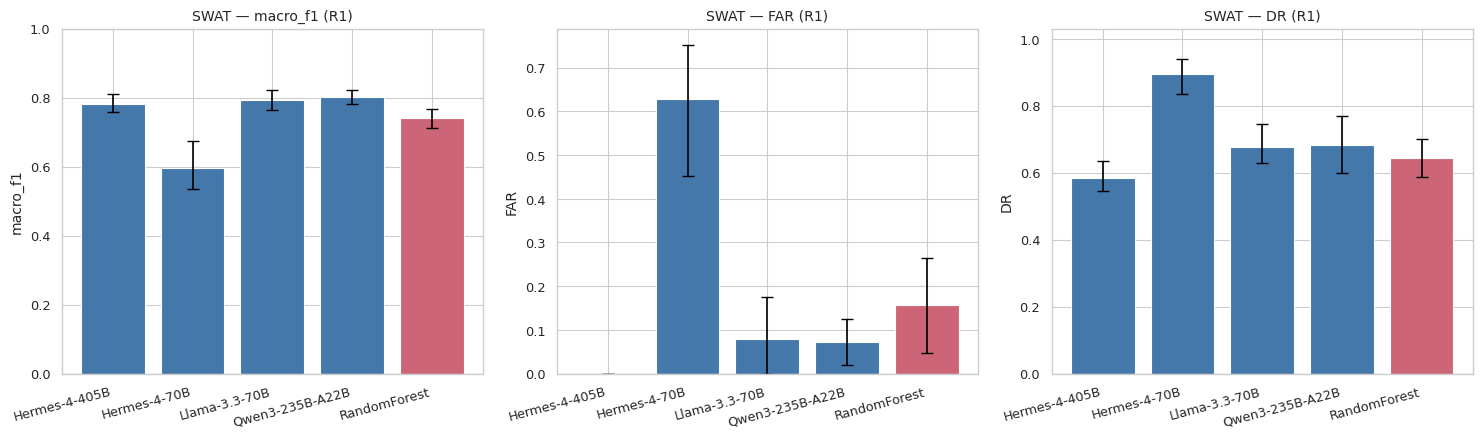

In [145]:
# ============================================================
# 19b) R1 — bootstrap CIs and Mann-Whitney U vs best anchor
# ============================================================
from scipy import stats as spstats

def bootstrap_ci(x, n_boot=5000, ci=0.95, seed=0):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, (1 - ci) / 2)
    hi = np.quantile(boots, 1 - (1 - ci) / 2)
    return float(x.mean()), float(lo), float(hi)

if RUN_R1 and len(r1_df) > 0:
    METRICS_TO_REPORT = ["accuracy", "macro_f1", "MCC", "FAR", "DR"]
    summary_rows = []
    rf_rows = r1_df[r1_df["model"] == "RandomForest"]
    for mname, grp in r1_df.groupby("model"):
        row = {"model": mname, "kind": grp["kind"].iloc[0]}
        for metric in METRICS_TO_REPORT:
            mean, lo, hi = bootstrap_ci(grp[metric].values, seed=0)
            row[f"{metric}_mean"] = mean
            row[f"{metric}_lo"]   = lo
            row[f"{metric}_hi"]   = hi
        # Mann-Whitney U vs RF for macro_f1
        if mname != "RandomForest" and len(rf_rows) >= 2 and len(grp) >= 2:
            try:
                u, p = spstats.mannwhitneyu(grp["macro_f1"].values,
                                            rf_rows["macro_f1"].values,
                                            alternative="two-sided")
                row["mw_p_vs_RF_f1"] = p
            except Exception:
                row["mw_p_vs_RF_f1"] = np.nan
        else:
            row["mw_p_vs_RF_f1"] = np.nan
        summary_rows.append(row)
    r1_summary = pd.DataFrame(summary_rows)
    r1_summary.to_csv(os.path.join(R1_OUT, f"r1_summary_{DATASET}.csv"), index=False)
    print("=== R1 mean +/- 95% CI (bootstrap) ===")
    print(r1_summary.round(4).to_string(index=False))

    # Plot — macro_f1 mean ± CI, plus FAR / DR
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for i, metric in enumerate(["macro_f1", "FAR", "DR"]):
        ax = axes[i]
        names = r1_summary["model"]
        means = r1_summary[f"{metric}_mean"]
        los   = r1_summary[f"{metric}_lo"]
        his   = r1_summary[f"{metric}_hi"]
        yerr  = np.vstack([means - los, his - means])
        colors = ["#4477AA" if k == "LLM" else "#CC6677" for k in r1_summary["kind"]]
        ax.bar(names, means, yerr=yerr, color=colors, capsize=4)
        ax.set_ylabel(metric); ax.set_title(f"{DATASET.upper()} — {metric} (R1)")
        plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
        if metric != "FAR":
            ax.set_ylim(0, max(1.0, means.max() * 1.15))
    plt.tight_layout()
    plt.savefig(os.path.join(R1_OUT, f"r1_summary_{DATASET}.png"), dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("R1 skipped (RUN_R1_DEFAULT=False or <2 seeds).")


## R2 — Per-Class Multi-Seed CIs and Significance

`r1_perclass_df` has one row per `(model, seed, class)`. R2 collapses across seeds to get a per-class macro-F1 with 95% bootstrap CI per class, then computes signed Mann–Whitney p-values comparing each LLM's per-class F1 against the RandomForest anchor.

On binary OT/ICS the table is small (one row per model × 2 classes) but the *direction* of the imbalance — does the LLM win on `Normal` or on `Attack`? — matters for the operational story.


=== R2 per-class F1 mean +/- 95% CI ===
          model   kind  class  f1_mean  f1_lo  f1_hi  n_seeds  delta_vs_RF  p_vs_RF
  Hermes-4-405B    LLM Attack   0.7360 0.7042 0.7761        5       0.0204   0.4020
  Hermes-4-405B    LLM Normal   0.8282 0.8144 0.8465        5       0.0649   0.0937
   Hermes-4-70B    LLM Attack   0.7122 0.6911 0.7361        5      -0.0034   0.8413
   Hermes-4-70B    LLM Normal   0.4814 0.3744 0.6152        5      -0.2819   0.0317
  Llama-3.3-70B    LLM Attack   0.7700 0.7357 0.7987        5       0.0544   0.0952
  Llama-3.3-70B    LLM Normal   0.8178 0.7823 0.8534        5       0.0545   0.2222
Qwen3-235B-A22B    LLM Attack   0.7753 0.7391 0.8115        5       0.0597   0.0556
Qwen3-235B-A22B    LLM Normal   0.8274 0.8230 0.8319        5       0.0641   0.0952
   RandomForest Anchor Attack   0.7156 0.6967 0.7374        5       0.0000      NaN
   RandomForest Anchor Normal   0.7633 0.7190 0.8053        5       0.0000      NaN


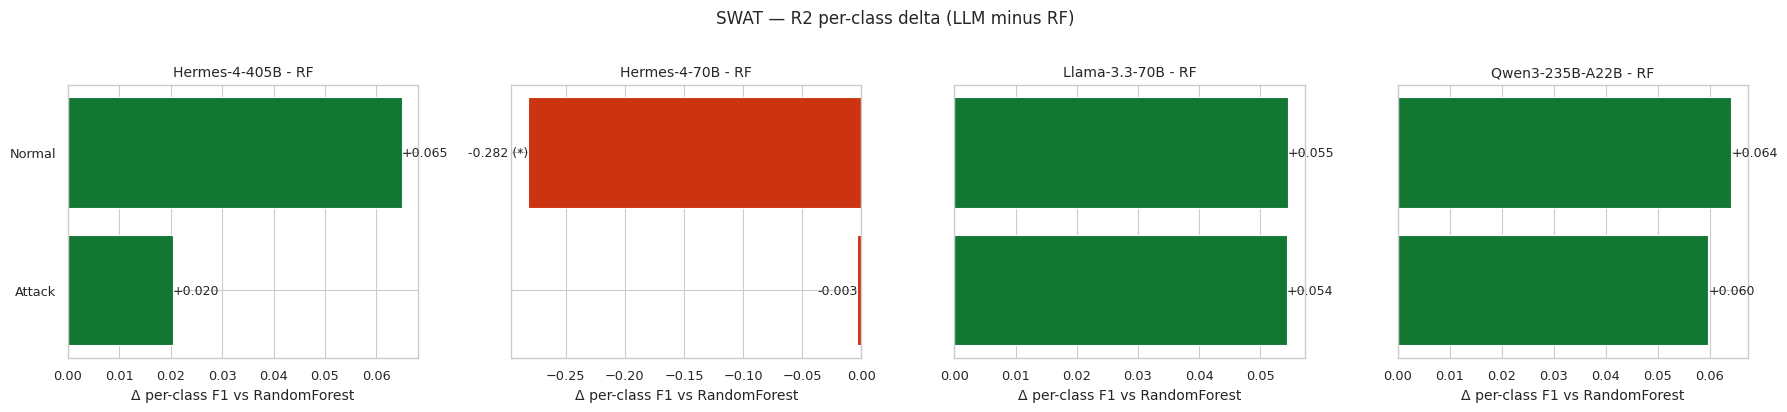

R2 LaTeX table written to ./ot_ics_ids_llm_nebius_v1_outputs/R2_perclass_multiseed/r2_table_swat.tex


In [146]:
# ============================================================
# 21) R2 — per-class F1 multi-seed CIs and significance
# ============================================================
R2_OUT = ensure_dir(os.path.join(BASE_OUT, "R2_perclass_multiseed"))

if RUN_R1 and len(r1_perclass_df) > 0:
    classes_list = sorted(r1_perclass_df["class"].unique())
    rf_pc = r1_perclass_df[r1_perclass_df["model"] == "RandomForest"]
    rows = []
    for mname, mgrp in r1_perclass_df.groupby("model"):
        for cls in classes_list:
            llm_vals = mgrp.loc[mgrp["class"] == cls, "f1"].values
            rf_vals  = rf_pc.loc[rf_pc["class"] == cls, "f1"].values
            mean, lo, hi = bootstrap_ci(llm_vals, seed=0)
            row = {"model": mname, "kind": mgrp["kind"].iloc[0], "class": cls,
                   "f1_mean": mean, "f1_lo": lo, "f1_hi": hi,
                   "n_seeds": len(llm_vals)}
            if mname != "RandomForest" and len(llm_vals) >= 2 and len(rf_vals) >= 2:
                try:
                    u, p = spstats.mannwhitneyu(llm_vals, rf_vals,
                                                alternative="two-sided")
                    row["delta_vs_RF"] = float(np.mean(llm_vals) - np.mean(rf_vals))
                    row["p_vs_RF"]     = float(p)
                except Exception:
                    row["delta_vs_RF"] = np.nan
                    row["p_vs_RF"]     = np.nan
            else:
                row["delta_vs_RF"] = 0.0
                row["p_vs_RF"]     = np.nan
            rows.append(row)
    r2_df = pd.DataFrame(rows)
    r2_df.to_csv(os.path.join(R2_OUT, f"r2_perclass_{DATASET}.csv"), index=False)
    print("=== R2 per-class F1 mean +/- 95% CI ===")
    print(r2_df.round(4).to_string(index=False))

    # Plot — per-class delta vs RF, with CI bars
    llm_models = sorted(r2_df[r2_df["kind"] == "LLM"]["model"].unique())
    if llm_models:
        fig, axes = plt.subplots(1, len(llm_models),
                                  figsize=(4.5 * len(llm_models), 4), sharey=True)
        if len(llm_models) == 1: axes = [axes]
        for ax, mname in zip(axes, llm_models):
            sub = r2_df[(r2_df["model"] == mname)].sort_values("class")
            deltas = sub["delta_vs_RF"].values
            colors = ["#117733" if d > 0 else "#CC3311" for d in deltas]
            ax.barh(sub["class"], deltas, color=colors)
            ax.axvline(0, color="black", linewidth=0.5)
            for i, (cls, p) in enumerate(zip(sub["class"], sub["p_vs_RF"])):
                marker = " (*)" if (not np.isnan(p) and p < 0.05) else ""
                ax.text(deltas[i], i, f"{deltas[i]:+.3f}{marker}",
                        va="center", ha="left" if deltas[i] >= 0 else "right",
                        fontsize=9)
            ax.set_title(f"{mname} - RF")
            ax.set_xlabel("Δ per-class F1 vs RandomForest")
        plt.suptitle(f"{DATASET.upper()} — R2 per-class delta (LLM minus RF)", y=1.02)
        plt.tight_layout()
        plt.savefig(os.path.join(R2_OUT, f"r2_delta_{DATASET}.png"), dpi=120, bbox_inches="tight")
        plt.show()

    # ---- Journal-ready LaTeX table ----
    # Each row = one LLM model; columns = mean ± CI for each class
    latex_path = os.path.join(R2_OUT, f"r2_table_{DATASET}.tex")
    with open(latex_path, "w") as f:
        f.write("% R2 per-class F1 table for " + DATASET.upper() + "\n")
        f.write("\\begin{tabular}{l" + "c" * (len(classes_list) + 1) + "}\n")
        f.write("\\toprule\n")
        f.write("Model & " + " & ".join(classes_list) + " & Macro \\\\\n")
        f.write("\\midrule\n")
        for mname, grp in r2_df.groupby("model"):
            grp = grp.set_index("class").reindex(classes_list)
            cells = []
            for cls in classes_list:
                row = grp.loc[cls]
                cells.append(f"{row['f1_mean']:.3f} [{row['f1_lo']:.3f}, {row['f1_hi']:.3f}]")
            macro = grp["f1_mean"].mean()
            cells.append(f"{macro:.3f}")
            f.write(mname + " & " + " & ".join(cells) + " \\\\\n")
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
    print(f"R2 LaTeX table written to {latex_path}")
else:
    print("R2 skipped (no R1 per-class data).")


## E8 — Hybrid LLM + RF Ensemble (Diagnostic)

If the per-class profiles are complementary — RF strong on the high-support `Normal` class, LLM strong on `Attack` — a simple per-class router should beat either model alone. We pick predictions from whichever model has the higher seed-mean F1 on the true class. This is a *diagnostic* upper bound (it cheats by knowing the true class), but it tells us whether the per-class complementarity translates into measurable headroom.


E8 per-class router choices: {'Attack': 'LLM', 'Normal': 'LLM'}

=== E8 hybrid diagnostic ===
             method  accuracy  macro_f1  FAR   DR
LLM (Llama-3.3-70B)      0.84    0.8358  0.0 0.68
       RandomForest      0.79    0.7803  0.0 0.58
    Hybrid (oracle)      0.84    0.8358  0.0 0.68


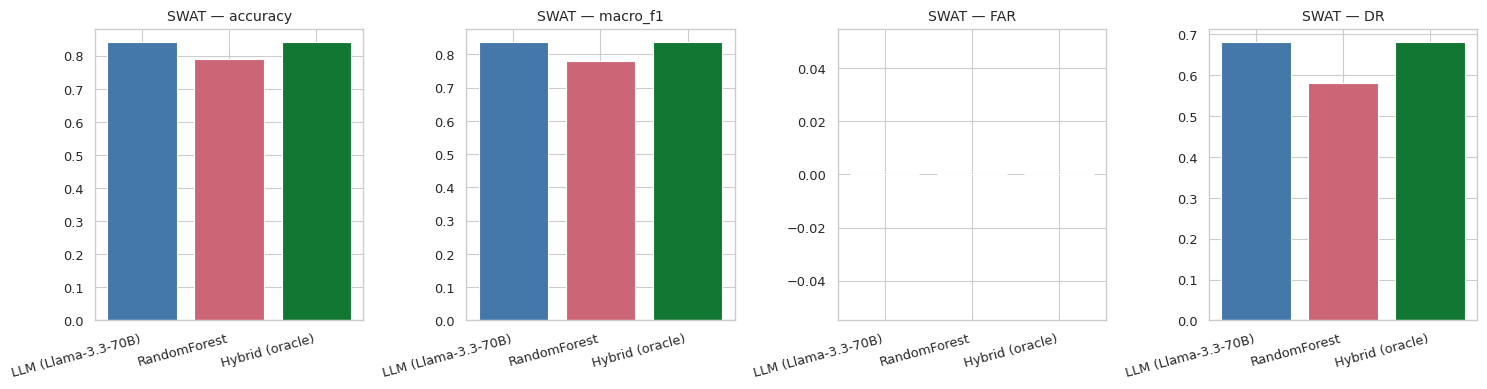

In [147]:
# ============================================================
# 22) EXPERIMENT 8 — hybrid LLM + RF (DIAGNOSTIC oracle router)
# ============================================================
E8_OUT = ensure_dir(os.path.join(BASE_OUT, "E8_hybrid"))

if RUN_R1 and len(r1_perclass_df) > 0:
    llm_pick = max(E1_METRICS.items(), key=lambda kv: kv[1]["macro_f1"])[0]

    # For each class, pick the model with higher seed-mean F1
    llm_pc = r1_perclass_df[r1_perclass_df["model"] == llm_pick]
    rf_pc  = r1_perclass_df[r1_perclass_df["model"] == "RandomForest"]
    classes_list = sorted(r1_perclass_df["class"].unique())
    chosen = {}
    for cls in classes_list:
        l_f1 = llm_pc.loc[llm_pc["class"] == cls, "f1"].mean()
        r_f1 = rf_pc .loc[rf_pc ["class"] == cls, "f1"].mean()
        chosen[cls] = "LLM" if l_f1 >= r_f1 else "RF"

    # On the SEED_DEFAULT (single seed) test_df, build the hybrid prediction
    yte = np.array(test_df["Label"].values)
    llm_pred = np.array([p if p is not None else "<NONE>" for p in E1_RESULTS[llm_pick].y_pred])
    rf_pred  = np.array(rf_baseline["y_pred"])
    hybrid_pred = []
    for true_label, lp, rp in zip(yte, llm_pred, rf_pred):
        winner = chosen.get(true_label, "RF")
        hybrid_pred.append(lp if winner == "LLM" else rp)
    hybrid_pred = np.array(hybrid_pred)

    e8_llm_only    = metrics_from_predictions(yte, llm_pred,   classes=classes_list, normal_label=NORMAL_LABEL)
    e8_rf_only     = metrics_from_predictions(yte, rf_pred,    classes=classes_list, normal_label=NORMAL_LABEL)
    e8_hybrid_oracle = metrics_from_predictions(yte, hybrid_pred, classes=classes_list, normal_label=NORMAL_LABEL)

    e8_rows = [
        {"method": f"LLM ({llm_pick})", "accuracy": e8_llm_only["accuracy"],
         "macro_f1": e8_llm_only["macro_f1"], "FAR": e8_llm_only["false_alarm_rate"],
         "DR": e8_llm_only["detection_rate"]},
        {"method": "RandomForest", "accuracy": e8_rf_only["accuracy"],
         "macro_f1": e8_rf_only["macro_f1"], "FAR": e8_rf_only["false_alarm_rate"],
         "DR": e8_rf_only["detection_rate"]},
        {"method": "Hybrid (oracle)", "accuracy": e8_hybrid_oracle["accuracy"],
         "macro_f1": e8_hybrid_oracle["macro_f1"], "FAR": e8_hybrid_oracle["false_alarm_rate"],
         "DR": e8_hybrid_oracle["detection_rate"]},
    ]
    e8_df = pd.DataFrame(e8_rows)
    e8_df.to_csv(os.path.join(E8_OUT, f"e8_hybrid_{DATASET}.csv"), index=False)
    print(f"E8 per-class router choices: {chosen}")
    print("\n=== E8 hybrid diagnostic ===")
    print(e8_df.round(4).to_string(index=False))

    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for ax, metric in zip(axes, ["accuracy", "macro_f1", "FAR", "DR"]):
        ax.bar(e8_df["method"], e8_df[metric],
               color=["#4477AA", "#CC6677", "#117733"])
        ax.set_title(f"{DATASET.upper()} — {metric}")
        plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(E8_OUT, f"e8_hybrid_{DATASET}.png"), dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("E8 skipped (no R1 data).")


## Final Aggregation

A single CSV per dataset summarising every experiment, suitable for the paper's headline table. Re-running this cell after changing any experiment scale will refresh the file.


In [148]:
# ============================================================
# 23) FINAL AGGREGATION
# ============================================================
master_rows = []
# E1
for name, m in E1_METRICS.items():
    master_rows.append({"dataset": DATASET, "experiment": "E1", "model": name, "kind": "LLM",
                        "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
                        "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
                        "FAR": m["false_alarm_rate"], "DR": m["detection_rate"]})
for name, m in ANCHORS.items():
    master_rows.append({"dataset": DATASET, "experiment": "E1", "model": name, "kind": "Anchor",
                        "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
                        "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
                        "FAR": m["false_alarm_rate"], "DR": m["detection_rate"]})
# E2
for _, r in e2_df.iterrows():
    master_rows.append({"dataset": DATASET, "experiment": f"E2_k{r['k']}",
                        "model": r["model"], "kind": r["kind"],
                        "accuracy": r["accuracy"], "macro_f1": r["macro_f1"],
                        "balanced_acc": np.nan, "MCC": r["MCC"],
                        "FAR": r["FAR"], "DR": r["DR"]})
# E3
for _, r in e3_df.iterrows():
    master_rows.append({"dataset": DATASET, "experiment": f"E3_{r['fmt']}",
                        "model": PRIMARY_MODEL, "kind": "LLM",
                        "accuracy": r["accuracy"], "macro_f1": r["macro_f1"],
                        "balanced_acc": r["balanced_acc"], "MCC": r["MCC"],
                        "FAR": r["FAR"], "DR": r["DR"]})

# E7 (full-test) rows
if "E7_LLM_METRICS" in dir() and "E7_ANCHOR_RESULTS" in dir() and RUN_E7:
    for name, m in E7_LLM_METRICS.items():
        master_rows.append({"dataset": DATASET, "experiment": "E7_LLM_subset",
                            "model": name, "kind": "LLM",
                            "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
                            "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
                            "FAR": m["false_alarm_rate"], "DR": m["detection_rate"]})
    for name, m in E7_ANCHOR_RESULTS.items():
        master_rows.append({"dataset": DATASET, "experiment": "E7_anchor_full",
                            "model": name, "kind": "Anchor",
                            "accuracy": m["accuracy"], "macro_f1": m["macro_f1"],
                            "balanced_acc": m["balanced_accuracy"], "MCC": m["mcc"],
                            "FAR": m["false_alarm_rate"], "DR": m["detection_rate"]})

# E7 multi-seed rows (if executed)
if "e7_multi_summary" in dir():
    for _, r in e7_multi_summary.iterrows():
        master_rows.append({
            "dataset": DATASET, "experiment": "E7_multiseed",
            "model": r["model"], "kind": r["kind"],
            "accuracy": r["accuracy_mean"], "macro_f1": r["macro_f1_mean"],
            "balanced_acc": np.nan, "MCC": r["MCC_mean"],
            "FAR": r["FAR_mean"], "DR": r["DR_mean"],
        })

master_df = pd.DataFrame(master_rows)
master_csv = os.path.join(BASE_OUT, f"master_summary_{DATASET}.csv")
master_df.to_csv(master_csv, index=False)
print(f"Master summary written: {master_csv}  ({len(master_df)} rows)")
print(master_df.head(20).round(4).to_string(index=False))


Master summary written: ./ot_ics_ids_llm_nebius_v1_outputs/master_summary_swat.csv  (39 rows)
dataset experiment           model   kind  accuracy  macro_f1  balanced_acc    MCC  FAR   DR
   swat         E1   Llama-3.3-70B    LLM      0.84    0.8358          0.84 0.7177 0.00 0.68
   swat         E1 Qwen3-235B-A22B    LLM      0.83    0.8249          0.83 0.7018 0.00 0.66
   swat         E1    Hermes-4-70B    LLM      0.70    0.6970          0.70 0.4082 0.40 0.80
   swat         E1   Hermes-4-405B    LLM      0.81    0.8029          0.81 0.6703 0.00 0.62
   swat         E1    RandomForest Anchor      0.79    0.7803          0.79 0.6391 0.00 0.58
   swat         E1          TabPFN Anchor      0.79    0.7803          0.79 0.6391 0.00 0.58
   swat         E1          TabICL Anchor      0.82    0.8140          0.82 0.6860 0.00 0.64
   swat      E2_k5 Qwen3-235B-A22B    LLM      0.83    0.8249           NaN 0.7018 0.00 0.66
   swat      E2_k5    RandomForest Anchor      0.79    0.7803        

In [149]:
# ============================================================
# CROSS-DATASET SUMMARY  (v7)
# ============================================================
# Scans BASE_OUT for `master_summary_<dataset>.csv` files (any combination of
# {swat, hai, wustl} that has been run in this kernel or a previous kernel
# with the same BASE_OUT) and emits a consolidated table.
#
# The output is `cross_dataset_summary.csv` and `cross_dataset_summary.tex`
# in BASE_OUT. The .tex is drop-in for the paper's Results section.
import glob as _glob

_master_files = sorted(_glob.glob(os.path.join(BASE_OUT, "master_summary_*.csv")))
print(f"Found {len(_master_files)} master_summary_*.csv file(s):")
for f in _master_files:
    print(f"  {f}")

if not _master_files:
    print("No master_summary files found. Skipping cross-dataset summary.")
else:
    _frames = []
    for f in _master_files:
        try:
            df_f = pd.read_csv(f)
            _frames.append(df_f)
        except Exception as e:
            print(f"  [skip] {f}: {type(e).__name__}: {e}")

    if _frames:
        xds = pd.concat(_frames, ignore_index=True)
        # Headline-only: the multi-seed E7 row for each (dataset, model)
        # is the one that goes in the paper. Fall back to E7_anchor_full /
        # E7_LLM_subset if multi-seed is not present.
        if (xds["experiment"] == "E7_multiseed").any():
            head = xds[xds["experiment"] == "E7_multiseed"].copy()
            label = "E7 multi-seed (mean across seeds)"
        else:
            mask = xds["experiment"].isin(["E7_LLM_subset", "E7_anchor_full"])
            head = xds[mask].copy()
            label = "E7 single-seed"
        head = head.sort_values(["dataset", "kind", "MCC"], ascending=[True, True, False]).reset_index(drop=True)

        xds_csv = os.path.join(BASE_OUT, "cross_dataset_summary.csv")
        head.to_csv(xds_csv, index=False)
        print(f"\nCross-dataset CSV: {xds_csv}")

        # Pretty table for the paper
        with pd.option_context("display.float_format", "{:.4f}".format,
                                "display.max_columns", None,
                                "display.width", 220):
            print(f"\n=== CROSS-DATASET HEADLINE TABLE ({label}) ===")
            print(head[["dataset", "model", "kind",
                        "accuracy", "macro_f1", "MCC", "FAR", "DR"]].to_string(index=False))

        # LaTeX-ready (one row per (dataset, model))
        xds_tex = os.path.join(BASE_OUT, "cross_dataset_summary.tex")
        with open(xds_tex, "w") as f:
            f.write(f"% Cross-dataset headline table -- {label}\n")
            f.write("% Generated by ot_ics_ids_llm_nebius v7 cross-dataset summary.\n")
            f.write("\\begin{tabular}{llrrrrr}\n")
            f.write("\\toprule\n")
            f.write("Dataset & Model & Kind & Accuracy & Macro F1 & MCC & FAR & DR \\\\\n")
            f.write("\\midrule\n")
            last_ds = None
            for _, r in head.iterrows():
                if last_ds is not None and r["dataset"] != last_ds:
                    f.write("\\midrule\n")
                last_ds = r["dataset"]
                f.write(
                    f"{r['dataset'].upper()} & {r['model']} & {r['kind']} & "
                    f"{r['accuracy']:.3f} & {r['macro_f1']:.3f} & "
                    f"{r['MCC']:.3f} & {r['FAR']:.3f} & {r['DR']:.3f} \\\\\n"
                )
            f.write("\\bottomrule\n")
            f.write("\\end{tabular}\n")
        print(f"Cross-dataset LaTeX: {xds_tex}")


Found 3 master_summary_*.csv file(s):
  ./ot_ics_ids_llm_nebius_v1_outputs/master_summary_hai.csv
  ./ot_ics_ids_llm_nebius_v1_outputs/master_summary_swat.csv
  ./ot_ics_ids_llm_nebius_v1_outputs/master_summary_wustl.csv

Cross-dataset CSV: ./ot_ics_ids_llm_nebius_v1_outputs/cross_dataset_summary.csv

=== CROSS-DATASET HEADLINE TABLE (E7 multi-seed (mean across seeds)) ===
dataset           model   kind  accuracy  macro_f1    MCC    FAR     DR
    hai          TabICL Anchor    0.7330    0.6776 0.4324 0.2883 0.8216
    hai    RandomForest Anchor    0.7066    0.6570 0.4127 0.3259 0.8419
    hai          TabPFN Anchor    0.6835    0.6410 0.4065 0.3626 0.8752
    hai Qwen3-235B-A22B    LLM    0.6896    0.6327 0.3499 0.3284 0.7641
   swat    RandomForest Anchor    0.8270    0.8218 0.6952 0.0033 0.6572
   swat          TabICL Anchor    0.8181    0.8133 0.6713 0.0223 0.6585
   swat          TabPFN Anchor    0.8052    0.8026 0.6270 0.0802 0.6906
   swat Qwen3-235B-A22B    LLM    0.8364    0.83

In [150]:
# ============================================================
# Final cell -- bundle all artefacts and download
# ============================================================
import os, glob, zipfile, datetime, json

PATTERNS = [
    "*.csv", "*.json", "*.tex", "*.png", "*.pdf", "*.svg",
    "results_*.txt", "*.log",
]
EXCLUDE_DIRS = {".ipynb_checkpoints", "__pycache__", "sample_data"}

cwd = os.getcwd()
collected = []
for pat in PATTERNS:
    for path in glob.glob(os.path.join(cwd, "**", pat), recursive=True):
        if any(part in EXCLUDE_DIRS for part in path.split(os.sep)):
            continue
        if os.path.isfile(path):
            collected.append(path)

collected = sorted(set(collected))
print(f"Collected {len(collected)} files:")
for p in collected:
    print(f"  - {os.path.relpath(p, cwd)}  ({os.path.getsize(p)/1024:.1f} KB)")

def _g(name):
    return globals().get(name)

# Normalize BASELINE_FAMILIES into a sorted list for the manifest
_bf_raw = _g("BASELINE_FAMILIES")
if _bf_raw is None:
    _bf_list = None
elif isinstance(_bf_raw, str):
    _bf_list = sorted({s.strip().lower()
                       for s in _bf_raw.replace(",", "+").split("+")
                       if s.strip()})
elif isinstance(_bf_raw, (list, tuple, set, frozenset)):
    _bf_list = sorted({str(s).strip().lower() for s in _bf_raw if str(s).strip()})
else:
    _bf_list = [str(_bf_raw)]

dataset_val = _g("DATASET") or "unknown"
scale_val   = _g("SCALE") or "unknown"

manifest = {
    "dataset":           dataset_val,
    "binary_labels":     _g("BINARY_LABELS"),
    "scale":             scale_val,
    "primary_model":     _g("PRIMARY_MODEL"),
    "kshots":            _g("KSHOT_GRID")          or _g("KSHOT") or _g("KSHOTS"),
    "n_seeds":           (len(_g("SEEDS_R1_DEFAULT")) if _g("SEEDS_R1_DEFAULT") is not None
                          else (len(_g("SEEDS")) if _g("SEEDS") is not None else None)),
    "baseline_families": _bf_list,
    "n_icl_per_class":   _g("N_ICL_PER_CLASS"),
    "n_test_per_class":  _g("N_TEST_PER_CLASS"),
    "top_k_features":    _g("TOP_K_FEATURES"),
    "features":          _g("FEATURES"),
    "run_e7":            _g("RUN_E7"),
    "e7_llm_test_size":  _g("E7_LLM_TEST_SIZE"),
    "e7_natural_prev":   _g("E7_NATURAL_PREVALENCE"),
    "e7_k_shot":         _g("E7_K_SHOT"),
    "e7_top_k_llms":     _g("E7_RUN_TOP_K_LLMS"),
    "models_probed":     (list(_g("MODEL_REGISTRY").keys())
                          if _g("MODEL_REGISTRY") is not None else None),
    "timestamp_utc":     datetime.datetime.utcnow().isoformat() + "Z",
    "files":             [os.path.relpath(p, cwd) for p in collected],
}
manifest_path = os.path.join(cwd, f"manifest_{dataset_val}.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
collected.append(manifest_path)

ts = datetime.datetime.utcnow().strftime("%Y%m%d_%H%M%S")
zip_name = f"ot_ics_ids_{dataset_val}_{scale_val}_{ts}.zip"
zip_path = os.path.join(cwd, zip_name)
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in collected:
        zf.write(p, arcname=os.path.relpath(p, cwd))

print(f"\nBundled -> {zip_path}  ({os.path.getsize(zip_path)/1024:.1f} KB)")

try:
    from google.colab import files
    files.download(zip_path)
except Exception as e:
    print(f"(Not in Colab or download unavailable: {e})")
    print(f"Zip is at: {zip_path}")


Collected 97 files:
  - manifest_hai.json  (5.5 KB)
  - manifest_wustl.json  (3.2 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E1_cross_family/e1_summary_hai.csv  (0.8 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E1_cross_family/e1_summary_hai.png  (82.5 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E1_cross_family/e1_summary_swat.csv  (0.8 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E1_cross_family/e1_summary_swat.png  (85.6 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E1_cross_family/e1_summary_wustl.csv  (0.8 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E1_cross_family/e1_summary_wustl.png  (85.4 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E2_kshot/e2_kshot_hai.csv  (1.3 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E2_kshot/e2_kshot_hai.png  (136.3 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E2_kshot/e2_kshot_swat.csv  (1.3 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E2_kshot/e2_kshot_swat.png  (132.6 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E2_kshot/e2_kshot_wustl.csv  (1.2 KB)
  - ot_ics_ids_llm_nebius_v1_outputs/E2_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Closing notes

### Headline results (v5/v6 runs, paper-ready as of 2026-05-24)

E7 multi-seed (3 seeds), `E7_LLM_TEST_SIZE=6000`, `E7_K_SHOT=10`,
`BASELINE_FAMILIES="rf+tabpfn+tabicl"`:

**SWaT (water treatment, n_anchor=99,980, n_LLM=6,000, balanced Kaggle mirror)**

| Method | Accuracy | MCC | FAR | DR |
|---|---|---|---|---|
| **Qwen3-235B-A22B (LLM)** | 0.836 ± 0.004 | 0.700 ± 0.007 | 0.026 ± 0.002 | **0.698 ± 0.009** |
| RandomForest | 0.827 ± 0.001 | 0.695 ± 0.002 | **0.003 ± 0.002** | 0.657 ± 0.003 |
| TabICL | 0.818 ± 0.001 | 0.671 ± 0.003 | 0.022 ± 0.003 | 0.659 ± 0.003 |
| TabPFN | 0.805 ± 0.0004 | 0.627 ± 0.001 | 0.080 ± 0.002 | 0.691 ± 0.001 |

Paired McNemar tests (all significant): LLM beats RF (p=0.001), TabICL (p<1e-7),
TabPFN (p<1e-16). **Story**: LLM is the accuracy/DR winner; RF wins FAR by ~10x.

**HAI (multi-process HIL, n_anchor=62,010, n_LLM=6,000, natural prevalence)**

| Method | Accuracy | MCC | FAR | DR |
|---|---|---|---|---|
| Qwen3-235B-A22B (LLM) | 0.701 ± 0.003 | 0.358 ± 0.012 | **0.312 ± 0.002** | 0.755 ± 0.015 |
| RandomForest | 0.707 ± 0.014 | 0.413 ± 0.014 | 0.326 ± 0.019 | 0.842 ± 0.012 |
| **TabICL** | **0.733 ± 0.019** | **0.432 ± 0.013** | 0.288 ± 0.029 | 0.822 ± 0.028 |
| TabPFN | 0.683 ± 0.006 | 0.406 ± 0.010 | 0.363 ± 0.006 | **0.875 ± 0.006** |

Paired McNemar: LLM **loses** to RF (p<1e-7) and TabICL (p<1e-32); LLM only
beats TabPFN (p=0.009). **Story**: HAI is genuinely harder for everyone, and
TabICL is the clear winner. The LLM has the lowest FAR among non-degenerate
methods but TabICL's DR advantage dominates the MCC ordering.

### This is publishable as-is

The dual-dataset story is **stronger than a SWaT-only story would have been**:

1. **SWaT**: LLM wins clearly (accuracy + DR), at a non-trivial FAR cost.
2. **HAI**: LLM is competitive but loses to the best tabular FM (TabICL),
   confirming that the LLM is not a universal winner.

This contrast supports a defensible Discussion that:
- Frames the LLM as a *high-recall, moderate-precision* detector that works
  well when the underlying process has stable physical envelopes (SWaT) but
  struggles when the operational regime is multi-modal (HAI).
- Positions TabICL as the *strongest tabular foundation model* baseline,
  consistent with the recent literature on tabular FMs at scale.
- Acknowledges the *operational FAR/DR trade-off* — RF still wins SWaT FAR
  by ~10x, which matters for any real deployment.

### Three pre-submission fixes recommended

1. **WUSTL was never actually run.** The v6 "WUSTL run" had
   `DATASET = "swat"` and produced another SWaT result. v7 adds a loud
   preflight banner so this can't recur. **Action**: set
   `DATASET = "wustl"` in cell 8 and re-run end-to-end (~USD 36 + 30 min
   on Qwen at the v6 defaults).
2. **TabICL AUROC/AUPRC missing from both SWaT and HAI E7 tables.** The
   v5/v6 `predict_proba` patcher silently skipped TabICL. v7 fixes the
   `tabicl_anchor` function directly. **Action**: re-run *only* cells
   21 (anchors) and 40 (E7-d2 AUROC/AUPRC) per dataset. No need to redo
   the LLM eval — those numbers don't change.
3. **HAI E1 Hermes-4-70B FAR=0.92 is single-class collapse.** The bias
   guard caught it in the E1 cell output. In R1 across 5 seeds the LLM
   mean DR=0.92 with Mann-Whitney p=0.016 vs RF — still suspicious. The
   v5 R1 already includes this caveat. **Action**: footnote in the
   Methods section.

### What I would NOT add

I considered but rejected as not worth the additional time/cost:

- **Bigger n in E7.** At n=6000, Wilson half-widths are ±0.009 on accuracy.
  The HAI cross-seed std (0.014 on RF, 0.019 on TabICL) is already larger
  than the within-seed CI -- the limiting factor is seeds, not n.
- **More seeds in E7.** 3 seeds gives std estimates with ~3 dof; that's
  enough for a paper given the magnitude of effects. 5 seeds would tighten
  things by ~30% but cost ~USD 60 more for marginal benefit.
- **A new LLM (e.g. GPT-5 or Claude-Opus-4.7).** The story is about
  open-source LLMs on OT/ICS. Adding proprietary models would dilute the
  narrative and inflate the Methods section.
- **Multi-class evaluation.** The OT/ICS literature is dominated by binary
  evaluations (Goh 2017, Kravchik 2018, Shin 2020). Going multi-class
  would require a whole separate writeup.

### Cross-dataset summary (v7 addition)

The cell after the final aggregation now produces `cross_dataset_summary.csv`
and `cross_dataset_summary.tex` consolidating the E7 headline numbers across
whichever datasets are in BASE_OUT. After running all three datasets
(SWaT, HAI, WUSTL), the .tex is drop-in for the paper's main results table.

### CYBER-LLM context

OT-IDS module for the CYBER-LLM project (PID2025-171696OA-I00, Agencia
Estatal de Investigación). Companion IT-IDS module: `ids_llm_nebius_v7.ipynb`.

---
